# Predictive Maintenance Through Temporal Problem Reformulation

## From Static Pre-Event Classification to Imminent-Event Recurrence-Risk Prediction


### Project Context

Predictive maintenance is used in industrial environments to detect early signs of machine degradation and reduce unexpected downtime.

In this project, we will analyze IoT sensor data collected from machines and build a machine learning solution that can support predictive maintenance decisions.

The project will be developed step by step:

1. Understand the dataset structure
2. Explore sensor behavior over time
3. Analyze fault patterns
4. Define the correct machine learning problem
5. Engineer time-series features
6. Build baseline and advanced models
7. Evaluate the model from both technical and maintenance perspectives
8. Interpret results and document business value

In [1]:
# Core libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

In this section, the predictive maintenance dataset is loaded into a pandas DataFrame.

The initial objective is to verify that the dataset has been loaded correctly before performing any analysis or data preprocessing.

In [2]:
# Load the dataset

df = pd.read_csv("predictive_maintenance_dataset_0.csv")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully.
Dataset shape: (1800, 10)


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.8220,0.6450,66.8500,13.0400,0.1960,0.0330,0.0000,0
1,2024-07-01 08:01:00,M01,1.3980,0.8340,76.2000,15.0800,0.3450,0.1320,0.0010,1
2,2024-07-01 08:02:00,M01,0.8560,0.5900,67.0300,12.3000,0.1870,0.0170,0.0020,0
3,2024-07-01 08:03:00,M01,0.7930,0.5440,65.0400,11.6900,0.1960,-0.0600,0.0030,0
4,2024-07-01 08:04:00,M01,1.2790,0.7210,78.1900,14.8400,0.3300,-0.1150,0.0040,1


### Initial Observation

- The dataset contains **1,800 rows and 10 columns**.
- Each row appears to represent a sensor observation for a particular machine at a specific timestamp.
- The visible sensor variables include:
  - vibration
  - acoustic signal
  - temperature
  - electrical current
  - three IMF (Intrinsic Mode Function) components
- The `machine_id` column identifies the machine associated with each observation.
- The `label` column appears to be a binary variable containing values `0` and `1`.

At this stage, no assumptions are made about:
- the exact meaning of `label = 0` and `label = 1`,
- the number of machines,
- the sampling frequency,
- whether observations are chronologically ordered,
- whether the dataset contains missing values or duplicates.

These aspects will be validated during the initial data audit.

## 2. Initial Data Audit

Before performing exploratory analysis, the dataset structure is examined to understand:

- column names and data types,
- number of non-null values,
- missing values,
- duplicate records,
- unique values in key identifier columns.

This initial audit helps identify data quality issues and determines the preprocessing required before further analysis.

In [3]:
# Inspect the dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1800 non-null   object 
 1   machine_id   1800 non-null   object 
 2   vibration    1800 non-null   float64
 3   acoustic     1800 non-null   float64
 4   temperature  1800 non-null   float64
 5   current      1800 non-null   float64
 6   IMF_1        1800 non-null   float64
 7   IMF_2        1800 non-null   float64
 8   IMF_3        1800 non-null   float64
 9   label        1800 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 140.8+ KB


### Observations from Dataset Structure

- The dataset contains **1,800 observations and 10 columns**.
- All 10 columns contain **1,800 non-null values**, indicating that there are no immediately visible missing values in the dataset.
- The dataset contains:
  - **7 continuous numerical columns** stored as `float64`
  - **1 integer column** (`label`) stored as `int64`
  - **2 object columns** (`timestamp` and `machine_id`)
- The sensor measurements (`vibration`, `acoustic`, `temperature`, `current`, `IMF_1`, `IMF_2`, and `IMF_3`) are already stored in numerical format.
- The `timestamp` column is currently stored as an `object` rather than a datetime data type. It will need to be converted to `datetime` before time-series analysis.
- The `machine_id` column is stored as an `object`, which is appropriate for a machine identifier.
- The dataset is small in memory, using approximately **140.8 KB**, so computational constraints are unlikely to be significant during exploratory analysis.

In [4]:
# Check missing values and duplicate records

print("Missing values by column:")
display(df.isnull().sum().to_frame(name="missing_count"))

print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values by column:


,missing_count
timestamp,0
machine_id,0
vibration,0
acoustic,0
temperature,0
current,0
IMF_1,0
IMF_2,0
IMF_3,0
label,0



Total duplicate rows: 0


### Data Quality Observations

- No missing values are present in any of the 10 columns.
- No completely duplicated rows are present in the dataset.
- Therefore, no missing-value treatment or duplicate-row removal is required at this stage.
- The dataset can proceed to structural validation of its machine and timestamp dimensions.

Although the dataset is complete, further validation is still required to identify possible issues such as duplicate machine-timestamp combinations, irregular sampling intervals, or unexpected gaps in the time series.

### 2.1 Machine Structure

The `machine_id` column is examined to determine:

- the number of machines represented in the dataset,
- the identifiers of those machines,
- the number of observations available for each machine.

This is important because predictive maintenance data often consists of multiple independent machine time series, and differences in observation counts may indicate unequal monitoring periods or missing records.

In [5]:
# Inspect machine structure

print(f"Number of unique machines: {df['machine_id'].nunique()}")

print("\nMachine IDs:")
print(df["machine_id"].unique())

print("\nNumber of observations per machine:")
display(
    df["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="observation_count")
)

Number of unique machines: 3

Machine IDs:
['M01' 'M02' 'M03']

Number of observations per machine:


,observation_count
machine_id,
M01,600
M02,600
M03,600


### Machine Structure Observations

- The dataset contains observations from **3 machines**: `M01`, `M02`, and `M03`.
- Each machine has exactly **600 observations**.
- The dataset is therefore perfectly balanced in terms of the number of records per machine.
- Since all machines have equal observation counts, they may have been monitored over the same duration and at the same sampling frequency.

However, equal record counts alone do not confirm that the machine time series are complete or aligned. The timestamp structure must be examined to determine whether:

- all machines cover the same time period,
- observations are recorded at regular intervals,
- timestamps are unique within each machine,
- any time gaps are present.

### 2.2 Timestamp Structure

Predictive maintenance data is inherently time-dependent. Therefore, the timestamp structure must be validated before performing exploratory analysis or modelling.

The following aspects will be examined:

- conversion of the timestamp column to datetime format,
- overall time range of the dataset,
- time range for each machine,
- number of unique timestamps,
- duplicate machine-timestamp combinations.

Sampling frequency and time-series gaps will be examined separately after this initial validation.

In [6]:
# Convert timestamp to datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"Timestamp data type: {df['timestamp'].dtype}")

print(f"\nOverall start time: {df['timestamp'].min()}")
print(f"Overall end time:   {df['timestamp'].max()}")

print(f"\nNumber of unique timestamps: {df['timestamp'].nunique()}")

print(
    f"\nDuplicate machine-timestamp combinations: "
    f"{df.duplicated(subset=['machine_id', 'timestamp']).sum()}"
)

print("\nTime range by machine:")

display(
    df.groupby("machine_id")
      .agg(
          start_time=("timestamp", "min"),
          end_time=("timestamp", "max"),
          observation_count=("timestamp", "size"),
          unique_timestamps=("timestamp", "nunique")
      )
)

Timestamp data type: datetime64[ns]

Overall start time: 2024-07-01 08:00:00
Overall end time:   2024-07-01 17:59:00

Number of unique timestamps: 600

Duplicate machine-timestamp combinations: 0

Time range by machine:


,start_time,end_time,observation_count,unique_timestamps
machine_id,,,,
M01,2024-07-01 08:00:00,2024-07-01 17:59:00,600,600
M02,2024-07-01 08:00:00,2024-07-01 17:59:00,600,600
M03,2024-07-01 08:00:00,2024-07-01 17:59:00,600,600


### Timestamp Structure Observations

- The `timestamp` column was successfully converted from `object` to `datetime64[ns]`.
- The dataset covers a **10-hour monitoring period**, from **08:00:00 to 17:59:00 on 1 July 2024**.
- There are **600 unique timestamps** in the dataset.
- Each of the three machines:
  - contains exactly **600 observations**,
  - contains **600 unique timestamps**,
  - starts at **08:00:00**,
  - ends at **17:59:00**.
- There are **no duplicate machine-timestamp combinations**.

These findings indicate that the dataset consists of **three parallel machine time series observed over the same monitoring window**.

Since 600 observations span the period from 08:00 to 17:59, the data appears to have been recorded at approximately one-minute intervals. However, the actual sampling interval and the presence of any time gaps must be validated directly rather than inferred from the observation counts.

### 2.3 Sampling Frequency and Time-Series Continuity

Regular sampling is important for time-series feature engineering. Lag features, rolling windows, rates of change, and prediction horizons are meaningful only when the time interval between consecutive observations is understood.

The time difference between consecutive observations will therefore be calculated separately for each machine to determine:

- the observed sampling intervals,
- whether all machines follow the same frequency,
- whether any unexpected time gaps are present.

In [7]:
# Sort observations chronologically within each machine

df = (
    df.sort_values(["machine_id", "timestamp"])
      .reset_index(drop=True)
)

# Calculate time difference between consecutive observations for each machine

df["time_diff"] = (
    df.groupby("machine_id")["timestamp"]
      .diff()
)

print("Observed time intervals:")
display(
    df["time_diff"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame(name="count")
)

print("\nTime interval summary by machine:")
display(
    df.groupby("machine_id")["time_diff"]
      .agg(["min", "max"])
)

Observed time intervals:


,count
time_diff,
0 days 00:01:00,1797
NaT,3



Time interval summary by machine:


,min,max
machine_id,,
M01,0 days 00:01:00,0 days 00:01:00
M02,0 days 00:01:00,0 days 00:01:00
M03,0 days 00:01:00,0 days 00:01:00


### Sampling Frequency and Continuity Observations

- Consecutive observations are separated by exactly **1 minute**.
- A total of **1,797 one-minute intervals** are observed:
  - 599 intervals for `M01`
  - 599 intervals for `M02`
  - 599 intervals for `M03`
- The 3 `NaT` values correspond to the first observation of each machine, where no previous timestamp exists for calculating a time difference.
- For every machine, both the minimum and maximum observed time intervals are exactly **1 minute**.
- Therefore, all three machine time series are:
  - regularly sampled,
  - temporally continuous,
  - free from missing timestamps within the monitoring period.

This confirms a **1-minute sampling frequency** and allows future time-based operations such as lag features, rolling windows, and prediction horizons to be interpreted directly in minutes.

In [8]:
# Remove temporary audit column

df.drop(columns="time_diff", inplace=True)

print(f"Current dataset shape: {df.shape}")

Current dataset shape: (1800, 10)


### 2.4 Label Structure

The `label` column is a potential target variable, but its structure must be understood before defining the machine learning problem.

The analysis will first examine:

- the unique label values,
- the overall number and percentage of observations in each class,
- the class distribution for each machine.

At this stage, the analysis focuses only on the statistical structure of the label. Its temporal behavior and exact predictive-maintenance interpretation will be investigated separately.

In [9]:
# Inspect overall label structure

print("Unique label values:")
print(np.sort(df["label"].unique()))

label_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

label_distribution["percentage"] = (
    label_distribution["count"] / len(df) * 100
)

print("\nOverall label distribution:")
display(label_distribution)

print("\nLabel distribution by machine:")
display(
    pd.crosstab(
        index=df["machine_id"],
        columns=df["label"],
        margins=True
    )
)

Unique label values:
[0 1]

Overall label distribution:


,count,percentage
label,,
0,1598,88.7778
1,202,11.2222



Label distribution by machine:


label,0,1,All
machine_id,,,
M01,531,69,600
M02,542,58,600
M03,525,75,600
All,1598,202,1800


### Label Distribution Observations

- The `label` column is binary and contains only the values `0` and `1`.
- Out of 1,800 observations:
  - **1,598 observations (88.78%)** have label `0`.
  - **202 observations (11.22%)** have label `1`.
- The label distribution is therefore moderately imbalanced, with label `1` occurring much less frequently than label `0`.
- Label `1` is present in all three machines:
  - `M01`: 69 observations
  - `M02`: 58 observations
  - `M03`: 75 observations
- The number of label `1` observations varies across machines, but no machine is completely missing either class.

This class imbalance will later influence model evaluation. Accuracy alone may be misleading, and metrics such as precision, recall, F1-score, and Precision-Recall AUC may be more informative.

However, the overall class distribution does not reveal how label `1` behaves over time. The next step is to determine whether label `1` occurs as isolated observations, consecutive episodes, or recurring temporal patterns.

### 2.5 Temporal Behavior of the Label

The overall frequency of a label is not sufficient to understand its meaning in a predictive maintenance context.

The temporal sequence of `label = 1` will therefore be examined to determine whether positive observations:

- occur as isolated points,
- form consecutive episodes,
- recur at particular intervals,
- exhibit different patterns across machines.

Understanding this temporal structure is essential before defining fault events, prediction horizons, or model targets.

In [10]:
# Examine temporal spacing between label = 1 observations

positive_observations = (
    df.loc[df["label"] == 1, ["machine_id", "timestamp"]]
      .copy()
)

positive_observations["minutes_since_previous_positive"] = (
    positive_observations
    .groupby("machine_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

print("Spacing between consecutive label = 1 observations:")
display(
    positive_observations["minutes_since_previous_positive"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame(name="count")
)

print("\nSummary by machine:")
display(
    positive_observations
    .groupby("machine_id")["minutes_since_previous_positive"]
    .agg(["count", "min", "median", "mean", "max"])
)

Spacing between consecutive label = 1 observations:


,count
minutes_since_previous_positive,
1.0000,18
2.0000,22
3.0000,16
4.0000,18
5.0000,12
6.0000,13
7.0000,14
8.0000,13
9.0000,11



Summary by machine:


,count,min,median,mean,max
machine_id,,,,,
M01,68,1.0000,6.5000,8.7206,32.0000
M02,57,1.0000,7.0000,9.3333,36.0000
M03,74,1.0000,5.5000,8.0135,33.0000


### Temporal Label Observations

- The spacing between consecutive `label = 1` observations varies substantially, from **1 minute to 36 minutes**.
- Only **18 transitions** occur with a 1-minute gap, meaning that only a limited number of positive observations are immediately consecutive.
- Positive labels frequently recur after gaps of several minutes rather than forming long uninterrupted blocks.
- The median time between positive observations is:
  - **6.5 minutes** for `M01`
  - **7.0 minutes** for `M02`
  - **5.5 minutes** for `M03`
- The mean spacing is approximately **8–9 minutes** across all three machines.
- All machines show broadly similar temporal behavior, although `M03` has somewhat more frequent positive observations.

These findings suggest that positive labels are distributed throughout the monitoring period and are often separated by negative observations. Therefore, treating every positive observation as an independent fault event may overstate the number of distinct maintenance events.

A more explicit event-level analysis is required to determine:

- how many isolated positive observations exist,
- how many consecutive positive runs occur,
- the duration of those runs,
- whether positive labels are clustered within broader periods of abnormal machine behavior.


### 2.6 Consecutive Positive-Label Runs

To distinguish isolated positive observations from sustained positive periods, consecutive runs of `label = 1` are identified separately for each machine.

A positive run is defined as one or more consecutive one-minute observations with `label = 1`.

The analysis will determine:

- the number of positive runs,
- the duration of each run,
- the number of isolated one-minute positives,
- the longest consecutive positive period for each machine.

This event-level view provides a more accurate description of the label structure than counting positive rows alone.

In [11]:
# Identify consecutive runs of label = 1

df["label_change"] = (
    df.groupby("machine_id")["label"]
      .diff()
      .ne(0)
)

df["run_id"] = (
    df.groupby("machine_id")["label_change"]
      .cumsum()
)

positive_runs = (
    df[df["label"] == 1]
    .groupby(["machine_id", "run_id"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        duration_minutes=("label", "size")
    )
    .reset_index()
)

print(f"Total number of positive runs: {len(positive_runs)}")

print("\nPositive-run duration distribution:")
display(
    positive_runs["duration_minutes"]
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_runs")
)

print("\nPositive-run summary by machine:")
display(
    positive_runs
    .groupby("machine_id")["duration_minutes"]
    .agg(
        number_of_runs="count",
        median_duration="median",
        mean_duration="mean",
        max_duration="max"
    )
)

Total number of positive runs: 184

Positive-run duration distribution:


,number_of_runs
duration_minutes,
1,166
2,18



Positive-run summary by machine:


,number_of_runs,median_duration,mean_duration,max_duration
machine_id,,,,
M01,62,1.0000,1.1129,2
M02,57,1.0000,1.0175,2
M03,65,1.0000,1.1538,2


### Consecutive Positive-Run Observations

- The 202 positive observations form **184 separate positive runs**.
- Of these 184 runs:
  - **166 runs (90.2%)** consist of a single one-minute positive observation.
  - **18 runs (9.8%)** last for two consecutive minutes.
- No positive run lasts longer than **2 minutes**.
- The median positive-run duration is **1 minute** for all three machines.
- The number of positive runs is:
  - `M01`: 62 runs
  - `M02`: 57 runs
  - `M03`: 65 runs

These findings show that `label = 1` behaves predominantly as a **point-level event or abnormal-state indicator**, rather than as a sustained machine-failure episode.

Therefore, the 202 positive rows should not automatically be interpreted as 202 independent physical machine failures. Similarly, the 184 positive runs should not yet be treated as 184 confirmed maintenance events without further understanding of how the dataset labels were generated.

This distinction is important for project formulation:

- predicting the current `label` would primarily represent **fault or anomaly detection**,
- predictive maintenance would require demonstrating whether sensor history contains information about a **future positive event** before that event occurs.

The next analysis will therefore investigate the relationship between sensor measurements and the label before defining the final prediction target.

In [12]:
# Remove temporary run-analysis columns

df.drop(columns=["label_change", "run_id"], inplace=True)

print(f"Current dataset shape: {df.shape}")

Current dataset shape: (1800, 10)


## 3. Sensor Data Understanding

The structural audit established that the dataset contains three complete, regularly sampled machine time series and a binary label that occurs primarily as isolated one-minute events.

The next phase examines the sensor variables themselves.

The analysis will investigate:

- numerical ranges and distributions,
- differences across machines,
- differences between label classes,
- temporal behavior of sensor signals,
- relationships among sensor variables.

The objective is not only to describe the data, but also to determine whether the observed label reflects identifiable machine-condition changes and whether meaningful pre-event patterns may exist.

### 3.1 Descriptive Statistics of Sensor Variables

Descriptive statistics are examined to understand the scale, central tendency, variability, and range of each sensor measurement.

This initial summary may also reveal:

- sensors operating on substantially different numerical scales,
- extreme or unusual values,
- variables with limited variability,
- potential differences in the behavior of the IMF components.

In [13]:
# Descriptive statistics of numerical sensor variables

sensor_cols = [
    "vibration",
    "acoustic",
    "temperature",
    "current",
    "IMF_1",
    "IMF_2",
    "IMF_3"
]

display(
    df[sensor_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
vibration,1800.0000,0.8433,0.1367,0.6450,0.7690,0.8050,0.8510,1.4050
acoustic,1800.0000,0.6339,0.1080,0.4300,0.5720,0.6090,0.6512,1.0830
temperature,1800.0000,66.3557,4.4481,58.3600,63.7300,65.3550,66.9900,85.1600
current,1800.0000,12.3286,1.0945,10.2900,11.7000,12.0800,12.4800,16.9400
IMF_1,1800.0000,0.1687,0.0565,0.0730,0.1230,0.1660,0.2070,0.3930
IMF_2,1800.0000,0.0001,0.0731,-0.1800,-0.0580,-0.0010,0.0590,0.1870
IMF_3,1800.0000,0.0007,0.0360,-0.0500,-0.0370,0.0035,0.0370,0.0500


### Descriptive Statistics Observations

- All seven sensor variables contain 1,800 observations, confirming the absence of missing numerical values.
- The sensor variables operate on substantially different numerical scales:
  - `temperature` ranges from **58.36 to 85.16**.
  - `current` ranges from **10.29 to 16.94**.
  - `vibration` and `acoustic` are measured on smaller positive scales.
  - The IMF components are centered on much smaller numerical ranges.
- `vibration`, `acoustic`, `temperature`, and `current` have maximum values noticeably above their respective 75th percentiles. This suggests the presence of a higher-value region in their distributions that requires further investigation.
- `IMF_1` is strictly positive, ranging from **0.073 to 0.393**.
- `IMF_2` and `IMF_3` contain both positive and negative values and are centered close to zero.
- `IMF_3` has a particularly constrained range of approximately **-0.05 to 0.05**.

The descriptive statistics suggest that some sensor variables may contain distinct operating regimes rather than simple symmetric distributions. However, summary statistics alone cannot determine whether these higher-value observations are associated with the positive label, machine-specific behavior, or natural sensor variation.

The next step is to compare sensor measurements directly across the two label classes.

### 3.2 Sensor Measurements by Label

To investigate whether the binary label is associated with changes in machine condition, the sensor variables are compared between `label = 0` and `label = 1`.

For each sensor and label class, the following statistics are examined:

- number of observations,
- mean,
- standard deviation,
- median,
- minimum,
- maximum.

Large differences between the two classes may indicate that the label is strongly linked to the current sensor state. This distinction is important because a model that identifies a positive label from simultaneous sensor measurements performs fault detection, whereas predictive maintenance requires evidence that abnormal behavior can be identified before the positive event occurs.

In [14]:
# Compare sensor measurements across label classes

sensor_by_label = (
    df.groupby("label")[sensor_cols]
      .agg(["count", "mean", "std", "median", "min", "max"])
      .T
)

display(sensor_by_label)

label                      0        1
vibration   count  1598.0000 202.0000
            mean      0.7987   1.1965
            std       0.0496   0.0807
            median    0.7980   1.1990
            min       0.6450   0.9230
            max       0.9790   1.4050
acoustic    count  1598.0000 202.0000
            mean      0.6006   0.8976
            std       0.0494   0.0788
            median    0.6025   0.8960
            min       0.4300   0.6890
            max       0.7720   1.0830
temperature count  1598.0000 202.0000
            mean     64.9598  77.3986
            std       2.0466   2.4015
            median   65.0600  77.4350
            min      58.3600  71.3000
            max      71.3600  85.1600
current     count  1598.0000 202.0000
            mean     11.9896  15.0105
            std       0.5058   0.7399
            median   12.0000  15.0150
            min      10.2900  12.9500
            max      13.8100  16.9400
IMF_1       count  1598.0000 202.0000
            mean      0.1603   0.2353
            std       0.0478   0.0735
            median    0.1590   0.2280
            min       0.0730   0.1100
            max       0.2650   0.3930
IMF_2       count  1598.0000 202.0000
            mean     -0.0003   0.0034
            std       0.0683   0.1036
            median   -0.0020   0.0115
            min      -0.1360  -0.1800
            max       0.1430   0.1870
IMF_3       count  1598.0000 202.0000
            mean      0.0010  -0.0018
            std       0.0359   0.0369
            median    0.0040  -0.0060
            min      -0.0500  -0.0500
            max       0.0500   0.0500

### Sensor-by-Label Observations

The sensor comparison reveals substantial differences between the two label classes.

- `label = 1` observations have markedly higher average values for the four primary sensor measurements:
  - mean vibration increases from **0.799** to **1.197**,
  - mean acoustic level increases from **0.601** to **0.898**,
  - mean temperature increases from **64.96** to **77.40**,
  - mean current increases from **11.99** to **15.01**.
- The class separation is not limited to mean values. The medians show similarly large differences, indicating that the pattern is representative of the classes rather than being caused by a few extreme observations.
- The observed ranges also show strong separation:
  - vibration: the maximum for label `0` is **0.979**, while the minimum for label `1` is **0.923**,
  - acoustic: the maximum for label `0` is **0.772**, while the minimum for label `1` is **0.689**,
  - temperature: the maximum for label `0` is **71.36**, while the minimum for label `1` is **71.30**,
  - current: the maximum for label `0` is **13.81**, while the minimum for label `1` is **12.95**.
- These ranges overlap only within relatively narrow regions for the four primary sensors, suggesting that the current label may be strongly associated with simultaneous high sensor readings.
- `IMF_1` is also higher on average for label `1`, increasing from **0.160** to **0.235**, although its class ranges overlap substantially.
- `IMF_2` has a similar mean in both classes but substantially greater variability for label `1`.
- `IMF_3` shows little difference in mean, standard deviation, or range between the two classes.

Overall, the current sensor state appears highly informative about the simultaneous label. A model trained to predict `label` from sensor measurements at the same timestamp may therefore achieve strong performance, but such a model would primarily represent **condition or fault detection**.

For a genuine predictive maintenance formulation, the more important question is whether sensor behavior changes **before** a positive label occurs.

In [15]:
# Quantify the change in sensor levels between label classes

label_means = (
    df.groupby("label")[sensor_cols]
      .mean()
      .T
)

label_means.columns = ["label_0_mean", "label_1_mean"]

label_means["absolute_difference"] = (
    label_means["label_1_mean"] - label_means["label_0_mean"]
)

label_means["relative_change_percent"] = (
    label_means["absolute_difference"]
    / label_means["label_0_mean"].abs()
    * 100
)

display(
    label_means.sort_values(
        "relative_change_percent",
        ascending=False
    )
)

,label_0_mean,label_1_mean,absolute_difference,relative_change_percent
IMF_2,-0.0003,0.0034,0.0037,1077.7345
vibration,0.7987,1.1965,0.3978,49.8100
acoustic,0.6006,0.8976,0.2971,49.4682
IMF_1,0.1603,0.2353,0.0749,46.7450
current,11.9896,15.0105,3.0209,25.1961
temperature,64.9598,77.3986,12.4387,19.1484
IMF_3,0.0010,-0.0018,-0.0028,-282.3272


### Relative Sensor Change Observations

The comparison of class means quantifies the magnitude of sensor changes associated with `label = 1`.

For the primary sensor variables:

- mean `vibration` is approximately **49.8% higher** for label `1`,
- mean `acoustic` level is approximately **49.5% higher**,
- mean `current` is approximately **25.2% higher**,
- mean `temperature` is approximately **19.1% higher**.

`IMF_1` also increases substantially, with a mean approximately **46.7% higher** for label `1`.

The percentage changes reported for `IMF_2` and `IMF_3` should not be interpreted literally. Their label `0` means are extremely close to zero, so even small absolute differences produce very large percentage changes. For variables centered near zero, absolute differences, variability, and distributional changes are more meaningful than relative percentage change.

Overall, the four primary sensors and `IMF_1` show strong contemporaneous differences between the two label classes. This reinforces the finding that the current machine state is likely easy to distinguish from simultaneous sensor measurements.

However, these results still do not establish predictive capability. The key question remains whether sensor measurements show systematic changes in the minutes leading up to a positive event.

## 4. Pre-Event Sensor Behavior

The previous analysis showed that positive labels are strongly associated with elevated sensor measurements at the same timestamp. However, simultaneous classification represents condition detection rather than advance prediction.

To investigate the feasibility of predictive maintenance, the analysis now focuses on sensor behavior before a positive event occurs.

### 4.1 Identification of Positive-Event Onsets

A positive-event onset is defined as a timestamp where the label transitions from `0` to `1`.

For each machine:

- a transition from `0` to `1` marks the beginning of a positive event,
- consecutive positive observations belong to the same event,
- only the first positive observation in each run is treated as an event onset.

This prevents consecutive positive rows from being counted as separate event starts and provides a clearer reference point for analyzing pre-event sensor behavior.

In [16]:
# Identify the start of each positive-label event

previous_label = (
    df.groupby("machine_id")["label"]
      .shift(1)
)

df["event_onset"] = (
    (df["label"] == 1) &
    (previous_label.ne(1))
)

event_onsets = df.loc[
    df["event_onset"],
    ["machine_id", "timestamp"]
].copy()

print(f"Total positive-event onsets: {len(event_onsets)}")

print("\nEvent onsets by machine:")
display(
    event_onsets["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="event_onsets")
)

print("\nFirst five event onsets:")
display(event_onsets.head())

Total positive-event onsets: 184

Event onsets by machine:


,event_onsets
machine_id,
M01,62
M02,57
M03,65



First five event onsets:


,machine_id,timestamp
1,M01,2024-07-01 08:01:00
4,M01,2024-07-01 08:04:00
30,M01,2024-07-01 08:30:00
42,M01,2024-07-01 08:42:00
44,M01,2024-07-01 08:44:00


### Positive-Event Onset Observations

- A total of **184 positive-event onsets** were identified.
- The number of event onsets by machine is:
  - `M01`: 62
  - `M02`: 57
  - `M03`: 65
- These counts exactly match the number of positive runs identified independently in the earlier consecutive-run analysis.
- This agreement validates the event-onset identification logic.
- Each event onset now provides a reference timestamp for investigating sensor behavior before a positive event.

However, the first few event timestamps also reveal that some event onsets occur close together. For example, `M01` has events at 08:01 and 08:04. Therefore, pre-event windows may overlap with earlier positive events.

This must be considered carefully when analyzing sensor behavior before event onset, because a pre-event window contaminated by a previous positive state may not represent clean advance warning.

### 4.2 Clean Pre-Event History

Before analyzing sensor behavior prior to event onset, the amount of uncontaminated pre-event history must be assessed.

A pre-event window is considered clean only if it does not contain an earlier positive label. Events occurring shortly after another positive observation may have limited clean historical data and could contaminate analyses of advance warning patterns.

For each event onset, the analysis will calculate the number of minutes since the previous positive observation for the same machine.

This will help determine how many events are suitable for evaluating warning horizons such as:

- 5 minutes,
- 10 minutes,
- 20 minutes,
- 30 minutes.

In [17]:
# Calculate clean history available before each event onset

last_positive_time = (
    df["timestamp"]
    .where(df["label"] == 1)
    .groupby(df["machine_id"])
    .ffill()
    .groupby(df["machine_id"])
    .shift(1)
)

df["minutes_since_previous_positive"] = (
    (df["timestamp"] - last_positive_time)
    .dt.total_seconds()
    .div(60)
)

event_history = df.loc[
    df["event_onset"],
    ["machine_id", "timestamp", "minutes_since_previous_positive"]
].copy()

print("Clean history available before event onsets:")
display(
    event_history["minutes_since_previous_positive"]
    .describe()
    .to_frame(name="minutes")
)

print("\nNumber of event onsets with at least each amount of clean history:")

clean_history_summary = pd.DataFrame({
    "minimum_clean_history_minutes": [5, 10, 20, 30],
    "number_of_eligible_events": [
        event_history["minutes_since_previous_positive"].isna().sum()
        + event_history["minutes_since_previous_positive"].ge(horizon).sum()
        for horizon in [5, 10, 20, 30]
    ]
})

clean_history_summary["percentage_of_all_events"] = (
    clean_history_summary["number_of_eligible_events"]
    / len(event_history)
    * 100
)

display(clean_history_summary)

Clean history available before event onsets:


,minutes
count,181.0000
mean,9.3923
std,7.3353
min,2.0000
25%,4.0000
50%,7.0000
75%,14.0000
max,36.0000



Number of event onsets with at least each amount of clean history:


,minimum_clean_history_minutes,number_of_eligible_events,percentage_of_all_events
0,5,128,69.5652
1,10,65,35.3261
2,20,19,10.3261
3,30,8,4.3478


#### Refinement of Clean-History Eligibility

For the first positive event of each machine, the absence of a previous positive observation does not necessarily imply unlimited clean history.

An event occurring near the beginning of the recorded monitoring period may have only a few minutes of available historical data. Therefore, eligibility for a pre-event horizon must satisfy both conditions:

1. sufficient recorded history exists before the event onset, and
2. no positive observation occurs within that historical period.

The clean-history calculation is therefore refined before selecting prediction horizons.

In [18]:
# Refine clean-history eligibility using both recorded history
# and time since the previous positive observation

machine_start_time = (
    df.groupby("machine_id")["timestamp"]
      .transform("min")
)

df["minutes_since_machine_start"] = (
    (df["timestamp"] - machine_start_time)
    .dt.total_seconds()
    .div(60)
)

event_history = df.loc[
    df["event_onset"],
    [
        "machine_id",
        "timestamp",
        "minutes_since_machine_start",
        "minutes_since_previous_positive"
    ]
].copy()

horizons = [5, 10, 20, 30]

eligibility_results = []

for horizon in horizons:

    enough_recorded_history = (
        event_history["minutes_since_machine_start"] >= horizon
    )

    no_positive_in_window = (
        event_history["minutes_since_previous_positive"].isna()
        | (event_history["minutes_since_previous_positive"] > horizon)
    )

    eligible = (
        enough_recorded_history
        & no_positive_in_window
    )

    eligibility_results.append({
        "minimum_clean_history_minutes": horizon,
        "number_of_eligible_events": eligible.sum(),
        "percentage_of_all_events": eligible.mean() * 100
    })

clean_history_summary_refined = pd.DataFrame(eligibility_results)

display(clean_history_summary_refined)

,minimum_clean_history_minutes,number_of_eligible_events,percentage_of_all_events
0,5,114,61.9565
1,10,61,33.1522
2,20,16,8.6957
3,30,6,3.2609


### Clean Pre-Event History Observations

After accounting for both the available recorded history and contamination from earlier positive observations:

- **114 events (61.96%)** have at least 5 minutes of clean pre-event history.
- **61 events (33.15%)** have at least 10 minutes of clean pre-event history.
- Only **16 events (8.70%)** have at least 20 minutes of clean history.
- Only **6 events (3.26%)** have at least 30 minutes of clean history.

The number of eligible events decreases rapidly as the required warning horizon increases. This occurs because positive events recur relatively frequently, with a median interval of approximately 6–7 minutes.

Therefore:

- a **5-minute pre-event horizon** has sufficient event coverage for meaningful analysis,
- a **10-minute horizon** remains worth investigating but is supported by a smaller subset of events,
- **20-minute and 30-minute clean pre-event analyses are not sufficiently supported** for reliable event-level conclusions.

These findings suggest that this dataset is better suited to investigating **short-horizon advance warning** than long-horizon failure prediction.

### 4.3 Event-Aligned Sensor Profiles

The next analysis examines how sensor measurements behave in the five minutes leading up to a positive-event onset.

Only events with at least five minutes of clean pre-event history are included. This ensures that:

- the full five-minute historical window is available,
- no earlier positive observation occurs within the window.

For each eligible event, sensor observations are aligned relative to the event onset:

- `-5` = five minutes before the event,
- `-4` = four minutes before the event,
- ...
- `-1` = one minute before the event,
- `0` = the positive-event onset.

The average sensor value at each relative minute will be calculated across eligible events.

This analysis will help determine whether sensor degradation develops gradually before the event or whether sensor measurements change primarily at the event timestamp.

In [19]:
# Identify event onsets eligible for a clean 5-minute analysis

eligible_5min_events = event_history.loc[
    (event_history["minutes_since_machine_start"] >= 5)
    & (
        event_history["minutes_since_previous_positive"].isna()
        | (event_history["minutes_since_previous_positive"] > 5)
    ),
    ["machine_id", "timestamp"]
].copy()

eligible_5min_events = eligible_5min_events.rename(
    columns={"timestamp": "event_time"}
)

print(f"Eligible events for 5-minute analysis: {len(eligible_5min_events)}")

Eligible events for 5-minute analysis: 114


In [20]:
# Construct the 5-minute event-aligned dataset

aligned_records = []

for event_number, event in eligible_5min_events.reset_index(drop=True).iterrows():

    machine = event["machine_id"]
    event_time = event["event_time"]

    window_start = event_time - pd.Timedelta(minutes=5)

    event_window = df.loc[
        (df["machine_id"] == machine)
        & (df["timestamp"] >= window_start)
        & (df["timestamp"] <= event_time),
        ["machine_id", "timestamp", "label"] + sensor_cols
    ].copy()

    event_window["event_id"] = event_number + 1
    event_window["event_time"] = event_time

    event_window["relative_minute"] = (
        (event_window["timestamp"] - event_time)
        .dt.total_seconds()
        .div(60)
        .astype(int)
    )

    aligned_records.append(event_window)

event_aligned_5min = pd.concat(
    aligned_records,
    ignore_index=True
)

print(f"Event-aligned dataset shape: {event_aligned_5min.shape}")

print("\nNumber of unique events:")
print(event_aligned_5min["event_id"].nunique())

print("\nRows per event:")
display(
    event_aligned_5min.groupby("event_id")
    .size()
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_events")
)

print("\nRelative-minute distribution:")
display(
    event_aligned_5min["relative_minute"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

Event-aligned dataset shape: (684, 13)

Number of unique events:
114

Rows per event:


,number_of_events
6,114



Relative-minute distribution:


,count
relative_minute,
-5,114
-4,114
-3,114
-2,114
-1,114
0,114


### Event-Alignment Validation

- The event-aligned dataset contains **684 observations**, exactly matching the expected `114 events × 6 time points`.
- All **114 eligible events** are represented.
- Every event contributes exactly **6 observations**, corresponding to relative minutes `-5`, `-4`, `-3`, `-2`, `-1`, and `0`.
- Each relative minute contains exactly **114 observations**.

These checks confirm that the event-alignment procedure is complete and balanced. The resulting dataset can therefore be used to compare average sensor behavior across the five minutes preceding event onset and at the event itself.

### 4.4 Mean Sensor Profile Relative to Event Onset

The average value of each sensor is calculated at every relative minute from five minutes before the event to the event onset.

The numerical profile is examined before visualization to determine:

- whether sensor levels change progressively before the event,
- whether changes are concentrated in the final minute,
- whether the major shift occurs only at event onset.

A gradual pre-event trend would support the existence of an advance-warning signal. In contrast, stable pre-event values followed by a sudden change at minute `0` would indicate that the sensors primarily identify the event when it occurs.

In [21]:
# Calculate mean sensor profile relative to event onset

mean_event_profile = (
    event_aligned_5min
    .groupby("relative_minute")[sensor_cols]
    .mean()
)

display(mean_event_profile)

,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3
relative_minute,,,,,,,
-5,0.8051,0.6034,64.8432,11.9564,0.1677,0.0069,0.0008
-4,0.8004,0.6067,64.9166,12.0142,0.1624,-0.0108,0.0006
-3,0.7968,0.5970,64.8024,11.9811,0.1583,-0.0081,0.0005
-2,0.7970,0.5962,64.6797,12.0306,0.1585,-0.0019,0.0003
-1,0.7949,0.5986,64.9952,12.0017,0.1585,-0.0056,0.0002
0,1.2020,0.8981,77.5515,15.0642,0.2341,0.0082,0.0000


### Mean Event-Profile Observations

The event-aligned mean sensor profiles reveal a clear and consistent pattern.

- From five minutes before event onset (`-5`) through one minute before onset (`-1`), the primary sensor measurements remain broadly stable.
- No progressive increase is visible in:
  - vibration,
  - acoustic level,
  - temperature,
  - electrical current,
  - `IMF_1`.
- At the event onset (`0`), all five of these variables increase sharply:
  - vibration rises from approximately **0.795 at minute -1 to 1.202 at minute 0**,
  - acoustic level rises from approximately **0.599 to 0.898**,
  - temperature rises from approximately **65.00 to 77.55**,
  - current rises from approximately **12.00 to 15.06**,
  - `IMF_1` rises from approximately **0.159 to 0.234**.
- `IMF_2` fluctuates around zero without an obvious progressive pre-event pattern.
- `IMF_3` also remains close to zero and shows no meaningful change before event onset.

The average event-aligned profile therefore provides **no evidence of gradual sensor degradation during the five clean minutes preceding a positive event**. Instead, the dominant pattern is an abrupt change occurring at the same timestamp as the positive label.

This finding has an important implication for project formulation. A model using simultaneous sensor measurements is likely to perform well as a **fault or abnormal-condition detector**, but the raw sensor levels alone may provide limited information for predicting an event several minutes in advance.

However, this conclusion is based on average sensor levels across events. Averaging can hide event-specific trends, changes in variability, or predictive patterns present only in a subset of events. Additional analysis is required before concluding that short-horizon prediction is infeasible.

### 4.5 Event-Level Pre-Event Change

The mean event profile may conceal patterns that differ across individual events.

To investigate this possibility, the change in each sensor between five minutes before the event (`-5`) and one minute before the event (`-1`) is calculated separately for every eligible event.

For each sensor, the analysis will examine:

- the median pre-event change,
- the mean pre-event change,
- the percentage of events showing an increase,
- the percentage of events showing a decrease.

If a large majority of events show movement in the same direction, a predictive trend may exist even when the average profile appears relatively stable.

In [22]:
# Calculate event-level change from minute -5 to minute -1

profile_minus_5 = (
    event_aligned_5min.loc[
        event_aligned_5min["relative_minute"] == -5,
        ["event_id"] + sensor_cols
    ]
    .set_index("event_id")
)

profile_minus_1 = (
    event_aligned_5min.loc[
        event_aligned_5min["relative_minute"] == -1,
        ["event_id"] + sensor_cols
    ]
    .set_index("event_id")
)

pre_event_change = (
    profile_minus_1 - profile_minus_5
)

change_summary = pd.DataFrame({
    "mean_change": pre_event_change.mean(),
    "median_change": pre_event_change.median(),
    "events_increasing_pct": (
        pre_event_change.gt(0).mean() * 100
    ),
    "events_decreasing_pct": (
        pre_event_change.lt(0).mean() * 100
    ),
    "events_unchanged_pct": (
        pre_event_change.eq(0).mean() * 100
    )
})

display(change_summary)

,mean_change,median_change,events_increasing_pct,events_decreasing_pct,events_unchanged_pct
vibration,-0.0102,-0.0120,42.1053,57.8947,0.0000
acoustic,-0.0048,-0.0010,48.2456,50.8772,0.8772
temperature,0.1520,0.3500,57.8947,42.1053,0.0000
current,0.0453,0.0250,50.8772,48.2456,0.8772
IMF_1,-0.0092,-0.0080,42.1053,57.8947,0.0000
IMF_2,-0.0125,-0.0165,42.1053,57.0175,0.8772
IMF_3,-0.0006,-0.0010,36.8421,52.6316,10.5263


### Event-Level Pre-Event Change Observations

The event-level analysis does not reveal a consistent directional change during the five minutes preceding event onset.

- For the primary sensor variables, the percentage of events increasing versus decreasing is relatively balanced:
  - vibration increases in **42.1%** of events and decreases in **57.9%**,
  - acoustic level increases in **48.2%** and decreases in **50.9%**,
  - temperature increases in **57.9%** and decreases in **42.1%**,
  - current increases in **50.9%** and decreases in **48.2%**.
- No primary sensor shows a strong directional pattern shared by a large majority of events.
- The mean and median changes are also small relative to the large sensor shifts observed at event onset.
- `IMF_1` and `IMF_2` decrease in approximately 57% of events, but this is not sufficiently dominant to establish a consistent pre-event trend.
- `IMF_3` contains more unchanged observations because of its narrow and discrete numerical range.

Together with the event-aligned mean profile, these results provide no evidence of a consistent five-minute degradation trend before positive events.

The dominant pattern remains an abrupt change at the event timestamp rather than progressive movement during the preceding five minutes.

However, directional change is only one possible predictive signal. A sensor may become more volatile before an event without showing a consistent upward or downward trend. The next analysis will therefore examine pre-event variability.

### 4.6 Pre-Event Sensor Variability

A predictive signal may appear as increasing instability rather than a consistent upward or downward trend.

For each eligible event, the standard deviation of each sensor is calculated across the five clean pre-event observations from minute `-5` through minute `-1`.

The distribution of these event-level variability measures will then be compared with the general variability observed during non-positive machine operation.

This analysis investigates whether sensors become unusually volatile before event onset even when their average levels remain stable.

In [23]:
# Calculate within-event variability across minutes -5 to -1

pre_event_rows = event_aligned_5min.loc[
    event_aligned_5min["relative_minute"].between(-5, -1)
]

pre_event_variability = (
    pre_event_rows
    .groupby("event_id")[sensor_cols]
    .std()
)

print("Pre-event variability across 114 eligible events:")

display(
    pre_event_variability
    .describe()
    .T[["mean", "50%", "std", "min", "max"]]
    .rename(columns={"50%": "median"})
)

Pre-event variability across 114 eligible events:


,mean,median,std,min,max
vibration,0.0463,0.0474,0.0174,0.0100,0.0836
acoustic,0.0485,0.0477,0.0179,0.0088,0.0941
temperature,1.8620,1.8771,0.7399,0.4104,3.9338
current,0.4589,0.4333,0.1889,0.1110,0.9504
IMF_1,0.0472,0.0495,0.0135,0.0135,0.0776
IMF_2,0.0669,0.0700,0.0189,0.0107,0.1115
IMF_3,0.0010,0.0011,0.0005,0.0000,0.0016


### Pre-Event Variability: Initial Results

Across the 114 eligible events, the five-minute pre-event windows show measurable within-window variability for all sensor variables.

However, these values cannot yet be interpreted as evidence of pre-event instability. A standard deviation of a given magnitude is meaningful only relative to the variability observed during comparable periods of normal operation.

A matched control group of clean five-minute normal windows is therefore required. The control windows should:

- contain five consecutive `label = 0` observations,
- contain no positive event during the following five minutes,
- be constructed separately within each machine,
- match the number of eligible pre-event windows available for each machine.

This comparison will determine whether sensor variability is systematically higher before events than during ordinary normal operation.

## 5. Experiment 1: Static Pre-Event Classification

### 5.1 Construction of Matched Normal Control Windows

To determine whether pre-event sensor variability is unusual, a comparable set of normal operating windows is constructed.

A candidate normal control window must satisfy two conditions:

1. all five observations within the window have `label = 0`,
2. no positive observation occurs during the following five minutes.

The second condition is important because a normal-labelled window immediately preceding an event belongs conceptually to the prediction horizon and should not be treated as ordinary normal operation.

The number of selected control windows for each machine is matched to the number of eligible pre-event windows from that machine. This prevents differences in machine representation from influencing the comparison.

In [24]:
# Count eligible pre-event windows by machine

eligible_events_by_machine = (
    event_aligned_5min[
        ["event_id", "machine_id"]
    ]
    .drop_duplicates()
    ["machine_id"]
    .value_counts()
    .sort_index()
)

print("Eligible pre-event windows by machine:")
display(
    eligible_events_by_machine
    .to_frame(name="number_of_pre_event_windows")
)

Eligible pre-event windows by machine:


,number_of_pre_event_windows
machine_id,
M01,42
M02,35
M03,37


### Eligible Pre-Event Windows by Machine

The 114 eligible pre-event windows are distributed across the three machines as follows:

- `M01`: **42 windows**
- `M02`: **35 windows**
- `M03`: **37 windows**

The distribution is reasonably balanced across machines. Nevertheless, the normal control group will be matched to these exact counts so that both groups have identical machine representation.

This matching controls for potential machine-specific differences in sensor behaviour and ensures that the subsequent variability comparison focuses on operating condition rather than machine composition.

#### 5.1.1 Identification of Candidate Normal Control Windows

Before selecting the matched control group, all valid normal-window candidates are identified.

For every machine, a candidate is considered valid when:

- the current observation and previous four observations form five consecutive normal observations,
- the following five observations are also normal.

This creates a ten-minute clean sequence around each candidate:

- minutes `-4` to `0`: five-minute normal analysis window,
- minutes `+1` to `+5`: clean exclusion buffer.

The exclusion buffer prevents observations belonging to the five-minute prediction horizon before a positive event from being incorrectly used as normal controls.

The number of valid candidates is inspected before sampling to confirm that sufficient control windows are available for every machine.

In [25]:
# Identify candidate clean normal control windows

control_candidates = []

for machine_id, machine_df in df.groupby("machine_id"):
    
    machine_df = (
        machine_df
        .sort_values("timestamp")
        .reset_index()
        .rename(columns={"index": "original_index"})
    )
    
    labels = machine_df["label"]
    
    # Five observations in the analysis window:
    # current row and previous 4 rows
    clean_analysis_window = (
        labels.rolling(window=5, min_periods=5).sum().eq(0)
    )
    
    # Five observations after the analysis window:
    # next 1 through next 5 rows
    clean_future_buffer = (
        pd.concat(
            [labels.shift(-step) for step in range(1, 6)],
            axis=1
        )
        .sum(axis=1, min_count=5)
        .eq(0)
    )
    
    valid_candidate = (
        clean_analysis_window
        & clean_future_buffer
    )
    
    machine_candidates = machine_df.loc[
        valid_candidate,
        ["original_index", "machine_id", "timestamp"]
    ].copy()
    
    control_candidates.append(machine_candidates)

control_candidates = pd.concat(
    control_candidates,
    ignore_index=True
)

candidate_counts = (
    control_candidates["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_valid_candidates")
)

candidate_counts["required_control_windows"] = (
    eligible_events_by_machine
)

candidate_counts["surplus_candidates"] = (
    candidate_counts["number_of_valid_candidates"]
    - candidate_counts["required_control_windows"]
)

display(candidate_counts)

,number_of_valid_candidates,required_control_windows,surplus_candidates
machine_id,,,
M01,171,42,129
M02,197,35,162
M03,158,37,121


#### 5.1.2 Selection of Non-Overlapping Normal Control Windows

Many valid control candidates occur at adjacent timestamps and therefore share observations.

For example, two candidate windows ending one minute apart would share four of their five sensor observations. Treating such heavily overlapping windows as separate controls would introduce substantial dependence into the comparison.

A greedy selection procedure is therefore applied separately to each machine. After a control window is selected, any later candidate whose five-minute analysis window overlaps with the selected window is excluded.

At this stage, the objective is to determine whether enough non-overlapping valid control windows are available to match the required number of pre-event windows for each machine.

In [26]:
# Identify non-overlapping valid control windows

non_overlapping_candidates = []

for machine_id, machine_candidates in control_candidates.groupby("machine_id"):
    
    machine_candidates = (
        machine_candidates
        .sort_values("timestamp")
        .reset_index(drop=True)
    )
    
    selected_rows = []
    last_selected_end = None
    
    for _, row in machine_candidates.iterrows():
        
        candidate_end = row["timestamp"]
        candidate_start = candidate_end - pd.Timedelta(minutes=4)
        
        # Select the candidate only if its 5-minute analysis window
        # does not overlap with the previously selected analysis window
        if (
            last_selected_end is None
            or candidate_start > last_selected_end
        ):
            selected_rows.append(row)
            last_selected_end = candidate_end
    
    selected_machine_candidates = pd.DataFrame(selected_rows)
    non_overlapping_candidates.append(selected_machine_candidates)

non_overlapping_candidates = pd.concat(
    non_overlapping_candidates,
    ignore_index=True
)

non_overlap_counts = (
    non_overlapping_candidates["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="non_overlapping_candidates")
)

non_overlap_counts["required_control_windows"] = (
    eligible_events_by_machine
)

non_overlap_counts["surplus_or_shortfall"] = (
    non_overlap_counts["non_overlapping_candidates"]
    - non_overlap_counts["required_control_windows"]
)

display(non_overlap_counts)

,non_overlapping_candidates,required_control_windows,surplus_or_shortfall
machine_id,,,
M01,41,42,-1
M02,47,35,12
M03,43,37,6


### Non-Overlapping Control-Window Availability

After enforcing strict non-overlap between five-minute normal control windows:

- `M01` provides **41** valid controls for **42** eligible pre-event windows,
- `M02` provides **47** valid controls for **35** required windows,
- `M03` provides **43** valid controls for **37** required windows.

Only one additional control window would be required for an exact 114-window match. Rather than allowing overlap and weakening the independence of the control group, one `M01` pre-event window will be excluded.

The final matched comparison will therefore contain:

- **113 pre-event windows**
- **113 normal control windows**

with identical machine composition:

- `M01`: 41 windows per group
- `M02`: 35 windows per group
- `M03`: 37 windows per group

The loss of one pre-event observation is negligible relative to the methodological benefit of maintaining strict non-overlap among control windows.

#### 5.1.3 Final Matched Control-Window Selection

The final control group is selected from the non-overlapping candidate pool.

For each machine:

- the number of selected controls is matched to the number of pre-event windows retained for comparison,
- selection is performed using a fixed random seed for reproducibility.

Because only 41 non-overlapping controls are available for `M01`, one of the 42 eligible `M01` pre-event windows will later be excluded so that the two groups have identical machine composition.

In [27]:
# Select the final matched non-overlapping control endpoints

required_final_controls = {
    "M01": 41,
    "M02": 35,
    "M03": 37
}

selected_control_parts = []

for machine_id, required_count in required_final_controls.items():
    
    machine_pool = (
        non_overlapping_candidates.loc[
            non_overlapping_candidates["machine_id"] == machine_id
        ]
    )
    
    sampled_machine_controls = machine_pool.sample(
        n=required_count,
        random_state=42
    )
    
    selected_control_parts.append(sampled_machine_controls)

selected_control_endpoints = (
    pd.concat(
        selected_control_parts,
        ignore_index=True
    )
    .sort_values(["machine_id", "timestamp"])
    .reset_index(drop=True)
)

print(
    f"Total selected control windows: "
    f"{len(selected_control_endpoints)}"
)

print("\nSelected control windows by machine:")

display(
    selected_control_endpoints["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="selected_control_windows")
)

Total selected control windows: 113

Selected control windows by machine:


,selected_control_windows
machine_id,
M01,41
M02,35
M03,37


In [28]:
# Reconstruct the selected normal control windows

control_window_records = []

for control_id, row in selected_control_endpoints.reset_index(drop=True).iterrows():
    
    machine = row["machine_id"]
    window_end = row["timestamp"]
    window_start = window_end - pd.Timedelta(minutes=4)
    
    control_window = df.loc[
        (df["machine_id"] == machine)
        & (df["timestamp"] >= window_start)
        & (df["timestamp"] <= window_end),
        ["machine_id", "timestamp", "label"] + sensor_cols
    ].copy()
    
    control_window["control_id"] = control_id + 1
    control_window["window_end_time"] = window_end
    
    control_window["relative_minute"] = (
        (control_window["timestamp"] - window_end)
        .dt.total_seconds()
        .div(60)
        .astype(int)
    )
    
    control_window_records.append(control_window)

control_aligned_5min = pd.concat(
    control_window_records,
    ignore_index=True
)

print(f"Control-aligned dataset shape: {control_aligned_5min.shape}")

print("\nNumber of unique control windows:")
print(control_aligned_5min["control_id"].nunique())

print("\nRows per control window:")
display(
    control_aligned_5min.groupby("control_id")
    .size()
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_control_windows")
)

print("\nRelative-minute distribution:")
display(
    control_aligned_5min["relative_minute"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

print("\nLabel distribution inside selected control windows:")
display(
    control_aligned_5min["label"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

Control-aligned dataset shape: (565, 13)

Number of unique control windows:
113

Rows per control window:


,number_of_control_windows
5,113



Relative-minute distribution:


,count
relative_minute,
-4,113
-3,113
-2,113
-1,113
0,113



Label distribution inside selected control windows:


,count
label,
0,565


In [29]:
# Create structurally matched event and control datasets
# Both will contain relative minutes -4, -3, -2, -1, 0

event_matched_5min = (
    event_aligned_5min
    .loc[event_aligned_5min["relative_minute"].between(-4, 0)]
    .copy()
)

control_matched_5min = control_aligned_5min.copy()

print("Matched event dataset shape:")
print(event_matched_5min.shape)

print("\nMatched control dataset shape:")
print(control_matched_5min.shape)

print("\nUnique event windows:")
print(event_matched_5min["event_id"].nunique())

print("\nUnique control windows:")
print(control_matched_5min["control_id"].nunique())

print("\nRows per event window:")
display(
    event_matched_5min.groupby("event_id")
    .size()
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_event_windows")
)

print("\nRows per control window:")
display(
    control_matched_5min.groupby("control_id")
    .size()
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_control_windows")
)

Matched event dataset shape:
(570, 13)

Matched control dataset shape:
(565, 13)

Unique event windows:
114

Unique control windows:
113

Rows per event window:


,number_of_event_windows
5,114



Rows per control window:


,number_of_control_windows
5,113


In [30]:
# Compare mean sensor trajectories:
# pre-event windows vs matched normal control windows

event_mean_profile = (
    event_matched_5min
    .groupby("relative_minute")[sensor_cols]
    .mean()
)

control_mean_profile = (
    control_matched_5min
    .groupby("relative_minute")[sensor_cols]
    .mean()
)

profile_comparison = pd.concat(
    {
        "pre_event": event_mean_profile,
        "control": control_mean_profile
    },
    axis=1
)

display(profile_comparison)

pre_event                                                     \
                vibration acoustic temperature current  IMF_1   IMF_2  IMF_3   
relative_minute                                                                
-4                 0.8004   0.6067     64.9166 12.0142 0.1624 -0.0108 0.0006   
-3                 0.7968   0.5970     64.8024 11.9811 0.1583 -0.0081 0.0005   
-2                 0.7970   0.5962     64.6797 12.0306 0.1585 -0.0019 0.0003   
-1                 0.7949   0.5986     64.9952 12.0017 0.1585 -0.0056 0.0002   
 0                 1.2020   0.8981     77.5515 15.0642 0.2341  0.0082 0.0000   

                  control                                                    
                vibration acoustic temperature current  IMF_1  IMF_2  IMF_3  
relative_minute                                                              
-4                 0.8030   0.6077     64.7900 11.9422 0.1624 0.0056 0.0039  
-3                 0.7918   0.6000     65.1767 12.0048 0.1657 0.0045 0.0039  
-2                 0.7941   0.6002     65.1977 11.9853 0.1603 0.0014 0.0041  
-1                 0.8033   0.5978     64.9134 11.9932 0.1562 0.0010 0.0041  
 0                 0.8091   0.5989     65.1461 11.9807 0.1616 0.0101 0.0042

In [31]:
# Quantify pre-event vs control separation at each relative minute
# using standardized mean difference (Cohen's d)

import numpy as np
import pandas as pd

effect_size_results = []

for minute in [-4, -3, -2, -1, 0]:

    event_minute = (
        event_matched_5min[
            event_matched_5min["relative_minute"] == minute
        ]
    )

    control_minute = (
        control_matched_5min[
            control_matched_5min["relative_minute"] == minute
        ]
    )

    for sensor in sensor_cols:

        event_values = event_minute[sensor].dropna()
        control_values = control_minute[sensor].dropna()

        event_mean = event_values.mean()
        control_mean = control_values.mean()

        event_var = event_values.var(ddof=1)
        control_var = control_values.var(ddof=1)

        n_event = len(event_values)
        n_control = len(control_values)

        pooled_std = np.sqrt(
            (
                (n_event - 1) * event_var
                + (n_control - 1) * control_var
            )
            / (n_event + n_control - 2)
        )

        cohens_d = (
            (event_mean - control_mean) / pooled_std
            if pooled_std > 0
            else np.nan
        )

        effect_size_results.append({
            "relative_minute": minute,
            "sensor": sensor,
            "event_mean": event_mean,
            "control_mean": control_mean,
            "mean_difference": event_mean - control_mean,
            "cohens_d": cohens_d,
            "absolute_cohens_d": abs(cohens_d)
        })

effect_size_df = pd.DataFrame(effect_size_results)

display(
    effect_size_df
    .pivot(
        index="relative_minute",
        columns="sensor",
        values="cohens_d"
    )
    .round(4)
)


sensor,IMF_1,IMF_2,IMF_3,acoustic,current,temperature,vibration
relative_minute,,,,,,,
-4,-0.0014,-0.2328,-0.0924,-0.0205,0.1353,0.0620,-0.0513
-3,-0.1498,-0.1878,-0.0968,-0.0604,-0.0527,-0.1899,0.1039
-2,-0.0390,-0.0486,-0.1050,-0.0760,0.0950,-0.2556,0.0639
-1,0.0480,-0.0919,-0.1111,0.0164,0.0156,0.0416,-0.1646
0,1.1798,-0.0217,-0.1172,4.7348,4.7117,5.1750,5.8155


### 5.2 Window-Level Feature Engineering for Pre-Event vs Control Comparison

The previous analyses showed that raw sensor values are almost identical between pre-event and normal control windows before event onset.

However, predictive information may still exist in short-term window dynamics rather than in individual sensor values at a single timestamp.

To test this, each five-minute window will be converted into one row of engineered features.

For each sensor, the following window-level features are created:

- mean
- standard deviation
- minimum
- maximum
- range
- first value
- last value
- change from first to last
- linear slope

These features summarize the level, variability, and direction of movement within each five-minute window.

The objective is to determine whether short-term sensor dynamics differ between clean pre-event windows and matched normal control windows.

In [32]:
# Function to create one feature row from each 5-minute window

def create_window_features(group, sensor_cols):

    group = group.sort_values("relative_minute")

    features = {}

    for sensor in sensor_cols:

        values = group[sensor].values

        # Level features
        features[f"{sensor}_mean"] = values.mean()
        features[f"{sensor}_std"] = values.std(ddof=1)
        features[f"{sensor}_min"] = values.min()
        features[f"{sensor}_max"] = values.max()
        features[f"{sensor}_range"] = values.max() - values.min()

        # Change features
        features[f"{sensor}_first"] = values[0]
        features[f"{sensor}_last"] = values[-1]
        features[f"{sensor}_change"] = values[-1] - values[0]

        # Linear trend across the 5-minute window
        features[f"{sensor}_slope"] = np.polyfit(
            group["relative_minute"],
            values,
            1
        )[0]

    return pd.Series(features)

### 5.3 Create Window-Level Feature Datasets

The feature-engineering function is now applied separately to the matched pre-event and control windows.

Each five-minute window is converted into a single observation containing 63 engineered sensor features:

- 7 sensors
- 9 features per sensor

The resulting datasets will therefore contain:

- 114 pre-event observations
- 113 control observations

A target variable named `window_type` is added:

- `1` = pre-event window
- `0` = normal control window

This creates a balanced window-level dataset for comparing pre-event dynamics with normal operating behaviour.

In [33]:
# Create window-level features for pre-event windows

event_window_features = (
    event_matched_5min
    .groupby("event_id")
    .apply(
        lambda group: create_window_features(
            group,
            sensor_cols
        )
    )
    .reset_index()
)

event_window_features["window_type"] = 1


# Create window-level features for control windows

control_window_features = (
    control_matched_5min
    .groupby("control_id")
    .apply(
        lambda group: create_window_features(
            group,
            sensor_cols
        )
    )
    .reset_index()
)

control_window_features["window_type"] = 0


print("Event window feature dataset shape:")
print(event_window_features.shape)

print("\nControl window feature dataset shape:")
print(control_window_features.shape)

print("\nFirst five event-window feature rows:")
display(event_window_features.head())

C:\Users\veera\AppData\Local\Temp\ipykernel_5076\2130134742.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Event window feature dataset shape:
(114, 65)

Control window feature dataset shape:
(113, 65)

First five event-window feature rows:


C:\Users\veera\AppData\Local\Temp\ipykernel_5076\2130134742.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,event_id,vibration_mean,vibration_std,vibration_min,vibration_max,vibration_range,vibration_first,vibration_last,vibration_change,vibration_slope,acoustic_mean,acoustic_std,acoustic_min,acoustic_max,acoustic_range,acoustic_first,acoustic_last,acoustic_change,acoustic_slope,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_range,temperature_first,temperature_last,temperature_change,temperature_slope,current_mean,current_std,current_min,current_max,current_range,current_first,current_last,current_change,current_slope,IMF_1_mean,IMF_1_std,IMF_1_min,IMF_1_max,IMF_1_range,IMF_1_first,IMF_1_last,IMF_1_change,IMF_1_slope,IMF_2_mean,IMF_2_std,IMF_2_min,IMF_2_max,IMF_2_range,IMF_2_first,IMF_2_last,IMF_2_change,IMF_2_slope,IMF_3_mean,IMF_3_std,IMF_3_min,IMF_3_max,IMF_3_range,IMF_3_first,IMF_3_last,IMF_3_change,IMF_3_slope,window_type
0,1,0.8528,0.1591,0.7670,1.1370,0.3700,0.7880,1.1370,0.3490,0.0719,0.6494,0.1213,0.5570,0.8620,0.3050,0.5570,0.8620,0.3050,0.0601,66.6220,4.2963,63.8500,74.2200,10.3700,64.9100,74.2200,9.3100,1.9270,12.6440,1.5352,11.4500,15.2900,3.8400,11.4500,15.2900,3.8400,0.7560,0.1582,0.0367,0.1050,0.1970,0.0920,0.1670,0.1390,-0.0280,-0.0134,0.0134,0.0954,-0.1480,0.0930,0.2410,0.0750,-0.1480,-0.2230,-0.0378,0.0266,0.0011,0.0250,0.0280,0.0030,0.0250,0.0280,0.0030,0.0007,1
1,2,0.8850,0.1771,0.7670,1.1930,0.4260,0.8330,1.1930,0.3600,0.0626,0.6690,0.1544,0.5810,0.9430,0.3620,0.5850,0.9430,0.3580,0.0692,67.8660,4.7370,64.5000,76.1800,11.6800,66.1600,76.1800,10.0200,2.1550,12.2360,1.8909,11.1100,15.6000,4.4900,11.6200,15.6000,3.9800,0.8170,0.1780,0.0832,0.0950,0.3160,0.2210,0.1580,0.3160,0.1580,0.0362,0.0222,0.0852,-0.0550,0.1160,0.1710,-0.0060,-0.0550,-0.0490,0.0072,0.0358,0.0013,0.0340,0.0370,0.0030,0.0340,0.0370,0.0030,0.0008,1
2,3,0.8462,0.1426,0.7520,1.0990,0.3470,0.8010,1.0990,0.2980,0.0585,0.6744,0.1397,0.5940,0.9220,0.3280,0.5940,0.9220,0.3280,0.0698,66.9360,5.9366,63.6200,77.4800,13.8600,64.3300,77.4800,13.1500,2.4480,12.6100,1.7069,11.2500,15.5900,4.3400,11.9700,15.5900,3.6200,0.6240,0.1720,0.0625,0.1100,0.2650,0.1550,0.1990,0.2650,0.0660,0.0170,-0.0156,0.0799,-0.1090,0.0850,0.1940,-0.0640,0.0470,0.1110,0.0150,0.0476,0.0005,0.0470,0.0480,0.0010,0.0470,0.0480,0.0010,0.0003,1
3,4,0.9058,0.2382,0.7460,1.3210,0.5750,0.7950,1.3210,0.5260,0.0908,0.6458,0.1338,0.5540,0.8770,0.3230,0.5560,0.8770,0.3210,0.0614,68.9160,7.1873,63.4800,81.1100,17.6300,64.4000,81.1100,16.7100,3.0760,12.8140,1.5534,11.5500,15.5200,3.9700,12.3400,15.5200,3.1800,0.5720,0.2174,0.0969,0.1160,0.3470,0.2310,0.1280,0.3470,0.2190,0.0289,0.0180,0.0962,-0.0830,0.1720,0.2550,0.0360,0.1720,0.1360,0.0327,0.0496,0.0005,0.0490,0.0500,0.0010,0.0490,0.0500,0.0010,0.0003,1
4,5,0.8806,0.1524,0.7190,1.1330,0.4140,0.7190,1.1330,0.4140,0.0846,0.6806,0.2034,0.5330,1.0390,0.5060,0.6030,1.0390,0.4360,0.0896,67.7620,5.1355,62.3700,75.8200,13.4500,64.8300,75.8200,10.9900,1.5260,12.1920,1.4730,10.5200,14.4500,3.9300,11.3300,14.4500,3.1200,0.4470,0.1508,0.0750,0.0850,0.2380,0.1530,0.0850,0.1190,0.0340,0.0081,0.0148,0.0940,-0.0740,0.1490,0.2230,0.0620,0.1490,0.0870,0.0178,0.0500,0.0000,0.0500,0.0500,0.0000,0.0500,0.0500,0.0000,0.0000,1


### 5.4 Remove Event-Onset Leakage from the Predictive Window

The initial five-minute event feature dataset included relative minute `0`, which represents the actual event onset.

Including this timestamp in feature engineering would introduce target leakage because the sensor values change sharply at event onset. Window-level features such as maximum, range, mean, change, slope, and last value would therefore contain information from the event itself.

To evaluate genuine early-warning capability, event features must be created using only observations available before the event occurs.

The predictive event window is therefore redefined as:

- relative minute `-5`
- relative minute `-4`
- relative minute `-3`
- relative minute `-2`
- relative minute `-1`

The event-onset observation at relative minute `0` is excluded.

Control windows continue to contain five consecutive normal observations. This produces a leakage-free comparison between:

- five minutes immediately preceding an event, and
- five-minute windows during normal operation.

The window-level features will now be reconstructed using this leakage-free design.

In [34]:
# Create leakage-free 5-minute pre-event windows
# Use only relative minutes -5 to -1

event_predictive_5min = (
    event_aligned_5min
    .loc[
        event_aligned_5min["relative_minute"].between(-5, -1)
    ]
    .copy()
)

print("Leakage-free event dataset shape:")
print(event_predictive_5min.shape)

print("\nUnique event windows:")
print(event_predictive_5min["event_id"].nunique())

print("\nRows per event window:")
display(
    event_predictive_5min
    .groupby("event_id")
    .size()
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_event_windows")
)

print("\nRelative-minute distribution:")
display(
    event_predictive_5min["relative_minute"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

print("\nLabel distribution:")
display(
    event_predictive_5min["label"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

Leakage-free event dataset shape:
(570, 13)

Unique event windows:
114

Rows per event window:


,number_of_event_windows
5,114



Relative-minute distribution:


,count
relative_minute,
-5,114
-4,114
-3,114
-2,114
-1,114



Label distribution:


,count
label,
0,570


### 5.5 Rebuild Leakage-Free Window-Level Features

The pre-event dataset has now been corrected to exclude the event-onset observation.

Window-level features are reconstructed using only the five observations immediately preceding each event:

- minute `-5`
- minute `-4`
- minute `-3`
- minute `-2`
- minute `-1`

Each pre-event window is converted into one row containing 63 engineered features that summarize:

- sensor level
- within-window variability
- observed range
- first and last values
- total change
- linear trend

The previously created event feature dataset is replaced because it included minute `0` and therefore contained event-onset leakage.

The control feature dataset remains valid because all selected control observations represent normal operating conditions.

In [35]:
# Rebuild event-window features using only pre-event observations
# Relative minutes -5 to -1

event_window_features = (
    event_predictive_5min
    .groupby("event_id")
    .apply(
        lambda group: create_window_features(
            group,
            sensor_cols
        )
    )
    .reset_index()
)

event_window_features["window_type"] = 1


print("Leakage-free event feature dataset shape:")
print(event_window_features.shape)

print("\nControl feature dataset shape:")
print(control_window_features.shape)

print("\nWindow-type counts:")
print("Pre-event windows:", len(event_window_features))
print("Control windows:", len(control_window_features))

print("\nFirst five leakage-free event feature rows:")
display(event_window_features.head())

Leakage-free event feature dataset shape:
(114, 65)

Control feature dataset shape:
(113, 65)

Window-type counts:
Pre-event windows: 114
Control windows: 113

First five leakage-free event feature rows:


C:\Users\veera\AppData\Local\Temp\ipykernel_5076\645615465.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,event_id,vibration_mean,vibration_std,vibration_min,vibration_max,vibration_range,vibration_first,vibration_last,vibration_change,vibration_slope,acoustic_mean,acoustic_std,acoustic_min,acoustic_max,acoustic_range,acoustic_first,acoustic_last,acoustic_change,acoustic_slope,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_range,temperature_first,temperature_last,temperature_change,temperature_slope,current_mean,current_std,current_min,current_max,current_range,current_first,current_last,current_change,current_slope,IMF_1_mean,IMF_1_std,IMF_1_min,IMF_1_max,IMF_1_range,IMF_1_first,IMF_1_last,IMF_1_change,IMF_1_slope,IMF_2_mean,IMF_2_std,IMF_2_min,IMF_2_max,IMF_2_range,IMF_2_first,IMF_2_last,IMF_2_change,IMF_2_slope,IMF_3_mean,IMF_3_std,IMF_3_min,IMF_3_max,IMF_3_range,IMF_3_first,IMF_3_last,IMF_3_change,IMF_3_slope,window_type
0,1,0.7856,0.0122,0.7670,0.8010,0.0340,0.8010,0.7880,-0.0130,-0.0030,0.5926,0.0254,0.5570,0.6200,0.0630,0.5780,0.6110,0.0330,0.0106,64.9560,0.8307,63.8500,65.8900,2.0400,65.8900,64.5000,-1.3900,-0.2060,11.9580,0.4146,11.4500,12.4400,0.9900,11.8600,12.3200,0.4600,0.1190,0.1478,0.0489,0.0870,0.1970,0.1100,0.0870,0.1050,0.0180,0.0066,0.0360,0.0503,-0.0350,0.0930,0.1280,-0.0350,0.0930,0.1280,0.0203,0.0258,0.0013,0.0240,0.0270,0.0030,0.0240,0.0270,0.0030,0.0008,1
1,2,0.8074,0.0414,0.7670,0.8630,0.0960,0.8050,0.7690,-0.0360,-0.0138,0.6052,0.0222,0.5810,0.6300,0.0490,0.6240,0.6060,-0.0180,-0.0040,66.0960,1.1466,64.5000,67.3300,2.8300,67.3300,67.0000,-0.3300,-0.2320,11.3640,0.2091,11.1100,11.6200,0.5100,11.2400,11.3200,0.0800,0.0070,0.1440,0.0312,0.0950,0.1800,0.0850,0.1460,0.1410,-0.0050,0.0012,0.0434,0.0736,-0.0540,0.1160,0.1700,0.0510,0.1160,0.0650,0.0246,0.0352,0.0013,0.0340,0.0370,0.0030,0.0340,0.0370,0.0030,0.0008,1
2,3,0.7808,0.0195,0.7520,0.8010,0.0490,0.7720,0.7840,0.0120,-0.0025,0.6014,0.0312,0.5570,0.6360,0.0790,0.5570,0.6360,0.0790,0.0190,64.0900,0.8493,63.2500,65.4400,2.1900,63.2500,63.6200,0.3700,0.0220,11.5900,0.7186,10.4900,12.2500,1.7600,10.4900,11.2500,0.7600,0.1540,0.1522,0.0355,0.1100,0.1990,0.0890,0.1660,0.1620,-0.0040,-0.0097,-0.0088,0.0877,-0.1090,0.0850,0.1940,0.0810,-0.1090,-0.1900,-0.0231,0.0474,0.0005,0.0470,0.0480,0.0010,0.0470,0.0480,0.0010,0.0003,1
3,4,0.7882,0.0620,0.7330,0.8900,0.1570,0.7330,0.7460,0.0130,0.0008,0.5716,0.0503,0.5060,0.6350,0.1290,0.5060,0.6070,0.1010,0.0200,65.8180,2.2810,63.4800,69.4500,5.9700,65.6200,63.4800,-2.1400,0.0770,12.2860,0.4849,11.5500,12.8800,1.3300,12.8800,11.5500,-1.3300,-0.2530,0.1888,0.0648,0.1160,0.2650,0.1490,0.2040,0.1160,-0.0880,-0.0073,-0.0010,0.0611,-0.0830,0.0770,0.1600,0.0770,-0.0280,-0.1050,-0.0253,0.0494,0.0005,0.0490,0.0500,0.0010,0.0490,0.0500,0.0010,0.0003,1
4,5,0.8174,0.0576,0.7190,0.8610,0.1420,0.8170,0.8540,0.0370,0.0216,0.6062,0.0487,0.5330,0.6670,0.1340,0.6670,0.6260,-0.0410,-0.0152,65.0420,2.9276,62.2200,69.0900,6.8700,62.2200,62.3700,0.1500,0.2170,11.6240,0.7592,10.5200,12.3700,1.8500,11.6100,10.5200,-1.0900,-0.1140,0.1468,0.0776,0.0850,0.2380,0.1530,0.0990,0.2380,0.1390,0.0280,-0.0110,0.0593,-0.0740,0.0620,0.1360,0.0200,-0.0700,-0.0900,-0.0235,0.0500,0.0000,0.0500,0.0500,0.0000,0.0500,0.0500,0.0000,-0.0000,1


### 5.6 Construct Final Window-Level Modelling Dataset

The leakage-free pre-event and matched control feature datasets are now combined into a single modelling table.

Each row represents one complete five-minute operating window.

The target variable is defined as:

- `1` — a five-minute window immediately preceding a positive event
- `0` — a matched five-minute control window from normal operation

The resulting dataset is nearly balanced, with 114 pre-event windows and 113 control windows.

At this stage, identifier columns are retained for traceability. They will be excluded from the predictor matrix before model training.

In [36]:
# Combine leakage-free pre-event and control feature datasets

event_model_data = event_window_features.copy()
control_model_data = control_window_features.copy()

final_window_dataset = pd.concat(
    [
        event_model_data,
        control_model_data
    ],
    axis=0,
    ignore_index=True
)


print("Final window-level dataset shape:")
print(final_window_dataset.shape)

print("\nTarget distribution:")
display(
    final_window_dataset["window_type"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

print("\nTarget distribution (%):")
display(
    (
        final_window_dataset["window_type"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
    .to_frame(name="percentage")
)

print("\nMissing values:")
print(final_window_dataset.isna().sum().sum())

print("\nDuplicate rows:")
print(final_window_dataset.duplicated().sum())

print("\nDataset preview:")
display(final_window_dataset.head())

Final window-level dataset shape:
(227, 66)

Target distribution:


,count
window_type,
0,113
1,114



Target distribution (%):


,percentage
window_type,
0,49.7800
1,50.2200



Missing values:
227

Duplicate rows:
0

Dataset preview:


,event_id,vibration_mean,vibration_std,vibration_min,vibration_max,vibration_range,vibration_first,vibration_last,vibration_change,vibration_slope,acoustic_mean,acoustic_std,acoustic_min,acoustic_max,acoustic_range,acoustic_first,acoustic_last,acoustic_change,acoustic_slope,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_range,temperature_first,temperature_last,temperature_change,temperature_slope,current_mean,current_std,current_min,current_max,current_range,current_first,current_last,current_change,current_slope,IMF_1_mean,IMF_1_std,IMF_1_min,IMF_1_max,IMF_1_range,IMF_1_first,IMF_1_last,IMF_1_change,IMF_1_slope,IMF_2_mean,IMF_2_std,IMF_2_min,IMF_2_max,IMF_2_range,IMF_2_first,IMF_2_last,IMF_2_change,IMF_2_slope,IMF_3_mean,IMF_3_std,IMF_3_min,IMF_3_max,IMF_3_range,IMF_3_first,IMF_3_last,IMF_3_change,IMF_3_slope,window_type,control_id
0,1.0000,0.7856,0.0122,0.7670,0.8010,0.0340,0.8010,0.7880,-0.0130,-0.0030,0.5926,0.0254,0.5570,0.6200,0.0630,0.5780,0.6110,0.0330,0.0106,64.9560,0.8307,63.8500,65.8900,2.0400,65.8900,64.5000,-1.3900,-0.2060,11.9580,0.4146,11.4500,12.4400,0.9900,11.8600,12.3200,0.4600,0.1190,0.1478,0.0489,0.0870,0.1970,0.1100,0.0870,0.1050,0.0180,0.0066,0.0360,0.0503,-0.0350,0.0930,0.1280,-0.0350,0.0930,0.1280,0.0203,0.0258,0.0013,0.0240,0.0270,0.0030,0.0240,0.0270,0.0030,0.0008,1,NaN
1,2.0000,0.8074,0.0414,0.7670,0.8630,0.0960,0.8050,0.7690,-0.0360,-0.0138,0.6052,0.0222,0.5810,0.6300,0.0490,0.6240,0.6060,-0.0180,-0.0040,66.0960,1.1466,64.5000,67.3300,2.8300,67.3300,67.0000,-0.3300,-0.2320,11.3640,0.2091,11.1100,11.6200,0.5100,11.2400,11.3200,0.0800,0.0070,0.1440,0.0312,0.0950,0.1800,0.0850,0.1460,0.1410,-0.0050,0.0012,0.0434,0.0736,-0.0540,0.1160,0.1700,0.0510,0.1160,0.0650,0.0246,0.0352,0.0013,0.0340,0.0370,0.0030,0.0340,0.0370,0.0030,0.0008,1,NaN
2,3.0000,0.7808,0.0195,0.7520,0.8010,0.0490,0.7720,0.7840,0.0120,-0.0025,0.6014,0.0312,0.5570,0.6360,0.0790,0.5570,0.6360,0.0790,0.0190,64.0900,0.8493,63.2500,65.4400,2.1900,63.2500,63.6200,0.3700,0.0220,11.5900,0.7186,10.4900,12.2500,1.7600,10.4900,11.2500,0.7600,0.1540,0.1522,0.0355,0.1100,0.1990,0.0890,0.1660,0.1620,-0.0040,-0.0097,-0.0088,0.0877,-0.1090,0.0850,0.1940,0.0810,-0.1090,-0.1900,-0.0231,0.0474,0.0005,0.0470,0.0480,0.0010,0.0470,0.0480,0.0010,0.0003,1,NaN
3,4.0000,0.7882,0.0620,0.7330,0.8900,0.1570,0.7330,0.7460,0.0130,0.0008,0.5716,0.0503,0.5060,0.6350,0.1290,0.5060,0.6070,0.1010,0.0200,65.8180,2.2810,63.4800,69.4500,5.9700,65.6200,63.4800,-2.1400,0.0770,12.2860,0.4849,11.5500,12.8800,1.3300,12.8800,11.5500,-1.3300,-0.2530,0.1888,0.0648,0.1160,0.2650,0.1490,0.2040,0.1160,-0.0880,-0.0073,-0.0010,0.0611,-0.0830,0.0770,0.1600,0.0770,-0.0280,-0.1050,-0.0253,0.0494,0.0005,0.0490,0.0500,0.0010,0.0490,0.0500,0.0010,0.0003,1,NaN
4,5.0000,0.8174,0.0576,0.7190,0.8610,0.1420,0.8170,0.8540,0.0370,0.0216,0.6062,0.0487,0.5330,0.6670,0.1340,0.6670,0.6260,-0.0410,-0.0152,65.0420,2.9276,62.2200,69.0900,6.8700,62.2200,62.3700,0.1500,0.2170,11.6240,0.7592,10.5200,12.3700,1.8500,11.6100,10.5200,-1.0900,-0.1140,0.1468,0.0776,0.0850,0.2380,0.1530,0.0990,0.2380,0.1390,0.0280,-0.0110,0.0593,-0.0740,0.0620,0.1360,0.0200,-0.0700,-0.0900,-0.0235,0.0500,0.0000,0.0500,0.0500,0.0000,0.0500,0.0500,0.0000,-0.0000,1,NaN


### 5.7 Validate Missing Values and Identify Non-Predictive Columns

The combined modelling dataset contains missing values because the pre-event and control datasets use different identifier columns.

Pre-event rows contain an `event_id`, while control rows contain a separate control-window identifier. After concatenation, each identifier is naturally missing for rows belonging to the other window type.

Before constructing the predictor matrix, the following checks are performed:

- identify all columns containing missing values;
- verify that missingness is restricted to identifier columns;
- inspect the complete column structure;
- identify metadata and identifier variables that must not be used as model predictors.

This validation prevents accidental removal or imputation of genuine sensor-feature missing values and helps avoid identifier leakage during model development.

In [37]:
# Inspect columns containing missing values

missing_summary = (
    final_window_dataset
    .isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(final_window_dataset)
    * 100
).round(2)

print("Columns containing missing values:")
display(missing_summary)


# Inspect complete column structure

print("\nAll columns in the final dataset:")
for i, column in enumerate(final_window_dataset.columns, start=1):
    print(f"{i:2d}. {column}")


# Identify likely identifier and target columns

non_predictive_columns = [
    col for col in final_window_dataset.columns
    if (
        col.endswith("_id")
        or col == "window_type"
    )
]

print("\nLikely non-predictive columns:")
print(non_predictive_columns)

Columns containing missing values:


,missing_count,missing_percentage
control_id,114,50.2200
event_id,113,49.7800



All columns in the final dataset:
 1. event_id
 2. vibration_mean
 3. vibration_std
 4. vibration_min
 5. vibration_max
 6. vibration_range
 7. vibration_first
 8. vibration_last
 9. vibration_change
10. vibration_slope
11. acoustic_mean
12. acoustic_std
13. acoustic_min
14. acoustic_max
15. acoustic_range
16. acoustic_first
17. acoustic_last
18. acoustic_change
19. acoustic_slope
20. temperature_mean
21. temperature_std
22. temperature_min
23. temperature_max
24. temperature_range
25. temperature_first
26. temperature_last
27. temperature_change
28. temperature_slope
29. current_mean
30. current_std
31. current_min
32. current_max
33. current_range
34. current_first
35. current_last
36. current_change
37. current_slope
38. IMF_1_mean
39. IMF_1_std
40. IMF_1_min
41. IMF_1_max
42. IMF_1_range
43. IMF_1_first
44. IMF_1_last
45. IMF_1_change
46. IMF_1_slope
47. IMF_2_mean
48. IMF_2_std
49. IMF_2_min
50. IMF_2_max
51. IMF_2_range
52. IMF_2_first
53. IMF_2_last
54. IMF_2_change
55. IMF_2_s

### 5.8 Construct Predictor Matrix and Target Vector

The final window-level dataset contains two identifier columns:

- `event_id` — identifies pre-event windows;
- `control_id` — identifies matched normal-operation control windows.

These columns are retained only for traceability and must not be used as model inputs. Including them could introduce artificial patterns unrelated to the underlying sensor behaviour.

The binary target is `window_type`:

- `0` — normal control window;
- `1` — five-minute pre-event window.

After removing the identifier columns and separating the target, the modelling data consists of 63 engineered sensor features derived exclusively from information available within each five-minute observation window.

In [38]:
# Define identifier columns and target

identifier_cols = ["event_id", "control_id"]
target_col = "window_type"


# Construct predictor matrix and target vector

X = final_window_dataset.drop(
    columns=identifier_cols + [target_col]
).copy()

y = final_window_dataset[target_col].copy()


# Validate modelling data

print("Predictor matrix shape:")
print(X.shape)

print("\nTarget vector shape:")
print(y.shape)

print("\nNumber of predictor features:")
print(X.shape[1])

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nTarget distribution:")
display(
    y.value_counts()
    .sort_index()
    .to_frame(name="count")
)

print("\nPredictor data types:")
display(
    X.dtypes
    .value_counts()
    .to_frame(name="number_of_columns")
)

print("\nFirst 10 predictor columns:")
print(X.columns[:10].tolist())

Predictor matrix shape:
(227, 63)

Target vector shape:
(227,)

Number of predictor features:
63

Missing values in X:
0

Target distribution:


,count
window_type,
0,113
1,114



Predictor data types:


,number_of_columns
float64,63



First 10 predictor columns:
['vibration_mean', 'vibration_std', 'vibration_min', 'vibration_max', 'vibration_range', 'vibration_first', 'vibration_last', 'vibration_change', 'vibration_slope', 'acoustic_mean']


### 5.9 Audit Window Provenance Before Data Splitting

The predictor matrix is complete and contains 63 numeric, leakage-free features. However, model validation for time-series predictive maintenance requires more than a conventional random row-level split.

Each engineered window should remain traceable to:

- the machine from which it originated;
- the timestamp defining the window or event;
- its window type.

This provenance information is not intended to be used as a model predictor. It is required to design and audit a validation strategy that respects the temporal structure of the data.

Before selecting the train, validation, and test sets, the available event and control metadata are therefore inspected to determine whether machine and timestamp information can be reattached to the window-level feature datasets.

In [39]:
# Inspect available provenance information in the source objects

objects_to_check = {
    "event_onsets": event_onsets,
    "selected_control_endpoints": selected_control_endpoints,
    "event_window_features": event_window_features,
    "control_window_features": control_window_features
}

for object_name, data in objects_to_check.items():
    print(f"\n{object_name}")
    print("-" * len(object_name))
    print("Shape:", data.shape)
    print("Columns:", data.columns.tolist())


event_onsets
------------
Shape: (184, 2)
Columns: ['machine_id', 'timestamp']

selected_control_endpoints
--------------------------
Shape: (113, 3)
Columns: ['original_index', 'machine_id', 'timestamp']

event_window_features
---------------------
Shape: (114, 65)
Columns: ['event_id', 'vibration_mean', 'vibration_std', 'vibration_min', 'vibration_max', 'vibration_range', 'vibration_first', 'vibration_last', 'vibration_change', 'vibration_slope', 'acoustic_mean', 'acoustic_std', 'acoustic_min', 'acoustic_max', 'acoustic_range', 'acoustic_first', 'acoustic_last', 'acoustic_change', 'acoustic_slope', 'temperature_mean', 'temperature_std', 'temperature_min', 'temperature_max', 'temperature_range', 'temperature_first', 'temperature_last', 'temperature_change', 'temperature_slope', 'current_mean', 'current_std', 'current_min', 'current_max', 'current_range', 'current_first', 'current_last', 'current_change', 'current_slope', 'IMF_1_mean', 'IMF_1_std', 'IMF_1_min', 'IMF_1_max', 'IMF_1_ran

### 5.10 Recover Machine and Timestamp Provenance for Engineered Windows

The original event-onset table contains 184 positive events, whereas only 114 events satisfy the five-minute clean-history eligibility criteria used in the current experiment. Therefore, the feature rows must not be matched directly to the original event-onset table by row position.

Instead, provenance is recovered from the aligned event and control datasets that were used to construct the engineered features.

For each window, the following metadata are retained:

- unique window identifier;
- machine identifier;
- window endpoint timestamp.

For pre-event windows, the endpoint corresponds to the event onset. For control windows, it corresponds to the selected normal-operation control endpoint.

These metadata will be used only for validation design and traceability, not as model predictors.

In [40]:
# Recover provenance from the exact aligned datasets used for feature engineering

print("Event-aligned columns:")
print(event_aligned_5min.columns.tolist())

print("\nControl-aligned columns:")
print(control_aligned_5min.columns.tolist())


# Inspect one event and one control window before extracting provenance

print("\nFirst event window:")
display(
    event_aligned_5min[
        event_aligned_5min["event_id"]
        == event_aligned_5min["event_id"].iloc[0]
    ]
)

print("\nFirst control window:")
display(
    control_aligned_5min[
        control_aligned_5min["control_id"]
        == control_aligned_5min["control_id"].iloc[0]
    ]
)

Event-aligned columns:
['machine_id', 'timestamp', 'label', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'event_id', 'event_time', 'relative_minute']

Control-aligned columns:
['machine_id', 'timestamp', 'label', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'control_id', 'window_end_time', 'relative_minute']

First event window:


,machine_id,timestamp,label,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,event_id,event_time,relative_minute
0,M01,2024-07-01 08:25:00,0,0.8010,0.5780,65.8900,11.8600,0.0870,-0.0350,0.0240,1,2024-07-01 08:30:00,-5
1,M01,2024-07-01 08:26:00,0,0.7880,0.5570,64.9100,11.4500,0.1670,0.0750,0.0250,1,2024-07-01 08:30:00,-4
2,M01,2024-07-01 08:27:00,0,0.7670,0.6200,63.8500,12.4400,0.1830,0.0250,0.0260,1,2024-07-01 08:30:00,-3
3,M01,2024-07-01 08:28:00,0,0.7840,0.5970,65.6300,11.7200,0.1970,0.0220,0.0270,1,2024-07-01 08:30:00,-2
4,M01,2024-07-01 08:29:00,0,0.7880,0.6110,64.5000,12.3200,0.1050,0.0930,0.0270,1,2024-07-01 08:30:00,-1
5,M01,2024-07-01 08:30:00,1,1.1370,0.8620,74.2200,15.2900,0.1390,-0.1480,0.0280,1,2024-07-01 08:30:00,0



First control window:


,machine_id,timestamp,label,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,control_id,window_end_time,relative_minute
0,M01,2024-07-01 08:05:00,0,0.7820,0.6550,61.9500,11.5600,0.1640,-0.0810,0.0050,1,2024-07-01 08:09:00,-4
1,M01,2024-07-01 08:06:00,0,0.8370,0.5640,64.5200,10.9800,0.2380,-0.0950,0.0060,1,2024-07-01 08:09:00,-3
2,M01,2024-07-01 08:07:00,0,0.7250,0.6520,62.8700,11.8900,0.2140,-0.0760,0.0070,1,2024-07-01 08:09:00,-2
3,M01,2024-07-01 08:08:00,0,0.8030,0.7020,64.5100,11.1900,0.1450,-0.0040,0.0080,1,2024-07-01 08:09:00,-1
4,M01,2024-07-01 08:09:00,0,0.7790,0.5390,61.3000,12.5100,0.1030,-0.0250,0.0090,1,2024-07-01 08:09:00,0


### 5.11 Construct Window-Level Provenance Table

Machine and temporal metadata are now recovered from the exact aligned datasets used to create the engineered features.

For pre-event windows:

- `event_id` uniquely identifies the window;
- `event_time` represents the positive-event onset;
- predictor features were calculated only from minutes `-5` through `-1`.

For control windows:

- `control_id` uniquely identifies the window;
- `window_end_time` represents the endpoint of the five-minute normal-operation window;
- predictor features were calculated from minutes `-4` through `0`.

A common `reference_time` variable is created for both window types. This timestamp represents the temporal reference point used for validation and splitting.

The provenance variables are retained separately from the predictor matrix. They will be used to evaluate machine distribution and chronological structure before selecting the final validation strategy.

In [41]:
# Recover one provenance record per pre-event window

event_provenance = (
    event_aligned_5min[
        ["event_id", "machine_id", "event_time"]
    ]
    .drop_duplicates()
    .rename(columns={
        "event_time": "reference_time"
    })
    .copy()
)

event_provenance["window_type"] = 1


# Recover one provenance record per control window

control_provenance = (
    control_aligned_5min[
        ["control_id", "machine_id", "window_end_time"]
    ]
    .drop_duplicates()
    .rename(columns={
        "window_end_time": "reference_time"
    })
    .copy()
)

control_provenance["window_type"] = 0


# Validate provenance tables

print("Event provenance shape:")
print(event_provenance.shape)

print("\nControl provenance shape:")
print(control_provenance.shape)

print("\nUnique event IDs:")
print(event_provenance["event_id"].nunique())

print("\nUnique control IDs:")
print(control_provenance["control_id"].nunique())

print("\nEvent windows by machine:")
display(
    event_provenance["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_event_windows")
)

print("\nControl windows by machine:")
display(
    control_provenance["machine_id"]
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_control_windows")
)

print("\nEvent time range:")
print(event_provenance["reference_time"].min())
print(event_provenance["reference_time"].max())

print("\nControl time range:")
print(control_provenance["reference_time"].min())
print(control_provenance["reference_time"].max())

Event provenance shape:
(114, 4)

Control provenance shape:
(113, 4)

Unique event IDs:
114

Unique control IDs:
113

Event windows by machine:


,number_of_event_windows
machine_id,
M01,42
M02,35
M03,37



Control windows by machine:


,number_of_control_windows
machine_id,
M01,41
M02,35
M03,37



Event time range:
2024-07-01 08:14:00
2024-07-01 17:51:00

Control time range:
2024-07-01 08:04:00
2024-07-01 17:47:00


### 5.12 Inspect Machine-Specific Temporal Coverage

Before selecting the final validation strategy, the temporal coverage of pre-event and control windows is examined separately for each machine.

This diagnostic is necessary because a global chronological split may unintentionally create machine imbalance when multiple machines operate over overlapping time ranges.

For each machine and window type, the analysis reports:

- number of windows;
- earliest reference time;
- latest reference time.

The result will be used to determine whether the final model evaluation should use:

- a global chronological split;
- a machine-stratified chronological split; or
- a grouped validation design.

In [42]:
# Combine event and control provenance for temporal diagnostics

window_provenance = pd.concat(
    [
        event_provenance[
            ["machine_id", "reference_time", "window_type"]
        ],
        control_provenance[
            ["machine_id", "reference_time", "window_type"]
        ]
    ],
    ignore_index=True
)

# Add readable class labels

window_provenance["window_class"] = (
    window_provenance["window_type"]
    .map({
        0: "control",
        1: "pre_event"
    })
)

# Summarise temporal coverage by machine and class

temporal_coverage = (
    window_provenance
    .groupby(
        ["machine_id", "window_class"]
    )
    .agg(
        number_of_windows=("reference_time", "size"),
        earliest_time=("reference_time", "min"),
        latest_time=("reference_time", "max")
    )
    .reset_index()
)

print("Machine-specific temporal coverage:")
display(temporal_coverage)

print("\nTotal provenance rows:")
print(len(window_provenance))

print("\nMissing provenance values:")
print(window_provenance.isna().sum().sum())

print("\nDuplicate machine-time-class records:")
print(
    window_provenance[
        ["machine_id", "reference_time", "window_type"]
    ]
    .duplicated()
    .sum()
)

Machine-specific temporal coverage:


,machine_id,window_class,number_of_windows,earliest_time,latest_time
0,M01,control,41,2024-07-01 08:09:00,2024-07-01 17:27:00
1,M01,pre_event,42,2024-07-01 08:30:00,2024-07-01 17:50:00
2,M02,control,35,2024-07-01 08:04:00,2024-07-01 17:47:00
3,M02,pre_event,35,2024-07-01 08:35:00,2024-07-01 17:22:00
4,M03,control,37,2024-07-01 08:35:00,2024-07-01 17:45:00
5,M03,pre_event,37,2024-07-01 08:14:00,2024-07-01 17:51:00



Total provenance rows:
227

Missing provenance values:
0

Duplicate machine-time-class records:
0


### 5.13 Create a Machine-Stratified Chronological Train–Validation–Test Split

The final window-level dataset contains observations from three machines whose operating periods overlap in time. A purely global chronological split could therefore create uneven machine representation across the training, validation, and test sets.

To preserve both temporal ordering and machine representation, the dataset is split chronologically within each machine.

For each machine:

- the earliest 70% of windows are assigned to the training set;
- the next 15% are assigned to the validation set;
- the latest 15% are assigned to the test set.

The machine-specific partitions are then combined.

This strategy avoids random temporal mixing while ensuring that all three machines are represented throughout model development and final evaluation.

No feature scaling, feature selection, resampling, or model fitting is performed before this split.

In [43]:
# Attach provenance to the final feature dataset

modeling_dataset = (
    final_window_dataset
    .merge(
        window_provenance[
            ["machine_id", "reference_time", "window_type"]
        ],
        on="window_type",
        how="left"
    )
)

print("Shape after direct merge attempt:")
print(modeling_dataset.shape)

Shape after direct merge attempt:
(25765, 68)


### 5.14 Reconstruct One-to-One Window Provenance Using Unique Window Identifiers

The previous diagnostic demonstrated that `window_type` cannot be used as a join key.

The direct merge expanded the original 227 window-level rows to 25,765 rows because `window_type` is only a class label and is repeated across many observations. Joining on this non-unique field therefore created a many-to-many merge.

To preserve one row per analytical window, provenance is reconstructed separately for the two window classes:

- pre-event windows are linked through the unique `event_id`;
- control windows are linked through the unique `control_id`.

After attaching `machine_id` and `reference_time` separately, the two classes are recombined into a single modelling dataset.

This ensures a one-to-one relationship between each feature row and its temporal provenance.

In [44]:
# Remove the invalid many-to-many merge result

del modeling_dataset


# Prepare event provenance using the unique event identifier

event_provenance_for_merge = (
    event_provenance[
        ["event_id", "machine_id", "reference_time"]
    ]
    .copy()
)


# Prepare control provenance using the unique control identifier

control_provenance_for_merge = (
    control_provenance[
        ["control_id", "machine_id", "reference_time"]
    ]
    .copy()
)


# Attach provenance to event-window features

event_modeling_data = (
    event_window_features
    .merge(
        event_provenance_for_merge,
        on="event_id",
        how="left",
        validate="one_to_one"
    )
)


# Attach provenance to control-window features

control_modeling_data = (
    control_window_features
    .merge(
        control_provenance_for_merge,
        on="control_id",
        how="left",
        validate="one_to_one"
    )
)


# Combine both classes

modeling_dataset = pd.concat(
    [
        event_modeling_data,
        control_modeling_data
    ],
    ignore_index=True
)


# Sort for inspection

modeling_dataset = (
    modeling_dataset
    .sort_values(
        ["machine_id", "reference_time", "window_type"]
    )
    .reset_index(drop=True)
)


print("Final modelling dataset shape:")
print(modeling_dataset.shape)

print("\nTarget distribution:")
display(
    modeling_dataset["window_type"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

print("\nWindows by machine and class:")
display(
    modeling_dataset
    .groupby(["machine_id", "window_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nMissing provenance values:")
print(
    modeling_dataset[
        ["machine_id", "reference_time"]
    ]
    .isna()
    .sum()
)

print("\nDuplicate event IDs among pre-event windows:")
print(
    modeling_dataset.loc[
        modeling_dataset["window_type"] == 1,
        "event_id"
    ]
    .duplicated()
    .sum()
)

print("\nDuplicate control IDs among control windows:")
print(
    modeling_dataset.loc[
        modeling_dataset["window_type"] == 0,
        "control_id"
    ]
    .duplicated()
    .sum()
)

Final modelling dataset shape:
(227, 68)

Target distribution:


,count
window_type,
0,113
1,114



Windows by machine and class:


window_type,0,1
machine_id,,
M01,41,42
M02,35,35
M03,37,37



Missing provenance values:
machine_id        0
reference_time    0
dtype: int64

Duplicate event IDs among pre-event windows:
0

Duplicate control IDs among control windows:
0


### 5.15 Create Machine-Stratified Chronological Data Partitions

The validated modelling dataset is now divided into training, validation, and test partitions.

A machine-stratified chronological strategy is used. For each machine independently:

1. windows are sorted by `reference_time`;
2. the earliest 70% are assigned to training;
3. the next 15% are assigned to validation;
4. the latest 15% are assigned to testing.

The machine-specific partitions are subsequently combined.

This design preserves chronological ordering within every machine while ensuring that M01, M02, and M03 are represented in all three partitions.

At this stage, only the partition labels are created. The resulting sample counts, machine representation, class balance, and temporal boundaries will be inspected before any preprocessing or model development.

In [45]:
# Create machine-stratified chronological split labels

modeling_dataset_split = modeling_dataset.copy()

modeling_dataset_split["data_split"] = None

for machine_id, machine_data in modeling_dataset_split.groupby("machine_id"):

    # Sort this machine's windows chronologically
    machine_data = machine_data.sort_values(
        ["reference_time", "window_type"]
    )

    machine_indices = machine_data.index.to_numpy()

    n_windows = len(machine_indices)

    # 70% train and 15% validation boundaries
    train_end = int(n_windows * 0.70)
    val_end = int(n_windows * 0.85)

    # Assign chronological partitions
    train_indices = machine_indices[:train_end]
    val_indices = machine_indices[train_end:val_end]
    test_indices = machine_indices[val_end:]

    modeling_dataset_split.loc[
        train_indices, "data_split"
    ] = "train"

    modeling_dataset_split.loc[
        val_indices, "data_split"
    ] = "validation"

    modeling_dataset_split.loc[
        test_indices, "data_split"
    ] = "test"


# Display basic partition counts

print("Total rows:")
print(len(modeling_dataset_split))

print("\nSplit distribution:")
display(
    modeling_dataset_split["data_split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .to_frame(name="number_of_windows")
)

print("\nMissing split assignments:")
print(
    modeling_dataset_split["data_split"]
    .isna()
    .sum()
)

Total rows:
227

Split distribution:


,number_of_windows
data_split,
train,158
validation,33
test,36



Missing split assignments:
0


### 5.16 Validate Class Balance, Machine Representation, and Temporal Ordering Across Data Partitions

The initial machine-stratified chronological split produced complete partition assignments with approximately 70% of windows allocated to training, 15% to validation, and 15% to testing.

Before accepting this split for model development, its internal composition must be examined.

The following diagnostics evaluate:

- the number of observations from each target class within every partition;
- the percentage class distribution within each partition;
- the representation of each machine across training, validation, and test sets;
- the joint distribution of machine and target class within each partition;
- the earliest and latest timestamps assigned to each partition for every machine.

These checks are necessary because a chronologically valid split may still be unsuitable for classification if later operating periods contain strongly different class proportions or if a machine–class combination is absent from validation or test data.

In [46]:
# Inspect target balance, machine representation, and temporal boundaries

split_order = ["train", "validation", "test"]


print("Class counts by split:")
display(
    pd.crosstab(
        modeling_dataset_split["data_split"],
        modeling_dataset_split["window_type"]
    )
    .reindex(split_order)
)


print("\nClass percentages within each split:")
display(
    (
        pd.crosstab(
            modeling_dataset_split["data_split"],
            modeling_dataset_split["window_type"],
            normalize="index"
        )
        .mul(100)
        .reindex(split_order)
        .round(2)
    )
)


print("\nMachine counts by split:")
display(
    pd.crosstab(
        modeling_dataset_split["data_split"],
        modeling_dataset_split["machine_id"]
    )
    .reindex(split_order)
)


print("\nMachine and class counts within each split:")
display(
    modeling_dataset_split
    .groupby(
        ["data_split", "machine_id", "window_type"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(split_order, level="data_split")
)


print("\nTemporal boundaries by machine and split:")
display(
    modeling_dataset_split
    .groupby(
        ["machine_id", "data_split"],
        observed=True
    )
    .agg(
        number_of_windows=("window_type", "size"),
        earliest_time=("reference_time", "min"),
        latest_time=("reference_time", "max")
    )
    .reindex(split_order, level="data_split")
)

Class counts by split:


window_type,0,1
data_split,,
train,86,72
validation,14,19
test,13,23



Class percentages within each split:


window_type,0,1
data_split,,
train,54.4300,45.5700
validation,42.4200,57.5800
test,36.1100,63.8900



Machine counts by split:


machine_id,M01,M02,M03
data_split,,,
train,58,49,51
validation,12,10,11
test,13,11,12



Machine and class counts within each split:


window_type             0   1
data_split machine_id        
train      M01         32  26
           M02         26  23
           M03         28  23
validation M01          5   7
           M02          5   5
           M03          4   7
test       M01          4   9
           M02          4   7
           M03          5   7


Temporal boundaries by machine and split:


number_of_windows       earliest_time  \
machine_id data_split                                          
M01        train                      58 2024-07-01 08:09:00   
           validation                 12 2024-07-01 14:52:00   
           test                       13 2024-07-01 16:14:00   
M02        train                      49 2024-07-01 08:04:00   
           validation                 10 2024-07-01 14:43:00   
           test                       11 2024-07-01 16:08:00   
M03        train                      51 2024-07-01 08:14:00   
           validation                 11 2024-07-01 14:27:00   
           test                       12 2024-07-01 16:16:00   

                              latest_time  
machine_id data_split                      
M01        train      2024-07-01 14:47:00  
           validation 2024-07-01 16:04:00  
           test       2024-07-01 17:50:00  
M02        train      2024-07-01 14:36:00  
           validation 2024-07-01 15:59:00  
           test       2024-07-01 17:47:00  
M03        train      2024-07-01 14:22:00  
           validation 2024-07-01 16:10:00  
           test       2024-07-01 17:51:00

### 5.17 Finalize and Freeze the Chronological Data Partitions

The machine-stratified chronological split was evaluated for sample size, class distribution, machine representation, machine–class coverage, and temporal ordering.

The resulting partitions contain:

- 158 training windows;
- 33 validation windows;
- 36 test windows.

All three machines are represented in every partition, and every machine–class combination remains present.

The proportion of pre-event windows increases from 45.57% in training to 57.58% in validation and 63.89% in testing. This shift is retained rather than artificially corrected because it reflects the chronological distribution of the selected analytical windows.

Temporal ordering is preserved independently within each machine: training observations precede validation observations, which in turn precede test observations.

The split is therefore accepted and frozen for subsequent model development. All preprocessing decisions, including feature filtering and scaling, will be learned from the training partition only wherever estimation from data is required.

In [47]:
# Freeze the accepted train, validation, and test partitions

train_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

val_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


print("Frozen partition shapes:")
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nTotal rows across frozen partitions:")
print(
    len(train_data)
    + len(val_data)
    + len(test_data)
)

print("\nOverlap of original row indices:")
print(
    "Train–Validation:",
    len(set(train_data.index) & set(val_data.index))
)
print(
    "Train–Test:",
    len(set(train_data.index) & set(test_data.index))
)
print(
    "Validation–Test:",
    len(set(val_data.index) & set(test_data.index))
)

Frozen partition shapes:
Train: (158, 69)
Validation: (33, 69)
Test: (36, 69)

Total rows across frozen partitions:
227

Overlap of original row indices:
Train–Validation: 33
Train–Test: 36
Validation–Test: 33


#### Correction: Local DataFrame Indices Cannot Verify Partition Overlap

The initial overlap diagnostic compared the local pandas indices of the three partition DataFrames.

Because each partition had been independently reset using `reset_index(drop=True)`, all three DataFrames began their indices at zero. Consequently, the reported index overlaps reflected reused local row numbers rather than duplicated analytical observations.

To perform a valid overlap check, a permanent unique row identifier is assigned to the complete modelling dataset before the partitions are separated. Partition overlap is then evaluated using this persistent identifier.

In [48]:
# Create a permanent unique identifier in the complete dataset

modeling_dataset_split = (
    modeling_dataset_split
    .reset_index(drop=True)
    .copy()
)

modeling_dataset_split["window_row_id"] = (
    modeling_dataset_split.index
)


# Recreate the frozen partitions using the permanent identifier

train_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

val_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_data = (
    modeling_dataset_split[
        modeling_dataset_split["data_split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


print("Frozen partition shapes:")
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nTotal rows across frozen partitions:")
print(
    len(train_data)
    + len(val_data)
    + len(test_data)
)

print("\nOverlap of permanent window row IDs:")

print(
    "Train–Validation:",
    len(
        set(train_data["window_row_id"])
        & set(val_data["window_row_id"])
    )
)

print(
    "Train–Test:",
    len(
        set(train_data["window_row_id"])
        & set(test_data["window_row_id"])
    )
)

print(
    "Validation–Test:",
    len(
        set(val_data["window_row_id"])
        & set(test_data["window_row_id"])
    )
)

Frozen partition shapes:
Train: (158, 70)
Validation: (33, 70)
Test: (36, 70)

Total rows across frozen partitions:
227

Overlap of permanent window row IDs:
Train–Validation: 0
Train–Test: 0
Validation–Test: 0


### Frozen Partition Validation

The final frozen partitions contain:

- **158 training windows**
- **33 validation windows**
- **36 test windows**

The total number of rows across the three partitions is **227**, matching the full modelling dataset.

A permanent `window_row_id` was used to verify partition separation. The overlap checks confirm:

- Train–Validation overlap: **0**
- Train–Test overlap: **0**
- Validation–Test overlap: **0**

Therefore, the train, validation, and test partitions are mutually exclusive and ready for preprocessing and model development.

### 5.18 Inspect Frozen Partition Columns Before Constructing Modelling Matrices

Before creating the predictor matrices (`X_train`, `X_val`, `X_test`) and target vectors (`y_train`, `y_val`, `y_test`), the columns in the frozen partitions must be inspected.

This step is important because only the 63 engineered sensor features should be used as predictors. Metadata, identifiers, the target variable, and split-related columns must be excluded from model inputs.

The inspection will verify:

- the complete column list in each frozen partition;
- whether all three partitions have identical columns and column order;
- the exact metadata columns present;
- the number of candidate predictor columns remaining after metadata exclusion.

No modelling matrices are constructed in this step.

In [49]:
# Inspect the columns in the frozen train, validation, and test partitions

print("Number of columns:")
print(f"Train      : {train_data.shape[1]}")
print(f"Validation : {val_data.shape[1]}")
print(f"Test       : {test_data.shape[1]}")


# Check whether all three frozen partitions have identical columns
same_train_val_columns = train_data.columns.equals(val_data.columns)
same_train_test_columns = train_data.columns.equals(test_data.columns)

print("\nColumn consistency across frozen partitions:")
print(f"Train and Validation identical : {same_train_val_columns}")
print(f"Train and Test identical       : {same_train_test_columns}")


# Display all columns with their positions
print("\nComplete column list:")
for position, column in enumerate(train_data.columns, start=1):
    print(f"{position:02d}. {column}")

Number of columns:
Train      : 70
Validation : 70
Test       : 70

Column consistency across frozen partitions:
Train and Validation identical : True
Train and Test identical       : True

Complete column list:
01. event_id
02. vibration_mean
03. vibration_std
04. vibration_min
05. vibration_max
06. vibration_range
07. vibration_first
08. vibration_last
09. vibration_change
10. vibration_slope
11. acoustic_mean
12. acoustic_std
13. acoustic_min
14. acoustic_max
15. acoustic_range
16. acoustic_first
17. acoustic_last
18. acoustic_change
19. acoustic_slope
20. temperature_mean
21. temperature_std
22. temperature_min
23. temperature_max
24. temperature_range
25. temperature_first
26. temperature_last
27. temperature_change
28. temperature_slope
29. current_mean
30. current_std
31. current_min
32. current_max
33. current_range
34. current_first
35. current_last
36. current_change
37. current_slope
38. IMF_1_mean
39. IMF_1_std
40. IMF_1_min
41. IMF_1_max
42. IMF_1_range
43. IMF_1_first
44.

### 5.19 Construct Predictor Matrices and Target Vectors

The frozen train, validation, and test partitions contain 70 columns each.

Of these:

- 63 columns are engineered sensor features and will be used as predictors;
- `window_type` is the binary target variable;
- the remaining columns are identifiers, provenance information, or split metadata and must not be used as model inputs.

The following columns are excluded from the predictor matrices:

- `event_id`
- `control_id`
- `machine_id`
- `reference_time`
- `window_type`
- `data_split`
- `window_row_id`

The resulting modelling objects are:

- `X_train`, `y_train`
- `X_val`, `y_val`
- `X_test`, `y_test`

The frozen temporal partitions are preserved exactly. No scaling, feature selection, or model fitting is performed in this step.

In [50]:
# Define columns that must not be used as predictors

metadata_columns = [
    "event_id",
    "control_id",
    "machine_id",
    "reference_time",
    "window_type",
    "data_split",
    "window_row_id"
]


# Construct predictor matrices

X_train = train_data.drop(columns=metadata_columns).copy()
X_val = val_data.drop(columns=metadata_columns).copy()
X_test = test_data.drop(columns=metadata_columns).copy()


# Construct target vectors

y_train = train_data["window_type"].copy()
y_val = val_data["window_type"].copy()
y_test = test_data["window_type"].copy()


# Validate the resulting modelling matrices

print("Predictor matrix shapes:")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print("\nTarget vector shapes:")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

print("\nNumber of predictor features:")
print(f"Train      : {X_train.shape[1]}")
print(f"Validation : {X_val.shape[1]}")
print(f"Test       : {X_test.shape[1]}")

print("\nPredictor column consistency:")
print(
    "Train and Validation identical :",
    X_train.columns.equals(X_val.columns)
)
print(
    "Train and Test identical       :",
    X_train.columns.equals(X_test.columns)
)

print("\nMissing values in predictor matrices:")
print(f"X_train : {X_train.isna().sum().sum()}")
print(f"X_val   : {X_val.isna().sum().sum()}")
print(f"X_test  : {X_test.isna().sum().sum()}")

print("\nTarget distributions:")
print("\nTraining:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())

Predictor matrix shapes:
X_train : (158, 63)
X_val   : (33, 63)
X_test  : (36, 63)

Target vector shapes:
y_train : (158,)
y_val   : (33,)
y_test  : (36,)

Number of predictor features:
Train      : 63
Validation : 63
Test       : 63

Predictor column consistency:
Train and Validation identical : True
Train and Test identical       : True

Missing values in predictor matrices:
X_train : 0
X_val   : 0
X_test  : 0

Target distributions:

Training:
window_type
0    86
1    72
Name: count, dtype: int64

Validation:
window_type
0    14
1    19
Name: count, dtype: int64

Test:
window_type
0    13
1    23
Name: count, dtype: int64


### 5.20 Inspect Predictor Scales Using Training Data

Before applying any preprocessing, the numerical ranges of the 63 predictor features are inspected using the training data only.

The engineered features originate from different sensor signals and statistical summaries. Their numerical magnitudes may therefore differ substantially. This is important because scale-sensitive models, such as logistic regression, can be affected when predictors operate on very different numerical scales.

This inspection will examine, for each predictor:

- minimum value;
- maximum value;
- mean;
- standard deviation.

Only `X_train` is used for this inspection. No transformation is fitted or applied in this step, and the validation and test sets remain untouched.

In [51]:
# Inspect the numerical scales of predictor features using training data only

train_feature_scale_summary = X_train.agg(
    ["min", "max", "mean", "std"]
).T


# Add the observed numerical range for easier comparison

train_feature_scale_summary["observed_range"] = (
    train_feature_scale_summary["max"]
    - train_feature_scale_summary["min"]
)


# Display all 63 features

print("Training feature scale summary:")
display(train_feature_scale_summary)


# Show features with the largest observed numerical ranges

print("\nTop 10 features by observed numerical range:")
display(
    train_feature_scale_summary
    .sort_values("observed_range", ascending=False)
    .head(10)
)

Training feature scale summary:


,min,max,mean,std,observed_range
vibration_mean,0.7454,0.8528,0.8018,0.0217,0.1074
vibration_std,0.0102,0.0913,0.0466,0.0171,0.0811
vibration_min,0.6720,0.8230,0.7450,0.0314,0.1510
vibration_max,0.7750,0.9790,0.8598,0.0361,0.2040
vibration_range,0.0280,0.2530,0.1148,0.0430,0.2250
vibration_first,0.6720,0.9480,0.8077,0.0515,0.2760
vibration_last,0.6760,0.9380,0.8045,0.0494,0.2620
vibration_change,-0.1700,0.1970,-0.0032,0.0699,0.3670
vibration_slope,-0.0450,0.0436,-0.0005,0.0157,0.0886
acoustic_mean,0.5472,0.6582,0.6003,0.0210,0.1110



Top 10 features by observed numerical range:


,min,max,mean,std,observed_range
temperature_change,-6.2700,6.3400,0.1920,2.7751,12.6100
temperature_last,59.4500,70.3800,64.9708,2.0876,10.9300
temperature_first,60.6400,69.9600,64.7788,2.0084,9.3200
temperature_range,0.9600,10.2300,4.6804,1.6628,9.2700
temperature_min,58.7000,66.0100,62.5493,1.4173,7.3100
temperature_max,64.3600,71.3600,67.2297,1.3234,7.0000
temperature_mean,62.1180,67.1940,64.9294,0.9572,5.0760
current_change,-1.9700,1.6800,0.0073,0.6593,3.6500
temperature_std,0.4104,3.9338,1.8973,0.6822,3.5234
current_first,10.2900,13.6600,11.9705,0.5534,3.3700


### 5.21 Standardize Predictor Features Using Training Data Only

The 63 engineered predictor features operate on substantially different numerical scales.

For example:

- temperature features have values in the tens;
- current features have values around 10–13;
- vibration and acoustic features are generally below 1;
- some IMF features have numerical ranges close to zero.

This scale difference is important for scale-sensitive models such as logistic regression. Therefore, the predictors are standardized using `StandardScaler`.

To prevent data leakage:

1. the scaler is fitted only on `X_train`;
2. the fitted scaler is used to transform `X_train`;
3. the same fitted scaler is used to transform `X_val`;
4. the same fitted scaler is used to transform `X_test`.

The validation and test sets do not contribute to the calculation of feature means or standard deviations.

The scaled data are stored as DataFrames so that the original feature names and row indices are preserved.

No feature selection or model training is performed in this step.

In [52]:
from sklearn.preprocessing import StandardScaler


# Create the scaler

scaler = StandardScaler()


# Fit only on the training predictors and transform the training data

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)


# Transform validation and test predictors using the training-fitted scaler

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# Validate the scaled predictor matrices

print("Scaled predictor matrix shapes:")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_val_scaled   : {X_val_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")


print("\nMissing values after scaling:")
print(f"X_train_scaled : {X_train_scaled.isna().sum().sum()}")
print(f"X_val_scaled   : {X_val_scaled.isna().sum().sum()}")
print(f"X_test_scaled  : {X_test_scaled.isna().sum().sum()}")


print("\nPredictor column consistency after scaling:")
print(
    "Train and Validation identical :",
    X_train_scaled.columns.equals(X_val_scaled.columns)
)
print(
    "Train and Test identical       :",
    X_train_scaled.columns.equals(X_test_scaled.columns)
)


print("\nTraining data after standardization:")
print(
    f"Overall mean of feature means : "
    f"{X_train_scaled.mean().mean():.6f}"
)
print(
    f"Average feature standard deviation : "
    f"{X_train_scaled.std(ddof=0).mean():.6f}"
)


print("\nFirst 5 scaled training rows:")
display(X_train_scaled.head())

Scaled predictor matrix shapes:
X_train_scaled : (158, 63)
X_val_scaled   : (33, 63)
X_test_scaled  : (36, 63)

Missing values after scaling:
X_train_scaled : 0
X_val_scaled   : 0
X_test_scaled  : 0

Predictor column consistency after scaling:
Train and Validation identical : True
Train and Test identical       : True

Training data after standardization:
Overall mean of feature means : -0.000000
Average feature standard deviation : 1.000000

First 5 scaled training rows:


,vibration_mean,vibration_std,vibration_min,vibration_max,vibration_range,vibration_first,vibration_last,vibration_change,vibration_slope,acoustic_mean,acoustic_std,acoustic_min,acoustic_max,acoustic_range,acoustic_first,acoustic_last,acoustic_change,acoustic_slope,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_range,temperature_first,temperature_last,temperature_change,temperature_slope,current_mean,current_std,current_min,current_max,current_range,current_first,current_last,current_change,current_slope,IMF_1_mean,IMF_1_std,IMF_1_min,IMF_1_max,IMF_1_range,IMF_1_first,IMF_1_last,IMF_1_change,IMF_1_slope,IMF_2_mean,IMF_2_std,IMF_2_min,IMF_2_max,IMF_2_range,IMF_2_first,IMF_2_last,IMF_2_change,IMF_2_slope,IMF_3_mean,IMF_3_std,IMF_3_min,IMF_3_max,IMF_3_range,IMF_3_first,IMF_3_last,IMF_3_change,IMF_3_slope
0,-0.7655,-0.3378,-0.6386,-0.6322,-0.0646,-0.4998,-0.5183,0.0025,-0.2220,1.0537,1.1688,-0.1014,1.2934,1.0197,1.0153,-1.3719,-1.6744,-0.4581,-1.9905,-0.6345,-0.8843,-2.0540,-0.8811,-1.4129,-1.7640,-0.3044,-0.2137,-1.4488,0.8018,-1.2513,-0.0695,0.8761,-0.7442,1.0227,1.4345,1.5349,0.4774,0.5698,-0.2150,0.8309,0.8389,0.0046,-1.1949,-0.8289,-1.3498,-1.9865,-1.3723,-0.4853,-2.4596,-1.5599,-1.3513,-0.4712,0.5877,0.9221,-0.0179,1.0901,-0.0382,0.0024,1.1075,-0.0704,0.0340,1.2267,1.2231
1,0.4812,0.9159,-0.6067,1.0335,1.3128,1.7382,0.3758,-1.0164,-0.6752,-1.2377,0.3708,-1.7780,-0.9668,0.5560,0.4190,-0.3763,-0.5626,-1.1964,1.1723,-1.6769,1.9328,-0.0377,-1.6774,1.1994,0.1486,-0.7563,-0.5113,-0.1178,1.3805,-0.6671,0.9211,1.1793,-1.4330,0.6384,1.7084,2.2897,-1.6949,0.9568,-1.2822,-0.0030,0.9366,-1.4652,1.1867,1.8418,2.2222,0.1686,0.0893,-0.0486,0.4178,0.3658,1.3194,0.5810,-0.4841,-0.0771,0.1305,1.0901,0.1098,0.1513,1.1075,0.0787,0.1817,1.2267,1.2231
2,1.1092,1.3687,0.2871,1.5887,1.1261,1.4463,2.2860,0.5479,0.2950,0.2804,-1.3024,1.0474,-0.8463,-1.3648,-0.2837,0.7350,0.7057,0.4163,0.0237,-0.7006,0.1491,-0.3712,-0.4225,-1.0084,0.1053,0.8090,0.7771,1.4745,-0.8118,1.2025,0.0762,-0.8350,1.0142,-0.3032,-1.0914,-1.1400,0.5799,1.3422,-1.3712,1.0295,1.8484,1.2260,1.7298,0.3404,-0.2239,-0.7512,1.3310,-0.8346,1.1870,1.5750,-1.0212,1.6191,1.9093,1.8088,0.2790,1.0901,0.2579,0.3002,1.1075,0.2277,0.3294,1.2267,1.2231
3,-0.7009,-1.1442,-0.1279,-1.2984,-0.9984,0.1035,-0.1525,-0.1840,-0.1326,-0.3020,0.7542,-0.5982,0.8413,1.0417,-0.8587,-0.3532,0.3926,0.9214,1.8179,-0.3315,1.5010,0.9781,-0.5010,0.9746,1.4893,0.4150,0.5222,-1.7346,-0.6926,-0.1997,-1.1767,-0.7267,-1.1430,-1.0334,0.1411,-0.3486,-0.5295,1.7962,-1.2822,0.3147,1.1971,1.2467,-0.4219,-1.1609,-0.0564,0.6520,0.1322,-0.0486,0.5032,0.4330,-1.3363,0.3144,1.1600,1.1697,0.3977,1.0901,0.3763,0.4193,1.1075,0.3469,0.4475,1.2267,1.2231
4,-0.7470,-2.0194,0.7021,-1.6316,-1.8855,-0.1301,-0.3354,-0.1410,-0.1582,-0.3689,-1.2153,0.4575,-1.1778,-1.1882,-0.6244,0.2951,0.6587,0.8372,0.0279,-1.5686,0.9206,-1.0155,-1.5930,0.5550,-0.2263,-0.5719,-0.3324,-0.0933,-0.2121,0.1217,-0.2735,-0.2935,-0.2003,0.6576,0.6889,0.8606,-0.6880,0.1956,-0.9265,-0.7973,0.0247,-1.5894,-1.1531,0.3116,0.5334,1.1085,-0.8145,1.2613,0.3038,-0.7314,-0.6611,1.1842,1.3369,0.9221,0.5402,0.4862,0.5244,0.5383,0.3011,0.4959,0.5657,0.8775,0.9444


### 5.22 Inspect High Correlations Among Training Predictors

The 63 window-level predictors were created from multiple statistical summaries of the same underlying sensor signals.

Some features may therefore contain highly overlapping information. For example:

- range is derived from maximum and minimum values;
- change is derived from the first and last values;
- slope and change may capture similar temporal behaviour;
- mean, minimum, maximum, first, and last values may be strongly related.

This is especially important because the training dataset contains only 158 windows but has 63 predictors.

Highly correlated predictors can:

- introduce substantial feature redundancy;
- make coefficients in linear models less stable;
- make model interpretation more difficult.

The correlation structure is therefore inspected using the training predictors only.

This step is diagnostic only. No features are removed yet.

In [53]:
# Inspect high correlations among predictors using training data only

import numpy as np


# Calculate the absolute correlation matrix

train_corr_matrix = X_train.corr().abs()


# Keep only the upper triangle to avoid:
# 1. duplicate pairs such as A-B and B-A
# 2. self-correlations of 1.0

upper_triangle_mask = np.triu(
    np.ones(train_corr_matrix.shape, dtype=bool),
    k=1
)

upper_triangle_corr = train_corr_matrix.where(
    upper_triangle_mask
)


# Convert high-correlation pairs into a readable table

high_corr_pairs = (
    upper_triangle_corr
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "absolute_correlation"
]


# Keep only very highly correlated pairs

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["absolute_correlation"] >= 0.90
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Number of predictor pairs with absolute correlation >= 0.90:")
print(len(high_corr_pairs))


print("\nHighly correlated predictor pairs:")
display(high_corr_pairs)

Number of predictor pairs with absolute correlation >= 0.90:
18

Highly correlated predictor pairs:


,feature_1,feature_2,absolute_correlation
0,IMF_3_mean,IMF_3_max,0.9998
1,IMF_3_mean,IMF_3_min,0.9998
2,IMF_3_min,IMF_3_max,0.9993
3,IMF_3_mean,IMF_3_last,0.9991
4,IMF_3_mean,IMF_3_first,0.9991
5,IMF_3_max,IMF_3_last,0.9990
6,IMF_3_min,IMF_3_first,0.9990
7,IMF_3_min,IMF_3_last,0.9989
8,IMF_3_max,IMF_3_first,0.9989
9,IMF_3_change,IMF_3_slope,0.9981


### 5.23 Identify Redundant Predictors Using Training Correlations

The training-data correlation analysis identified 18 predictor pairs with an absolute correlation of at least 0.90.

The strongest redundancy occurs among:

- IMF_3 level features;
- IMF_3 change and slope;
- standard deviation and range features across several sensor signals.

Because some predictors belong to multiple correlated pairs, features should not be removed manually one pair at a time.

A reproducible correlation-pruning rule is therefore applied using the training data only:

> If two predictors have an absolute correlation greater than or equal to 0.95, the later predictor in the existing feature order is marked for removal.

This step only identifies the proposed redundant features.

No predictor matrices are modified yet. The proposed removal list will be inspected before any features are actually dropped.

In [54]:
# Identify predictors to remove because of very high training correlation

correlation_threshold = 0.95


# Calculate absolute correlations using training predictors only

train_abs_corr = X_train.corr().abs()


# Keep only the upper triangle of the correlation matrix

upper_triangle = train_abs_corr.where(
    np.triu(
        np.ones(train_abs_corr.shape),
        k=1
    ).astype(bool)
)


# Mark a feature for removal if it has correlation >= threshold
# with any earlier feature in the existing feature order

features_to_remove_corr = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] >= correlation_threshold)
]


print(f"Correlation threshold: {correlation_threshold}")

print("\nNumber of original predictors:")
print(X_train.shape[1])

print("\nNumber of predictors proposed for removal:")
print(len(features_to_remove_corr))

print("\nPredictors proposed for removal:")
for position, feature in enumerate(features_to_remove_corr, start=1):
    print(f"{position:02d}. {feature}")

print("\nNumber of predictors that would remain:")
print(X_train.shape[1] - len(features_to_remove_corr))

Correlation threshold: 0.95

Number of original predictors:
63

Number of predictors proposed for removal:
12

Predictors proposed for removal:
01. vibration_range
02. acoustic_range
03. temperature_range
04. current_range
05. IMF_1_range
06. IMF_2_range
07. IMF_3_min
08. IMF_3_max
09. IMF_3_range
10. IMF_3_first
11. IMF_3_last
12. IMF_3_slope

Number of predictors that would remain:
51


### 5.24 Remove Highly Correlated Predictors

The training-data correlation analysis identified 12 predictors for removal using an absolute-correlation threshold of 0.95.

The removal pattern is technically consistent:

- redundant range features are removed where they strongly overlap with standard deviation;
- highly redundant IMF_3 level features are reduced;
- IMF_3 slope is removed because it strongly overlaps with IMF_3 change.

The feature-removal decision was derived entirely from the training data.

The same fixed removal list is now applied to:

- the scaled training predictors;
- the scaled validation predictors;
- the scaled test predictors.

The original 63-feature matrices are preserved. New reduced matrices are created with 51 predictors.

No additional feature selection or model training is performed in this step.

In [55]:
# Remove the training-identified highly correlated predictors
# from all three scaled predictor matrices

X_train_reduced = X_train_scaled.drop(
    columns=features_to_remove_corr
).copy()

X_val_reduced = X_val_scaled.drop(
    columns=features_to_remove_corr
).copy()

X_test_reduced = X_test_scaled.drop(
    columns=features_to_remove_corr
).copy()


# Validate the reduced predictor matrices

print("Reduced predictor matrix shapes:")
print(f"X_train_reduced : {X_train_reduced.shape}")
print(f"X_val_reduced   : {X_val_reduced.shape}")
print(f"X_test_reduced  : {X_test_reduced.shape}")


print("\nPredictor column consistency:")
print(
    "Train and Validation identical :",
    X_train_reduced.columns.equals(X_val_reduced.columns)
)
print(
    "Train and Test identical       :",
    X_train_reduced.columns.equals(X_test_reduced.columns)
)


print("\nMissing values in reduced matrices:")
print(f"X_train_reduced : {X_train_reduced.isna().sum().sum()}")
print(f"X_val_reduced   : {X_val_reduced.isna().sum().sum()}")
print(f"X_test_reduced  : {X_test_reduced.isna().sum().sum()}")


# Confirm that every intended feature was removed

remaining_removed_features = [
    feature
    for feature in features_to_remove_corr
    if feature in X_train_reduced.columns
]

print("\nNumber of intended removed features still present:")
print(len(remaining_removed_features))


print("\nFinal number of predictors:")
print(X_train_reduced.shape[1])

Reduced predictor matrix shapes:
X_train_reduced : (158, 51)
X_val_reduced   : (33, 51)
X_test_reduced  : (36, 51)

Predictor column consistency:
Train and Validation identical : True
Train and Test identical       : True

Missing values in reduced matrices:
X_train_reduced : 0
X_val_reduced   : 0
X_test_reduced  : 0

Number of intended removed features still present:
0

Final number of predictors:
51


### 5.25 Baseline Model 1: Logistic Regression

The first classification baseline is Logistic Regression.

Logistic Regression is appropriate as an initial model because it:

- provides a simple and interpretable benchmark;
- works well with standardized numerical predictors;
- helps determine whether the pre-event and control windows are approximately linearly separable;
- provides predicted probabilities that can later support threshold analysis.

The model is trained using only the frozen training partition and the 51 reduced predictors.

Performance is evaluated on:

- the training set, to understand model fit;
- the validation set, to assess generalization to later time periods.

The test set remains untouched.

The following metrics are reported:

- accuracy;
- precision;
- recall;
- F1-score;
- ROC-AUC;
- PR-AUC.

The default probability threshold of 0.50 is used in this baseline. No hyperparameter tuning or threshold optimization is performed in this step.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# Create the baseline Logistic Regression model

logreg_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Fit using training data only

logreg_baseline.fit(
    X_train_reduced,
    y_train
)


# Generate class predictions

y_train_pred_logreg = logreg_baseline.predict(
    X_train_reduced
)

y_val_pred_logreg = logreg_baseline.predict(
    X_val_reduced
)


# Generate predicted probabilities for the positive class

y_train_prob_logreg = logreg_baseline.predict_proba(
    X_train_reduced
)[:, 1]

y_val_prob_logreg = logreg_baseline.predict_proba(
    X_val_reduced
)[:, 1]


# Calculate evaluation metrics

logreg_baseline_results = pd.DataFrame(
    {
        "Train": [
            accuracy_score(y_train, y_train_pred_logreg),
            precision_score(y_train, y_train_pred_logreg),
            recall_score(y_train, y_train_pred_logreg),
            f1_score(y_train, y_train_pred_logreg),
            roc_auc_score(y_train, y_train_prob_logreg),
            average_precision_score(y_train, y_train_prob_logreg)
        ],
        "Validation": [
            accuracy_score(y_val, y_val_pred_logreg),
            precision_score(y_val, y_val_pred_logreg),
            recall_score(y_val, y_val_pred_logreg),
            f1_score(y_val, y_val_pred_logreg),
            roc_auc_score(y_val, y_val_prob_logreg),
            average_precision_score(y_val, y_val_prob_logreg)
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ]
)


print("Baseline Logistic Regression Results:")
display(
    logreg_baseline_results.style.format("{:.4f}")
)

Baseline Logistic Regression Results:


,Train,Validation
Accuracy,0.7342,0.5455
Precision,0.7083,0.6250
Recall,0.7083,0.5263
F1-score,0.7083,0.5714
ROC-AUC,0.8233,0.5226
PR-AUC,0.8133,0.6249


### 5.26 Inspect Logistic Regression Classification Errors

The baseline Logistic Regression model performs substantially better on the training data than on the chronologically later validation data.

Key observations are:

- training ROC-AUC is 0.8233;
- validation ROC-AUC falls to 0.5226;
- validation recall is 0.5263;
- validation performance is only modestly better than the class-prevalence baseline.

This suggests that the relationship learned from the earlier training windows does not generalize well to the later validation period.

Before tuning the model or trying additional algorithms, the classification errors are inspected using confusion matrices.

The confusion matrices will show:

- true negatives: control windows correctly identified;
- false positives: control windows incorrectly classified as pre-event;
- false negatives: pre-event windows missed by the model;
- true positives: pre-event windows correctly detected.

Only training and validation results are inspected. The test set remains untouched.

In [57]:
from sklearn.metrics import confusion_matrix


# Calculate confusion matrices

train_cm_logreg = confusion_matrix(
    y_train,
    y_train_pred_logreg
)

val_cm_logreg = confusion_matrix(
    y_val,
    y_val_pred_logreg
)


# Convert to labelled DataFrames for easier interpretation

train_cm_logreg_df = pd.DataFrame(
    train_cm_logreg,
    index=["Actual Control (0)", "Actual Pre-event (1)"],
    columns=["Predicted Control (0)", "Predicted Pre-event (1)"]
)

val_cm_logreg_df = pd.DataFrame(
    val_cm_logreg,
    index=["Actual Control (0)", "Actual Pre-event (1)"],
    columns=["Predicted Control (0)", "Predicted Pre-event (1)"]
)


print("Training Confusion Matrix:")
display(train_cm_logreg_df)

print("\nValidation Confusion Matrix:")
display(val_cm_logreg_df)


# Extract validation error counts explicitly

val_tn, val_fp, val_fn, val_tp = val_cm_logreg.ravel()

print("\nValidation classification outcomes:")
print(f"True Negatives  (controls correctly identified)   : {val_tn}")
print(f"False Positives (controls flagged as pre-event)   : {val_fp}")
print(f"False Negatives (pre-events missed)               : {val_fn}")
print(f"True Positives  (pre-events correctly detected)   : {val_tp}")

Training Confusion Matrix:


,Predicted Control (0),Predicted Pre-event (1)
Actual Control (0),65,21
Actual Pre-event (1),21,51



Validation Confusion Matrix:


,Predicted Control (0),Predicted Pre-event (1)
Actual Control (0),8,6
Actual Pre-event (1),9,10



Validation classification outcomes:
True Negatives  (controls correctly identified)   : 8
False Positives (controls flagged as pre-event)   : 6
False Negatives (pre-events missed)               : 9
True Positives  (pre-events correctly detected)   : 10


### 5.27 Inspect Validation Performance by Machine

The aggregate validation confusion matrix shows both types of classification error:

- false positives, where normal control windows are incorrectly flagged as pre-event;
- false negatives, where actual pre-event windows are missed.

Because the dataset contains three machines, aggregate performance may hide machine-specific differences.

The validation predictions are therefore analysed separately for:

- M01;
- M02;
- M03.

For each machine, the analysis reports:

- number of validation windows;
- number of actual control and pre-event windows;
- true negatives;
- false positives;
- false negatives;
- true positives;
- accuracy;
- precision;
- recall;
- F1-score;
- ROC-AUC;
- PR-AUC.

`machine_id` is used only for diagnostic grouping. It is not used as a model predictor.

The test set remains untouched.

In [58]:
# Create a validation diagnostic table with provenance and predictions

val_diagnostics_logreg = val_data[
    [
        "window_row_id",
        "machine_id",
        "reference_time",
        "window_type"
    ]
].copy()

val_diagnostics_logreg["predicted_class"] = y_val_pred_logreg
val_diagnostics_logreg["predicted_probability"] = y_val_prob_logreg


# Calculate validation performance separately for each machine

machine_validation_results = []

for machine in sorted(val_diagnostics_logreg["machine_id"].unique()):

    machine_data = val_diagnostics_logreg[
        val_diagnostics_logreg["machine_id"] == machine
    ]

    y_true_machine = machine_data["window_type"]
    y_pred_machine = machine_data["predicted_class"]
    y_prob_machine = machine_data["predicted_probability"]

    tn, fp, fn, tp = confusion_matrix(
        y_true_machine,
        y_pred_machine,
        labels=[0, 1]
    ).ravel()

    machine_validation_results.append(
        {
            "machine_id": machine,
            "windows": len(machine_data),
            "actual_controls": (y_true_machine == 0).sum(),
            "actual_pre_events": (y_true_machine == 1).sum(),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(
                y_true_machine,
                y_pred_machine
            ),
            "precision": precision_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_true_machine,
                y_prob_machine
            ),
            "pr_auc": average_precision_score(
                y_true_machine,
                y_prob_machine
            )
        }
    )


machine_validation_results = pd.DataFrame(
    machine_validation_results
)


print("Validation performance by machine:")
display(
    machine_validation_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)

Validation performance by machine:


,machine_id,windows,actual_controls,actual_pre_events,TN,FP,FN,TP,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,M01,12,5,7,2,3,4,3,0.4167,0.5000,0.4286,0.4615,0.3143,0.5327
1,M02,10,5,5,3,2,3,2,0.5000,0.5000,0.4000,0.4444,0.6400,0.7454
2,M03,11,4,7,3,1,2,5,0.7273,0.8333,0.7143,0.7692,0.6786,0.8214


### 5.28 Inspect Train-to-Validation Feature Shift by Machine

Validation performance differs substantially across machines.

The baseline Logistic Regression model performs weakest on M01 and strongest on M03. One possible explanation is temporal distribution shift: the sensor-feature distributions in the later validation period may differ from those observed during training.

Because the predictors were standardized using training data only:

- a training feature mean is approximately zero;
- a validation feature mean far from zero indicates a shift relative to the training distribution.

For each machine and predictor, the following quantity is calculated:

> absolute difference between the mean scaled feature value in training and validation.

Larger values indicate greater train-to-validation distribution shift.

This is a diagnostic analysis only. No features are removed, no model is retrained, and the test set remains untouched.

In [59]:
# Inspect train-to-validation feature shift separately for each machine

machine_shift_results = []

for machine in sorted(train_data["machine_id"].unique()):

    # Identify rows belonging to the current machine
    # within the frozen training and validation partitions

    train_machine_mask = (
        train_data["machine_id"].reset_index(drop=True) == machine
    )

    val_machine_mask = (
        val_data["machine_id"].reset_index(drop=True) == machine
    )


    # Use the reduced, scaled predictor matrices

    train_machine_features = (
        X_train_reduced
        .reset_index(drop=True)
        .loc[train_machine_mask]
    )

    val_machine_features = (
        X_val_reduced
        .reset_index(drop=True)
        .loc[val_machine_mask]
    )


    # Calculate absolute mean shift for every predictor

    absolute_mean_shift = (
        val_machine_features.mean()
        - train_machine_features.mean()
    ).abs()


    # Store summary statistics

    machine_shift_results.append(
        {
            "machine_id": machine,
            "train_windows": len(train_machine_features),
            "validation_windows": len(val_machine_features),
            "average_absolute_mean_shift":
                absolute_mean_shift.mean(),
            "median_absolute_mean_shift":
                absolute_mean_shift.median(),
            "maximum_absolute_mean_shift":
                absolute_mean_shift.max(),
            "feature_with_maximum_shift":
                absolute_mean_shift.idxmax()
        }
    )


machine_shift_results = pd.DataFrame(
    machine_shift_results
)


print("Train-to-validation feature shift by machine:")
display(
    machine_shift_results.style.format(
        {
            "average_absolute_mean_shift": "{:.4f}",
            "median_absolute_mean_shift": "{:.4f}",
            "maximum_absolute_mean_shift": "{:.4f}"
        }
    )
)

Train-to-validation feature shift by machine:


,machine_id,train_windows,validation_windows,average_absolute_mean_shift,median_absolute_mean_shift,maximum_absolute_mean_shift,feature_with_maximum_shift
0,M01,58,12,0.3133,0.2638,1.2916,IMF_3_change
1,M02,49,10,0.2617,0.1496,1.2416,IMF_3_change
2,M03,51,11,0.2832,0.2314,0.9213,IMF_3_change


### 5.29 Inspect Class-Separation Stability by Machine

Overall train-to-validation feature shift does not fully explain the machine-specific validation performance.

Although M01 shows the largest average feature shift, the difference from M02 and M03 is modest. M03 also shows substantial temporal shift while retaining the strongest validation performance.

The more important question is whether the relationship between predictors and the target remains stable over time.

For each machine and feature, class separation is measured as:

> mean feature value for pre-event windows minus mean feature value for control windows

This difference is calculated separately for:

- training data;
- validation data.

The analysis then checks whether the direction of class separation is preserved.

A direction reversal occurs when a feature that was higher in pre-event windows during training becomes lower in pre-event windows during validation, or vice versa.

A high proportion of such reversals would indicate that the learned predictor-target relationship is unstable over time.

This is a diagnostic analysis only. No model is retrained and the test set remains untouched.

In [60]:
# Inspect stability of class separation from training to validation
# separately for each machine

class_separation_stability_results = []

for machine in sorted(train_data["machine_id"].unique()):

    # Create aligned machine and target information

    train_machine_info = train_data[
        ["machine_id", "window_type"]
    ].reset_index(drop=True)

    val_machine_info = val_data[
        ["machine_id", "window_type"]
    ].reset_index(drop=True)


    # Select the current machine's rows

    train_machine_mask = (
        train_machine_info["machine_id"] == machine
    )

    val_machine_mask = (
        val_machine_info["machine_id"] == machine
    )


    # Extract reduced scaled features

    train_machine_features = (
        X_train_reduced
        .reset_index(drop=True)
        .loc[train_machine_mask]
    )

    val_machine_features = (
        X_val_reduced
        .reset_index(drop=True)
        .loc[val_machine_mask]
    )


    # Extract corresponding targets

    train_machine_target = (
        train_machine_info
        .loc[train_machine_mask, "window_type"]
    )

    val_machine_target = (
        val_machine_info
        .loc[val_machine_mask, "window_type"]
    )


    # Calculate class separation:
    # mean(pre-event) - mean(control)

    train_class_separation = (
        train_machine_features[
            train_machine_target.values == 1
        ].mean()
        -
        train_machine_features[
            train_machine_target.values == 0
        ].mean()
    )

    val_class_separation = (
        val_machine_features[
            val_machine_target.values == 1
        ].mean()
        -
        val_machine_features[
            val_machine_target.values == 0
        ].mean()
    )


    # Check whether separation direction is preserved

    same_direction = (
        np.sign(train_class_separation)
        ==
        np.sign(val_class_separation)
    )

    number_same_direction = same_direction.sum()
    number_reversed_direction = (~same_direction).sum()


    class_separation_stability_results.append(
        {
            "machine_id": machine,
            "features_examined": len(same_direction),
            "same_direction_features": number_same_direction,
            "reversed_direction_features":
                number_reversed_direction,
            "same_direction_percentage":
                100 * number_same_direction / len(same_direction),
            "reversed_direction_percentage":
                100 * number_reversed_direction / len(same_direction)
        }
    )


class_separation_stability_results = pd.DataFrame(
    class_separation_stability_results
)


print("Train-to-validation class-separation stability by machine:")

display(
    class_separation_stability_results.style.format(
        {
            "same_direction_percentage": "{:.2f}%",
            "reversed_direction_percentage": "{:.2f}%"
        }
    )
)

Train-to-validation class-separation stability by machine:


,machine_id,features_examined,same_direction_features,reversed_direction_features,same_direction_percentage,reversed_direction_percentage
0,M01,51,30,21,58.82%,41.18%
1,M02,51,22,29,43.14%,56.86%
2,M03,51,31,20,60.78%,39.22%


### 5.30 Inspect Logistic Regression Feature Coefficients

The class-separation stability analysis shows that simple counts of feature-direction reversals do not explain the machine-specific validation performance.

This diagnostic treats all predictors equally, but the Logistic Regression model does not.

Some predictors receive large coefficients and therefore have a stronger influence on the model's predictions. A temporal reversal in one of these influential predictors can be more damaging than reversals in several weakly weighted predictors.

The fitted Logistic Regression coefficients are therefore inspected.

Because all predictors were standardized before model fitting:

- coefficient magnitudes are directly comparable across features;
- a positive coefficient increases the predicted probability of a pre-event window;
- a negative coefficient decreases the predicted probability of a pre-event window;
- larger absolute coefficients indicate stronger influence on the model.

This step is diagnostic only. No model is retrained and the test set remains untouched.

In [61]:
# Inspect the fitted Logistic Regression coefficients

logreg_coefficients = pd.DataFrame(
    {
        "feature": X_train_reduced.columns,
        "coefficient": logreg_baseline.coef_[0]
    }
)


# Add absolute coefficient magnitude

logreg_coefficients["absolute_coefficient"] = (
    logreg_coefficients["coefficient"].abs()
)


# Sort from most influential to least influential

logreg_coefficients = (
    logreg_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Top 15 Logistic Regression predictors by absolute coefficient:")

display(
    logreg_coefficients
    .head(15)
    .style.format(
        {
            "coefficient": "{:.4f}",
            "absolute_coefficient": "{:.4f}"
        }
    )
)

Top 15 Logistic Regression predictors by absolute coefficient:


,feature,coefficient,absolute_coefficient
0,IMF_1_slope,0.8391,0.8391
1,IMF_1_mean,-0.5099,0.5099
2,IMF_3_std,-0.4884,0.4884
3,IMF_2_min,-0.4778,0.4778
4,acoustic_max,0.4735,0.4735
5,IMF_1_first,0.4706,0.4706
6,vibration_slope,-0.4640,0.4640
7,IMF_2_max,-0.4439,0.4439
8,IMF_3_change,-0.4278,0.4278
9,IMF_1_change,-0.4168,0.4168


### 5.31 Compare Influential Predictor Behaviour Across Machines

The Logistic Regression baseline is strongly influenced by a subset of predictors, particularly dynamic and IMF-derived features.

The strongest coefficient belongs to `IMF_1_slope`, while several other IMF, slope, change, and sensor-level features also have substantial influence.

To understand machine-specific validation failure, the top 15 predictors are examined in more detail.

For each influential predictor, the analysis compares:

- the fitted Logistic Regression coefficient;
- class separation in training;
- class separation in M01 validation;
- class separation in M02 validation;
- class separation in M03 validation.

Class separation is defined as:

> mean(pre-event) − mean(control)

Interpretation:

- positive separation means the feature is higher in pre-event windows;
- negative separation means the feature is lower in pre-event windows.

A reversal between training and validation means that the feature-target relationship has changed direction.

This step is diagnostic only. No model is retrained and the test set remains untouched.

In [62]:
# Compare class-separation behaviour of the top 15 influential predictors

top_15_features = (
    logreg_coefficients
    .head(15)["feature"]
    .tolist()
)


# Create aligned training and validation information

train_info = train_data[
    ["machine_id", "window_type"]
].reset_index(drop=True)

val_info = val_data[
    ["machine_id", "window_type"]
].reset_index(drop=True)

train_features_aligned = (
    X_train_reduced
    .reset_index(drop=True)
)

val_features_aligned = (
    X_val_reduced
    .reset_index(drop=True)
)


# Overall training class separation

train_separation_top15 = (
    train_features_aligned.loc[
        train_info["window_type"] == 1,
        top_15_features
    ].mean()
    -
    train_features_aligned.loc[
        train_info["window_type"] == 0,
        top_15_features
    ].mean()
)


# Start the diagnostic table

influential_feature_stability = (
    logreg_coefficients
    .head(15)[
        ["feature", "coefficient", "absolute_coefficient"]
    ]
    .copy()
)

influential_feature_stability["train_separation"] = (
    influential_feature_stability["feature"]
    .map(train_separation_top15)
)


# Add validation class separation for each machine

for machine in sorted(val_info["machine_id"].unique()):

    machine_mask = (
        val_info["machine_id"] == machine
    )

    machine_features = (
        val_features_aligned
        .loc[machine_mask, top_15_features]
    )

    machine_target = (
        val_info
        .loc[machine_mask, "window_type"]
    )

    machine_separation = (
        machine_features.loc[
            machine_target.values == 1
        ].mean()
        -
        machine_features.loc[
            machine_target.values == 0
        ].mean()
    )

    influential_feature_stability[
        f"{machine}_val_separation"
    ] = (
        influential_feature_stability["feature"]
        .map(machine_separation)
    )


print(
    "Class-separation behaviour of the "
    "top 15 Logistic Regression predictors:"
)

display(
    influential_feature_stability.style.format(
        {
            "coefficient": "{:.4f}",
            "absolute_coefficient": "{:.4f}",
            "train_separation": "{:.4f}",
            "M01_val_separation": "{:.4f}",
            "M02_val_separation": "{:.4f}",
            "M03_val_separation": "{:.4f}"
        }
    )
)

Class-separation behaviour of the top 15 Logistic Regression predictors:


,feature,coefficient,absolute_coefficient,train_separation,M01_val_separation,M02_val_separation,M03_val_separation
0,IMF_1_slope,0.8391,0.8391,-0.0146,-0.0119,0.2560,-0.3564
1,IMF_1_mean,-0.5099,0.5099,-0.1764,1.3886,0.1417,0.5903
2,IMF_3_std,-0.4884,0.4884,-0.4053,0.3083,0.0713,-0.3006
3,IMF_2_min,-0.4778,0.4778,-0.1443,-0.5073,-0.4192,-0.2090
4,acoustic_max,0.4735,0.4735,0.3530,0.0999,-0.0422,-0.1851
5,IMF_1_first,0.4706,0.4706,0.0406,0.3578,-0.5589,0.2602
6,vibration_slope,-0.4640,0.4640,-0.3445,-0.5524,-0.4992,-0.4726
7,IMF_2_max,-0.4439,0.4439,-0.4087,1.2771,-0.0285,-0.6044
8,IMF_3_change,-0.4278,0.4278,-0.2414,-0.1497,-0.0000,-0.0624
9,IMF_1_change,-0.4168,0.4168,-0.1201,-0.4129,0.8575,-0.0655


### 5.32 Create Unscaled Reduced Predictor Matrices for Tree-Based Models

The Logistic Regression baseline shows weak temporal validation generalization, and further diagnostics suggest that the relationship between predictors and the target may not be adequately represented by a linear decision boundary.

The next modelling stage will therefore evaluate a non-linear tree-based baseline.

Tree-based models do not require feature standardization because their splits are based on feature thresholds rather than numerical distance or coefficient magnitude.

Therefore, new reduced predictor matrices are created from the original unscaled predictors.

The same 12-feature correlation-removal list identified from the training data is applied unchanged.

This produces:

- `X_train_reduced_unscaled`
- `X_val_reduced_unscaled`
- `X_test_reduced_unscaled`

The existing scaled matrices are preserved for scale-sensitive models.

No model is trained in this step, and the test set remains untouched.

In [63]:
# Create unscaled reduced predictor matrices for tree-based models
# using the same training-derived correlation removal list

X_train_reduced_unscaled = X_train.drop(
    columns=features_to_remove_corr
).copy()

X_val_reduced_unscaled = X_val.drop(
    columns=features_to_remove_corr
).copy()

X_test_reduced_unscaled = X_test.drop(
    columns=features_to_remove_corr
).copy()


# Validate the unscaled reduced predictor matrices

print("Unscaled reduced predictor matrix shapes:")
print(
    f"X_train_reduced_unscaled : "
    f"{X_train_reduced_unscaled.shape}"
)
print(
    f"X_val_reduced_unscaled   : "
    f"{X_val_reduced_unscaled.shape}"
)
print(
    f"X_test_reduced_unscaled  : "
    f"{X_test_reduced_unscaled.shape}"
)


print("\nPredictor column consistency:")
print(
    "Train and Validation identical :",
    X_train_reduced_unscaled.columns.equals(
        X_val_reduced_unscaled.columns
    )
)
print(
    "Train and Test identical       :",
    X_train_reduced_unscaled.columns.equals(
        X_test_reduced_unscaled.columns
    )
)


print("\nConsistency with scaled reduced feature set:")
print(
    "Unscaled and scaled training columns identical :",
    X_train_reduced_unscaled.columns.equals(
        X_train_reduced.columns
    )
)


print("\nMissing values:")
print(
    "X_train_reduced_unscaled :",
    X_train_reduced_unscaled.isna().sum().sum()
)
print(
    "X_val_reduced_unscaled   :",
    X_val_reduced_unscaled.isna().sum().sum()
)
print(
    "X_test_reduced_unscaled  :",
    X_test_reduced_unscaled.isna().sum().sum()
)


print("\nFinal number of unscaled predictors:")
print(X_train_reduced_unscaled.shape[1])

Unscaled reduced predictor matrix shapes:
X_train_reduced_unscaled : (158, 51)
X_val_reduced_unscaled   : (33, 51)
X_test_reduced_unscaled  : (36, 51)

Predictor column consistency:
Train and Validation identical : True
Train and Test identical       : True

Consistency with scaled reduced feature set:
Unscaled and scaled training columns identical : True

Missing values:
X_train_reduced_unscaled : 0
X_val_reduced_unscaled   : 0
X_test_reduced_unscaled  : 0

Final number of unscaled predictors:
51


### 5.33 Baseline Model 2: Random Forest

The Logistic Regression baseline showed weak temporal validation generalization, suggesting that a linear decision boundary may not adequately capture the relationship between sensor behaviour and pre-event windows.

The second baseline is a Random Forest classifier.

Random Forest can capture:

- non-linear relationships;
- interactions between predictors;
- threshold-based changes in sensor behaviour.

Because the training dataset contains only 158 windows, the baseline forest is deliberately constrained to reduce the risk of excessive overfitting.

The baseline configuration uses:

- 500 trees for stable ensemble averaging;
- maximum tree depth of 5;
- minimum of 3 samples per leaf;
- square-root feature sampling at each split.

The model is trained on the 51 unscaled reduced predictors.

Performance is evaluated on:

- the training set;
- the validation set.

The test set remains untouched.

The same metrics used for Logistic Regression are reported so that the two baseline models can be compared consistently.

In [64]:
from sklearn.ensemble import RandomForestClassifier


# Create the constrained Random Forest baseline

rf_baseline = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


# Fit using training data only

rf_baseline.fit(
    X_train_reduced_unscaled,
    y_train
)


# Generate class predictions

y_train_pred_rf = rf_baseline.predict(
    X_train_reduced_unscaled
)

y_val_pred_rf = rf_baseline.predict(
    X_val_reduced_unscaled
)


# Generate predicted probabilities for the positive class

y_train_prob_rf = rf_baseline.predict_proba(
    X_train_reduced_unscaled
)[:, 1]

y_val_prob_rf = rf_baseline.predict_proba(
    X_val_reduced_unscaled
)[:, 1]


# Calculate evaluation metrics

rf_baseline_results = pd.DataFrame(
    {
        "Train": [
            accuracy_score(y_train, y_train_pred_rf),
            precision_score(y_train, y_train_pred_rf),
            recall_score(y_train, y_train_pred_rf),
            f1_score(y_train, y_train_pred_rf),
            roc_auc_score(y_train, y_train_prob_rf),
            average_precision_score(y_train, y_train_prob_rf)
        ],
        "Validation": [
            accuracy_score(y_val, y_val_pred_rf),
            precision_score(y_val, y_val_pred_rf),
            recall_score(y_val, y_val_pred_rf),
            f1_score(y_val, y_val_pred_rf),
            roc_auc_score(y_val, y_val_prob_rf),
            average_precision_score(y_val, y_val_prob_rf)
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ]
)


print("Baseline Random Forest Results:")

display(
    rf_baseline_results.style.format("{:.4f}")
)

Baseline Random Forest Results:


,Train,Validation
Accuracy,1.0000,0.5758
Precision,1.0000,0.6471
Recall,1.0000,0.5789
F1-score,1.0000,0.6111
ROC-AUC,1.0000,0.5564
PR-AUC,1.0000,0.6057


### 5.34 Inspect Random Forest Validation Performance by Machine

The Random Forest baseline achieves perfect training performance but only modest validation performance.

Compared with Logistic Regression, it improves several validation classification metrics and ROC-AUC, but does not produce a strong improvement in temporal generalization.

To determine whether the machine-specific pattern observed with Logistic Regression persists, Random Forest validation performance is analysed separately for:

- M01;
- M02;
- M03.

If both a linear model and a non-linear ensemble fail on the same machine while performing better on another, this would suggest that the issue is related more strongly to machine-specific temporal behaviour than to model choice alone.

`machine_id` is used only for diagnostic grouping and is not used as a model predictor.

The test set remains untouched.

In [65]:
# Create validation diagnostics for the Random Forest baseline

val_diagnostics_rf = val_data[
    [
        "window_row_id",
        "machine_id",
        "reference_time",
        "window_type"
    ]
].copy()

val_diagnostics_rf["predicted_class"] = y_val_pred_rf
val_diagnostics_rf["predicted_probability"] = y_val_prob_rf


# Calculate validation performance separately for each machine

rf_machine_validation_results = []

for machine in sorted(val_diagnostics_rf["machine_id"].unique()):

    machine_data = val_diagnostics_rf[
        val_diagnostics_rf["machine_id"] == machine
    ]

    y_true_machine = machine_data["window_type"]
    y_pred_machine = machine_data["predicted_class"]
    y_prob_machine = machine_data["predicted_probability"]

    tn, fp, fn, tp = confusion_matrix(
        y_true_machine,
        y_pred_machine,
        labels=[0, 1]
    ).ravel()

    rf_machine_validation_results.append(
        {
            "machine_id": machine,
            "windows": len(machine_data),
            "actual_controls": (y_true_machine == 0).sum(),
            "actual_pre_events": (y_true_machine == 1).sum(),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(
                y_true_machine,
                y_pred_machine
            ),
            "precision": precision_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_true_machine,
                y_prob_machine
            ),
            "pr_auc": average_precision_score(
                y_true_machine,
                y_prob_machine
            )
        }
    )


rf_machine_validation_results = pd.DataFrame(
    rf_machine_validation_results
)


print("Random Forest validation performance by machine:")

display(
    rf_machine_validation_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)

Random Forest validation performance by machine:


,machine_id,windows,actual_controls,actual_pre_events,TN,FP,FN,TP,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,M01,12,5,7,2,3,4,3,0.4167,0.5000,0.4286,0.4615,0.3143,0.5036
1,M02,10,5,5,3,2,2,3,0.6000,0.6000,0.6000,0.6000,0.6400,0.6278
2,M03,11,4,7,3,1,2,5,0.7273,0.8333,0.7143,0.7692,0.8571,0.9240


### 5.35 Inspect Temporal Gaps Across Train–Validation Boundaries

The machine-level validation pattern is consistent across Logistic Regression and Random Forest:

- M01 performs poorly;
- M02 performs moderately;
- M03 performs best.

Before attributing this pattern to machine-specific regime instability, the temporal spacing across the train–validation boundary should be inspected.

The frozen partitions are mutually exclusive by `window_row_id`, but separate windows may still occur close together in clock time.

For each machine and class, this analysis identifies:

- the latest training reference time;
- the earliest validation reference time;
- the time gap between them.

This helps determine whether training and validation windows are closely adjacent near the temporal boundary.

The analysis is diagnostic only. No partition is changed and the test set remains untouched.

In [66]:
# Inspect temporal gaps across the train-validation boundary
# separately for each machine and class

train_val_boundary_gaps = []

for machine in sorted(train_data["machine_id"].unique()):

    for window_type in sorted(train_data["window_type"].unique()):

        train_subset = train_data[
            (train_data["machine_id"] == machine)
            &
            (train_data["window_type"] == window_type)
        ]

        val_subset = val_data[
            (val_data["machine_id"] == machine)
            &
            (val_data["window_type"] == window_type)
        ]


        latest_train_time = (
            train_subset["reference_time"].max()
        )

        earliest_val_time = (
            val_subset["reference_time"].min()
        )

        gap_minutes = (
            earliest_val_time - latest_train_time
        ).total_seconds() / 60


        train_val_boundary_gaps.append(
            {
                "machine_id": machine,
                "window_type": window_type,
                "latest_train_time": latest_train_time,
                "earliest_validation_time": earliest_val_time,
                "gap_minutes": gap_minutes
            }
        )


train_val_boundary_gaps = pd.DataFrame(
    train_val_boundary_gaps
)


print("Temporal gaps across train-validation boundaries:")

display(train_val_boundary_gaps)

Temporal gaps across train-validation boundaries:


,machine_id,window_type,latest_train_time,earliest_validation_time,gap_minutes
0,M01,0,2024-07-01 14:09:00,2024-07-01 14:52:00,43.0000
1,M01,1,2024-07-01 14:47:00,2024-07-01 15:01:00,14.0000
2,M02,0,2024-07-01 14:27:00,2024-07-01 14:43:00,16.0000
3,M02,1,2024-07-01 14:36:00,2024-07-01 14:49:00,13.0000
4,M03,0,2024-07-01 14:22:00,2024-07-01 14:27:00,5.0000
5,M03,1,2024-07-01 14:17:00,2024-07-01 14:36:00,19.0000


### 5.36 Random Forest Complexity Experiment: Maximum Tree Depth

The baseline Random Forest achieves perfect training performance but only modest validation performance, indicating substantial overfitting.

Before performing broader hyperparameter tuning, a controlled experiment is conducted to examine the effect of tree depth.

Only one hyperparameter is varied:

- `max_depth`

The following depths are compared:

- 2
- 3
- 4
- 5

All other Random Forest settings remain unchanged.

For each depth, the analysis reports:

- training ROC-AUC;
- validation ROC-AUC;
- training PR-AUC;
- validation PR-AUC;
- validation recall;
- validation F1-score.

The purpose is to determine whether shallower trees reduce memorization and improve temporal validation performance.

The validation set is used only for model comparison. The test set remains untouched.

In [67]:
# Compare Random Forest complexity using maximum tree depth

rf_depth_results = []

for depth in [2, 3, 4, 5]:

    rf_depth_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=depth,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )


    # Fit using training data only

    rf_depth_model.fit(
        X_train_reduced_unscaled,
        y_train
    )


    # Training predictions and probabilities

    train_pred = rf_depth_model.predict(
        X_train_reduced_unscaled
    )

    train_prob = rf_depth_model.predict_proba(
        X_train_reduced_unscaled
    )[:, 1]


    # Validation predictions and probabilities

    val_pred = rf_depth_model.predict(
        X_val_reduced_unscaled
    )

    val_prob = rf_depth_model.predict_proba(
        X_val_reduced_unscaled
    )[:, 1]


    # Store results

    rf_depth_results.append(
        {
            "max_depth": depth,
            "train_roc_auc": roc_auc_score(
                y_train,
                train_prob
            ),
            "validation_roc_auc": roc_auc_score(
                y_val,
                val_prob
            ),
            "train_pr_auc": average_precision_score(
                y_train,
                train_prob
            ),
            "validation_pr_auc": average_precision_score(
                y_val,
                val_prob
            ),
            "validation_recall": recall_score(
                y_val,
                val_pred
            ),
            "validation_f1": f1_score(
                y_val,
                val_pred
            )
        }
    )


rf_depth_results = pd.DataFrame(rf_depth_results)


print("Random Forest depth comparison:")

display(
    rf_depth_results.style.format(
        {
            "train_roc_auc": "{:.4f}",
            "validation_roc_auc": "{:.4f}",
            "train_pr_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "validation_recall": "{:.4f}",
            "validation_f1": "{:.4f}"
        }
    )
)

Random Forest depth comparison:


,max_depth,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,validation_recall,validation_f1
0,2,0.9616,0.5714,0.9545,0.6720,0.3684,0.4828
1,3,0.9940,0.5564,0.9927,0.6367,0.4737,0.5625
2,4,0.9998,0.5526,0.9998,0.6097,0.5789,0.6286
3,5,1.0000,0.5564,1.0000,0.6057,0.5789,0.6111


### 5.37 Baseline Model 3: Regularized XGBoost

The Random Forest complexity experiment shows that shallower trees improve temporal validation ranking.

The strongest Random Forest ranking performance is obtained with `max_depth=2`:

- validation ROC-AUC = 0.5714;
- validation PR-AUC = 0.6720.

However, the model still shows a substantial train–validation gap.

The next baseline is a regularized XGBoost classifier.

Boosting differs from Random Forest because trees are built sequentially, with each new tree attempting to correct errors made by the existing ensemble.

A deliberately conservative baseline is used:

- shallow trees;
- low learning rate;
- row subsampling;
- feature subsampling;
- L1 and L2 regularization.

The purpose is not hyperparameter optimization. It is to test whether a regularized boosting model can extract temporal validation signal more effectively than Logistic Regression and Random Forest.

The model is trained using the 51 unscaled reduced predictors.

Only training and validation performance are evaluated. The test set remains untouched.

In [68]:
from xgboost import XGBClassifier


# Create a deliberately regularized XGBoost baseline

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# Fit using training data only

xgb_baseline.fit(
    X_train_reduced_unscaled,
    y_train
)


# Generate predictions

y_train_pred_xgb = xgb_baseline.predict(
    X_train_reduced_unscaled
)

y_val_pred_xgb = xgb_baseline.predict(
    X_val_reduced_unscaled
)


# Generate positive-class probabilities

y_train_prob_xgb = xgb_baseline.predict_proba(
    X_train_reduced_unscaled
)[:, 1]

y_val_prob_xgb = xgb_baseline.predict_proba(
    X_val_reduced_unscaled
)[:, 1]


# Calculate evaluation metrics

xgb_baseline_results = pd.DataFrame(
    {
        "Train": [
            accuracy_score(y_train, y_train_pred_xgb),
            precision_score(y_train, y_train_pred_xgb),
            recall_score(y_train, y_train_pred_xgb),
            f1_score(y_train, y_train_pred_xgb),
            roc_auc_score(y_train, y_train_prob_xgb),
            average_precision_score(y_train, y_train_prob_xgb)
        ],
        "Validation": [
            accuracy_score(y_val, y_val_pred_xgb),
            precision_score(y_val, y_val_pred_xgb),
            recall_score(y_val, y_val_pred_xgb),
            f1_score(y_val, y_val_pred_xgb),
            roc_auc_score(y_val, y_val_prob_xgb),
            average_precision_score(y_val, y_val_prob_xgb)
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ]
)


print("Regularized XGBoost Baseline Results:")

display(
    xgb_baseline_results.style.format("{:.4f}")
)

Regularized XGBoost Baseline Results:


,Train,Validation
Accuracy,0.9114,0.5758
Precision,0.9143,0.6471
Recall,0.8889,0.5789
F1-score,0.9014,0.6111
ROC-AUC,0.9834,0.5977
PR-AUC,0.9795,0.7033


### 5.38 Inspect XGBoost Validation Performance by Machine

The regularized XGBoost baseline provides the strongest aggregate validation ranking performance so far.

Compared with Logistic Regression and Random Forest, it achieves:

- higher validation ROC-AUC;
- higher validation PR-AUC;
- stronger recall than the best-ranking Random Forest;
- stronger F1-score than the best-ranking Random Forest.

The next analysis examines whether these improvements are distributed across all three machines or concentrated in only some machines.

Validation performance is therefore calculated separately for:

- M01;
- M02;
- M03.

`machine_id` is used only for diagnostic grouping and is not used as a model predictor.

The test set remains untouched.

In [69]:
# Create validation diagnostics for the XGBoost baseline

val_diagnostics_xgb = val_data[
    [
        "window_row_id",
        "machine_id",
        "reference_time",
        "window_type"
    ]
].copy()

val_diagnostics_xgb["predicted_class"] = y_val_pred_xgb
val_diagnostics_xgb["predicted_probability"] = y_val_prob_xgb


# Calculate validation performance separately for each machine

xgb_machine_validation_results = []

for machine in sorted(
    val_diagnostics_xgb["machine_id"].unique()
):

    machine_data = val_diagnostics_xgb[
        val_diagnostics_xgb["machine_id"] == machine
    ]

    y_true_machine = machine_data["window_type"]
    y_pred_machine = machine_data["predicted_class"]
    y_prob_machine = machine_data["predicted_probability"]

    tn, fp, fn, tp = confusion_matrix(
        y_true_machine,
        y_pred_machine,
        labels=[0, 1]
    ).ravel()

    xgb_machine_validation_results.append(
        {
            "machine_id": machine,
            "windows": len(machine_data),
            "actual_controls": (
                y_true_machine == 0
            ).sum(),
            "actual_pre_events": (
                y_true_machine == 1
            ).sum(),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(
                y_true_machine,
                y_pred_machine
            ),
            "precision": precision_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_true_machine,
                y_prob_machine
            ),
            "pr_auc": average_precision_score(
                y_true_machine,
                y_prob_machine
            )
        }
    )


xgb_machine_validation_results = pd.DataFrame(
    xgb_machine_validation_results
)


print("XGBoost validation performance by machine:")

display(
    xgb_machine_validation_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)

XGBoost validation performance by machine:


,machine_id,windows,actual_controls,actual_pre_events,TN,FP,FN,TP,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,M01,12,5,7,2,3,4,3,0.4167,0.5000,0.4286,0.4615,0.4286,0.6369
1,M02,10,5,5,4,1,2,3,0.7000,0.7500,0.6000,0.6667,0.6800,0.7278
2,M03,11,4,7,2,2,2,5,0.6364,0.7143,0.7143,0.7143,0.7143,0.8441


### 5.39 Inspect XGBoost Feature Importance

The regularized XGBoost baseline provides the strongest aggregate validation ranking performance so far.

However:

- training performance remains substantially stronger than validation performance;
- M01 remains difficult across all model families;
- the model still uses 51 predictors with only 158 training windows.

The next diagnostic examines how XGBoost distributes importance across the predictor set.

Feature importance is extracted using the model's gain-based importance values.

Gain measures how much a feature contributes to improving the objective when it is used for tree splits.

The analysis reports:

- feature importance rank;
- gain-based importance;
- cumulative importance.

This will show whether predictive information is concentrated in a relatively small subset of predictors or distributed broadly across the feature set.

No features are removed in this step. The test set remains untouched.

In [70]:
# Extract gain-based feature importance from the XGBoost baseline

xgb_booster = xgb_baseline.get_booster()

xgb_gain_scores = xgb_booster.get_score(
    importance_type="gain"
)


# Create a complete importance table containing all predictors

xgb_feature_importance = pd.DataFrame(
    {
        "feature": X_train_reduced_unscaled.columns
    }
)


xgb_feature_importance["gain"] = (
    xgb_feature_importance["feature"]
    .map(xgb_gain_scores)
    .fillna(0)
)


# Convert gain to normalized importance

xgb_feature_importance["normalized_importance"] = (
    xgb_feature_importance["gain"]
    /
    xgb_feature_importance["gain"].sum()
)


# Sort from most important to least important

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values(
        "normalized_importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# Add cumulative importance

xgb_feature_importance["cumulative_importance"] = (
    xgb_feature_importance[
        "normalized_importance"
    ].cumsum()
)


print("Top 20 XGBoost features by gain importance:")

display(
    xgb_feature_importance
    .head(20)
    .style.format(
        {
            "gain": "{:.4f}",
            "normalized_importance": "{:.4f}",
            "cumulative_importance": "{:.4f}"
        }
    )
)


print("\nNumber of features required to reach cumulative importance levels:")

for threshold in [0.50, 0.75, 0.90, 0.95]:

    number_features = (
        xgb_feature_importance[
            "cumulative_importance"
        ] < threshold
    ).sum() + 1

    print(
        f"{threshold:.0%} cumulative importance: "
        f"{number_features} features"
    )

Top 20 XGBoost features by gain importance:


,feature,gain,normalized_importance,cumulative_importance
0,IMF_2_change,4.4082,0.0301,0.0301
1,IMF_3_std,4.3048,0.0294,0.0595
2,IMF_2_max,4.2012,0.0287,0.0882
3,vibration_last,4.1814,0.0285,0.1167
4,IMF_1_slope,3.7918,0.0259,0.1426
5,current_min,3.6462,0.0249,0.1675
6,IMF_3_change,3.5154,0.0240,0.1915
7,vibration_slope,3.5001,0.0239,0.2154
8,temperature_first,3.4815,0.0238,0.2392
9,vibration_first,3.4510,0.0236,0.2627



Number of features required to reach cumulative importance levels:
50% cumulative importance: 22 features
75% cumulative importance: 34 features
90% cumulative importance: 43 features
95% cumulative importance: 46 features


### 5.40 XGBoost Feature-Count Experiment

The XGBoost gain-importance analysis shows that predictive information is distributed across many predictors rather than concentrated in only a few features.

Key observations are:

- the strongest individual feature contributes only about 3% of total gain;
- 22 features are required to reach 50% cumulative importance;
- 43 features are required to reach 90% cumulative importance.

Therefore, aggressive feature reduction is not justified.

However, with only 158 training windows and 51 predictors, a smaller feature set may still reduce variance and improve temporal generalization.

A controlled experiment is performed using the XGBoost feature-importance ranking derived from the training-fitted baseline model.

The following feature counts are compared:

- top 10;
- top 20;
- top 30;
- top 40;
- all 51 predictors.

For every feature count:

- the same regularized XGBoost configuration is used;
- the model is trained only on the training partition;
- performance is evaluated on training and validation data.

The test set remains untouched.

In [71]:
# Compare XGBoost performance using different numbers
# of top-ranked training-derived features

feature_counts = [10, 20, 30, 40, 51]

xgb_feature_count_results = []


for feature_count in feature_counts:

    # Select top features from the training-derived importance ranking

    selected_features = (
        xgb_feature_importance
        .head(feature_count)["feature"]
        .tolist()
    )


    # Create the same regularized XGBoost configuration

    xgb_feature_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


    # Fit on training data only

    xgb_feature_model.fit(
        X_train_reduced_unscaled[selected_features],
        y_train
    )


    # Generate training probabilities

    train_prob = xgb_feature_model.predict_proba(
        X_train_reduced_unscaled[selected_features]
    )[:, 1]


    # Generate validation predictions and probabilities

    val_pred = xgb_feature_model.predict(
        X_val_reduced_unscaled[selected_features]
    )

    val_prob = xgb_feature_model.predict_proba(
        X_val_reduced_unscaled[selected_features]
    )[:, 1]


    # Store results

    xgb_feature_count_results.append(
        {
            "feature_count": feature_count,
            "train_roc_auc": roc_auc_score(
                y_train,
                train_prob
            ),
            "validation_roc_auc": roc_auc_score(
                y_val,
                val_prob
            ),
            "train_pr_auc": average_precision_score(
                y_train,
                train_prob
            ),
            "validation_pr_auc": average_precision_score(
                y_val,
                val_prob
            ),
            "validation_recall": recall_score(
                y_val,
                val_pred
            ),
            "validation_f1": f1_score(
                y_val,
                val_pred
            )
        }
    )


xgb_feature_count_results = pd.DataFrame(
    xgb_feature_count_results
)


print("XGBoost feature-count comparison:")

display(
    xgb_feature_count_results.style.format(
        {
            "train_roc_auc": "{:.4f}",
            "validation_roc_auc": "{:.4f}",
            "train_pr_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "validation_recall": "{:.4f}",
            "validation_f1": "{:.4f}"
        }
    )
)

XGBoost feature-count comparison:


,feature_count,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,validation_recall,validation_f1
0,10,0.9186,0.5639,0.9124,0.7082,0.5789,0.6111
1,20,0.9627,0.5977,0.9545,0.7221,0.6316,0.6316
2,30,0.9735,0.6053,0.9687,0.6854,0.4737,0.5294
3,40,0.9769,0.6203,0.9724,0.7489,0.5263,0.5714
4,51,0.9829,0.6053,0.9790,0.7463,0.4737,0.5294


### 5.41 Repeat XGBoost Feature-Count Experiment While Preserving Original Column Order

The initial feature-count experiment indicates that the top 40 features provide the strongest validation ranking performance.

However, selecting features directly from the importance-ranked table also changes their column order.

Because the XGBoost model uses feature subsampling (`colsample_bytree=0.8`), changing column order can affect the exact stochastic training path even when the same random seed is used.

To ensure that the comparison reflects feature inclusion rather than feature reordering, the experiment is repeated with one correction:

- feature identities are selected using the training-derived importance ranking;
- selected features are then restored to their original predictor order before model fitting.

All other model settings remain unchanged.

The test set remains untouched.

In [72]:
# Repeat the XGBoost feature-count experiment
# while preserving the original predictor column order

feature_counts = [10, 20, 30, 40, 51]

original_feature_order = (
    X_train_reduced_unscaled.columns.tolist()
)

xgb_feature_count_ordered_results = []


for feature_count in feature_counts:

    # Identify the top-ranked features

    top_feature_set = set(
        xgb_feature_importance
        .head(feature_count)["feature"]
        .tolist()
    )


    # Restore the original predictor order

    selected_features_ordered = [
        feature
        for feature in original_feature_order
        if feature in top_feature_set
    ]


    # Create the same regularized XGBoost configuration

    xgb_feature_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


    # Fit using training data only

    xgb_feature_model.fit(
        X_train_reduced_unscaled[
            selected_features_ordered
        ],
        y_train
    )


    # Generate probabilities and predictions

    train_prob = xgb_feature_model.predict_proba(
        X_train_reduced_unscaled[
            selected_features_ordered
        ]
    )[:, 1]

    val_pred = xgb_feature_model.predict(
        X_val_reduced_unscaled[
            selected_features_ordered
        ]
    )

    val_prob = xgb_feature_model.predict_proba(
        X_val_reduced_unscaled[
            selected_features_ordered
        ]
    )[:, 1]


    # Store results

    xgb_feature_count_ordered_results.append(
        {
            "feature_count": feature_count,
            "train_roc_auc": roc_auc_score(
                y_train,
                train_prob
            ),
            "validation_roc_auc": roc_auc_score(
                y_val,
                val_prob
            ),
            "train_pr_auc": average_precision_score(
                y_train,
                train_prob
            ),
            "validation_pr_auc": average_precision_score(
                y_val,
                val_prob
            ),
            "validation_recall": recall_score(
                y_val,
                val_pred
            ),
            "validation_f1": f1_score(
                y_val,
                val_pred
            )
        }
    )


xgb_feature_count_ordered_results = pd.DataFrame(
    xgb_feature_count_ordered_results
)


print(
    "XGBoost feature-count comparison "
    "with original column order preserved:"
)

display(
    xgb_feature_count_ordered_results.style.format(
        {
            "train_roc_auc": "{:.4f}",
            "validation_roc_auc": "{:.4f}",
            "train_pr_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "validation_recall": "{:.4f}",
            "validation_f1": "{:.4f}"
        }
    )
)

XGBoost feature-count comparison with original column order preserved:


,feature_count,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,validation_recall,validation_f1
0,10,0.9180,0.5564,0.9070,0.7031,0.5263,0.5714
1,20,0.9643,0.6015,0.9566,0.6977,0.5789,0.5946
2,30,0.9722,0.6128,0.9666,0.7197,0.5263,0.5714
3,40,0.9792,0.6053,0.9755,0.7422,0.4737,0.5455
4,51,0.9834,0.5977,0.9795,0.7033,0.5789,0.6111


### 5.42 Inspect Training Chronology Before Time-Aware Cross-Validation

The feature-count experiment identifies two serious XGBoost candidates:

- top 30 features, with the strongest validation ROC-AUC;
- top 40 features, with the strongest validation PR-AUC.

However, the validation partition contains only 33 windows and has already been used for several modelling comparisons.

Continuing to make many decisions directly against this small validation set would increase the risk of overfitting the modelling process to validation-specific behaviour.

The next stage will therefore use time-aware cross-validation within the training partition.

Before defining the cross-validation folds, the chronological structure of the training data is inspected separately by machine and class.

The inspection reports:

- number of training windows;
- earliest reference time;
- latest reference time.

This will help determine an appropriate chronological fold design while preserving the temporal structure of the data.

No cross-validation folds are created in this step.

In [73]:
# Inspect the chronological structure of the frozen training partition

train_chronology_summary = (
    train_data
    .groupby(
        ["machine_id", "window_type"],
        as_index=False
    )
    .agg(
        window_count=("window_row_id", "count"),
        earliest_reference_time=("reference_time", "min"),
        latest_reference_time=("reference_time", "max")
    )
    .sort_values(
        ["machine_id", "window_type"]
    )
    .reset_index(drop=True)
)


print("Training chronology by machine and class:")

display(train_chronology_summary)


print("\nTraining windows by machine:")

display(
    train_data
    .groupby("machine_id")
    .size()
    .rename("window_count")
    .reset_index()
)


print("\nOverall training time range:")

print(
    "Earliest training reference time:",
    train_data["reference_time"].min()
)

print(
    "Latest training reference time:",
    train_data["reference_time"].max()
)

Training chronology by machine and class:


,machine_id,window_type,window_count,earliest_reference_time,latest_reference_time
0,M01,0,32,2024-07-01 08:09:00,2024-07-01 14:09:00
1,M01,1,26,2024-07-01 08:30:00,2024-07-01 14:47:00
2,M02,0,26,2024-07-01 08:04:00,2024-07-01 14:27:00
3,M02,1,23,2024-07-01 08:35:00,2024-07-01 14:36:00
4,M03,0,28,2024-07-01 08:35:00,2024-07-01 14:22:00
5,M03,1,23,2024-07-01 08:14:00,2024-07-01 14:17:00



Training windows by machine:


,machine_id,window_count
0,M01,58
1,M02,49
2,M03,51



Overall training time range:
Earliest training reference time: 2024-07-01 08:04:00
Latest training reference time: 2024-07-01 14:47:00


### 5.43 Construct Machine-Wise Expanding Time-Aware Cross-Validation Folds

The frozen training partition contains data from three machines whose observation periods overlap in clock time.

A generic row-based time-series splitter is therefore not used.

Instead, cross-validation folds are constructed separately within each machine:

1. windows are sorted chronologically;
2. each machine's training history is divided into four chronological blocks;
3. expanding-window folds are created;
4. corresponding machine-specific fold segments are combined across machines.

The resulting design uses three folds:

- Fold 1: Block 1 for training, Block 2 for validation;
- Fold 2: Blocks 1–2 for training, Block 3 for validation;
- Fold 3: Blocks 1–3 for training, Block 4 for validation.

This preserves chronology within every machine and prevents future windows from being used to predict earlier windows.

The folds are audited before model fitting to verify:

- fold sizes;
- class composition;
- machine representation;
- chronological ordering.

The external validation and test partitions remain untouched.

In [74]:
# Construct machine-wise expanding time-aware cross-validation folds

n_time_blocks = 4

machine_time_blocks = {}


# Step 1: Sort each machine chronologically and divide into 4 blocks

for machine in sorted(train_data["machine_id"].unique()):

    machine_indices = (
        train_data.loc[
            train_data["machine_id"] == machine
        ]
        .sort_values("reference_time")
        .index
        .to_numpy()
    )

    machine_time_blocks[machine] = np.array_split(
        machine_indices,
        n_time_blocks
    )


# Step 2: Create 3 expanding-window folds

time_aware_cv_folds = []

for fold_number in range(1, n_time_blocks):

    fold_train_indices = []
    fold_val_indices = []

    for machine in sorted(machine_time_blocks.keys()):

        machine_blocks = machine_time_blocks[machine]

        # Use all earlier blocks for training

        fold_train_indices.extend(
            np.concatenate(
                machine_blocks[:fold_number]
            )
        )

        # Use the immediately following block for validation

        fold_val_indices.extend(
            machine_blocks[fold_number]
        )


    time_aware_cv_folds.append(
        {
            "fold": fold_number,
            "train_indices": np.array(
                fold_train_indices
            ),
            "val_indices": np.array(
                fold_val_indices
            )
        }
    )


# Step 3: Audit fold composition

cv_fold_summary = []

for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_data = train_data.loc[
        fold_info["train_indices"]
    ]

    fold_val_data = train_data.loc[
        fold_info["val_indices"]
    ]

    cv_fold_summary.append(
        {
            "fold": fold_number,
            "train_windows": len(fold_train_data),
            "validation_windows": len(fold_val_data),
            "train_controls":
                (fold_train_data["window_type"] == 0).sum(),
            "train_pre_events":
                (fold_train_data["window_type"] == 1).sum(),
            "validation_controls":
                (fold_val_data["window_type"] == 0).sum(),
            "validation_pre_events":
                (fold_val_data["window_type"] == 1).sum(),
            "train_machines":
                fold_train_data["machine_id"].nunique(),
            "validation_machines":
                fold_val_data["machine_id"].nunique(),
            "latest_train_time":
                fold_train_data["reference_time"].max(),
            "earliest_validation_time":
                fold_val_data["reference_time"].min()
        }
    )


cv_fold_summary = pd.DataFrame(cv_fold_summary)


print("Machine-wise expanding time-aware CV fold summary:")

display(cv_fold_summary)


# Step 4: Verify chronology separately within every machine

chronology_checks = []

for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    for machine in sorted(train_data["machine_id"].unique()):

        fold_train_machine = train_data.loc[
            fold_info["train_indices"]
        ]

        fold_train_machine = fold_train_machine[
            fold_train_machine["machine_id"] == machine
        ]

        fold_val_machine = train_data.loc[
            fold_info["val_indices"]
        ]

        fold_val_machine = fold_val_machine[
            fold_val_machine["machine_id"] == machine
        ]

        chronology_checks.append(
            {
                "fold": fold_number,
                "machine_id": machine,
                "latest_train_time":
                    fold_train_machine["reference_time"].max(),
                "earliest_validation_time":
                    fold_val_machine["reference_time"].min(),
                "chronology_valid":
                    (
                        fold_train_machine["reference_time"].max()
                        <=
                        fold_val_machine["reference_time"].min()
                    )
            }
        )


chronology_checks = pd.DataFrame(chronology_checks)


print("\nChronology checks within each machine:")

display(chronology_checks)


print("\nAll machine-wise chronology checks valid:")
print(chronology_checks["chronology_valid"].all())

Machine-wise expanding time-aware CV fold summary:


,fold,train_windows,validation_windows,train_controls,train_pre_events,validation_controls,validation_pre_events,train_machines,validation_machines,latest_train_time,earliest_validation_time
0,1,41,40,25,16,20,20,3,3,2024-07-01 09:51:00,2024-07-01 09:38:00
1,2,81,39,45,36,18,21,3,3,2024-07-01 11:27:00,2024-07-01 11:17:00
2,3,120,38,63,57,23,15,3,3,2024-07-01 13:16:00,2024-07-01 12:59:00



Chronology checks within each machine:


,fold,machine_id,latest_train_time,earliest_validation_time,chronology_valid
0,1,M01,2024-07-01 09:51:00,2024-07-01 09:57:00,True
1,1,M02,2024-07-01 09:32:00,2024-07-01 09:38:00,True
2,1,M03,2024-07-01 09:42:00,2024-07-01 09:50:00,True
3,2,M01,2024-07-01 11:27:00,2024-07-01 11:32:00,True
4,2,M02,2024-07-01 11:15:00,2024-07-01 11:20:00,True
5,2,M03,2024-07-01 11:10:00,2024-07-01 11:17:00,True
6,3,M01,2024-07-01 13:16:00,2024-07-01 13:21:00,True
7,3,M02,2024-07-01 13:10:00,2024-07-01 13:15:00,True
8,3,M03,2024-07-01 12:54:00,2024-07-01 12:59:00,True



All machine-wise chronology checks valid:
True


### 5.44 Time-Aware Cross-Validation of XGBoost Feature Counts

The machine-wise expanding cross-validation design passed all chronology checks.

Each fold:

- preserves chronological ordering within every machine;
- contains all three machines;
- contains both control and pre-event windows in the validation segment.

The two candidate feature counts are now compared:

- top 30 predictors;
- top 40 predictors.

To prevent supervised feature-selection leakage, the XGBoost feature ranking is recalculated independently inside every fold.

For each fold:

1. a ranking model is fitted using only the fold's training rows;
2. gain-based feature importance is extracted;
3. the top 30 and top 40 features are identified;
4. selected features are restored to their original column order;
5. a new XGBoost model is fitted using only those selected predictors;
6. performance is evaluated on the chronologically later fold-validation rows.

The external validation and test partitions remain untouched.

The previously frozen 51-feature correlation-reduced predictor space is retained for this experiment. The correlation pruning was unsupervised and did not use the target, whereas the supervised XGBoost importance ranking is recalculated separately within every fold.

In [75]:
# Compare top-30 and top-40 XGBoost configurations
# using machine-wise expanding time-aware cross-validation

candidate_feature_counts = [30, 40]

xgb_cv_results = []


# Use the original order of the frozen 51-feature predictor space

original_reduced_feature_order = (
    X_train_reduced_unscaled.columns.tolist()
)


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Extract fold-specific training and validation data

    X_fold_train = X_train_reduced_unscaled.loc[
        fold_train_indices
    ]

    X_fold_val = X_train_reduced_unscaled.loc[
        fold_val_indices
    ]

    y_fold_train = y_train.loc[
        fold_train_indices
    ]

    y_fold_val = y_train.loc[
        fold_val_indices
    ]


    # ---------------------------------------------------------
    # Step 1: Fit a ranking model using fold-training data only
    # ---------------------------------------------------------

    fold_ranking_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    fold_ranking_model.fit(
        X_fold_train,
        y_fold_train
    )


    # Extract fold-specific gain importance

    fold_gain_scores = (
        fold_ranking_model
        .get_booster()
        .get_score(importance_type="gain")
    )

    fold_feature_ranking = pd.DataFrame(
        {
            "feature": original_reduced_feature_order
        }
    )

    fold_feature_ranking["gain"] = (
        fold_feature_ranking["feature"]
        .map(fold_gain_scores)
        .fillna(0)
    )

    fold_feature_ranking = (
        fold_feature_ranking
        .sort_values(
            "gain",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ---------------------------------------------------------
    # Step 2: Evaluate each candidate feature count
    # ---------------------------------------------------------

    for feature_count in candidate_feature_counts:

        top_feature_set = set(
            fold_feature_ranking
            .head(feature_count)["feature"]
            .tolist()
        )


        # Restore original predictor order

        selected_features = [
            feature
            for feature in original_reduced_feature_order
            if feature in top_feature_set
        ]


        # Fit a fresh candidate model

        fold_candidate_model = XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        fold_candidate_model.fit(
            X_fold_train[selected_features],
            y_fold_train
        )


        # Generate fold-validation predictions

        fold_val_pred = fold_candidate_model.predict(
            X_fold_val[selected_features]
        )

        fold_val_prob = (
            fold_candidate_model
            .predict_proba(
                X_fold_val[selected_features]
            )[:, 1]
        )


        # Store fold results

        xgb_cv_results.append(
            {
                "fold": fold_number,
                "feature_count": feature_count,
                "train_windows": len(X_fold_train),
                "validation_windows": len(X_fold_val),
                "validation_roc_auc": roc_auc_score(
                    y_fold_val,
                    fold_val_prob
                ),
                "validation_pr_auc": average_precision_score(
                    y_fold_val,
                    fold_val_prob
                ),
                "validation_recall": recall_score(
                    y_fold_val,
                    fold_val_pred
                ),
                "validation_f1": f1_score(
                    y_fold_val,
                    fold_val_pred
                )
            }
        )


xgb_cv_results = pd.DataFrame(xgb_cv_results)


print("Fold-level XGBoost time-aware CV results:")

display(
    xgb_cv_results.style.format(
        {
            "validation_roc_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "validation_recall": "{:.4f}",
            "validation_f1": "{:.4f}"
        }
    )
)

Fold-level XGBoost time-aware CV results:


,fold,feature_count,train_windows,validation_windows,validation_roc_auc,validation_pr_auc,validation_recall,validation_f1
0,1,30,41,40,0.5000,0.5000,0.0000,0.0000
1,1,40,41,40,0.5000,0.5000,0.0000,0.0000
2,2,30,81,39,0.2804,0.4247,0.0000,0.0000
3,2,40,81,39,0.2937,0.4290,0.0476,0.0690
4,3,30,120,38,0.6116,0.5220,0.7333,0.5946
5,3,40,120,38,0.5652,0.4849,0.5333,0.4444


### 5.45 Diagnose XGBoost Behaviour Across Time-Aware CV Folds

The time-aware cross-validation results show substantial variation across chronological folds.

Key observations are:

- Fold 1 produces ROC-AUC of exactly 0.50 and zero recall;
- Fold 2 produces worse-than-random ranking;
- Fold 3 produces meaningful predictive performance.

These results should not yet be averaged for model selection.

The early folds contain substantially fewer training windows than the later folds. Therefore, the fixed regularization settings may affect each fold differently.

In particular, the combination of:

- `min_child_weight=5`;
- shallow trees;
- L1 regularization;
- L2 regularization;

may be too restrictive when only 41 training windows are available.

The next diagnostic examines, for each fold and feature-count candidate:

- minimum predicted probability;
- maximum predicted probability;
- standard deviation of predicted probabilities;
- number of unique predicted probabilities;
- number of positive predictions;
- number of trees containing at least one split.

This will help distinguish:

- model underfitting caused by excessive regularization;
- genuine temporal instability in the predictor–target relationship.

No hyperparameters are changed in this step. The external validation and test partitions remain untouched.

In [76]:
# Diagnose prediction variation and tree complexity
# across the time-aware CV folds

xgb_cv_diagnostics = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Extract fold-specific data

    X_fold_train = X_train_reduced_unscaled.loc[
        fold_train_indices
    ]

    X_fold_val = X_train_reduced_unscaled.loc[
        fold_val_indices
    ]

    y_fold_train = y_train.loc[
        fold_train_indices
    ]

    y_fold_val = y_train.loc[
        fold_val_indices
    ]


    # ---------------------------------------------------------
    # Fit fold-specific ranking model
    # ---------------------------------------------------------

    fold_ranking_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    fold_ranking_model.fit(
        X_fold_train,
        y_fold_train
    )


    # Extract fold-specific gain importance

    fold_gain_scores = (
        fold_ranking_model
        .get_booster()
        .get_score(importance_type="gain")
    )

    fold_feature_ranking = pd.DataFrame(
        {
            "feature": original_reduced_feature_order
        }
    )

    fold_feature_ranking["gain"] = (
        fold_feature_ranking["feature"]
        .map(fold_gain_scores)
        .fillna(0)
    )

    fold_feature_ranking = (
        fold_feature_ranking
        .sort_values(
            "gain",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ---------------------------------------------------------
    # Diagnose each candidate feature count
    # ---------------------------------------------------------

    for feature_count in candidate_feature_counts:

        top_feature_set = set(
            fold_feature_ranking
            .head(feature_count)["feature"]
            .tolist()
        )

        selected_features = [
            feature
            for feature in original_reduced_feature_order
            if feature in top_feature_set
        ]


        # Fit candidate model

        diagnostic_model = XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        diagnostic_model.fit(
            X_fold_train[selected_features],
            y_fold_train
        )


        # Validation predictions

        val_prob = diagnostic_model.predict_proba(
            X_fold_val[selected_features]
        )[:, 1]

        val_pred = diagnostic_model.predict(
            X_fold_val[selected_features]
        )


        # Inspect tree structure

        tree_dataframe = (
            diagnostic_model
            .get_booster()
            .trees_to_dataframe()
        )

        trees_with_splits = (
            tree_dataframe.loc[
                tree_dataframe["Feature"] != "Leaf",
                "Tree"
            ]
            .nunique()
        )


        # Store diagnostics

        xgb_cv_diagnostics.append(
            {
                "fold": fold_number,
                "feature_count": feature_count,
                "train_windows": len(X_fold_train),
                "train_positive_rate": y_fold_train.mean(),
                "validation_positive_rate": y_fold_val.mean(),
                "probability_min": val_prob.min(),
                "probability_max": val_prob.max(),
                "probability_std": val_prob.std(),
                "unique_probabilities":
                    np.unique(
                        np.round(val_prob, 8)
                    ).size,
                "positive_predictions":
                    val_pred.sum(),
                "trees_with_splits":
                    trees_with_splits
            }
        )


xgb_cv_diagnostics = pd.DataFrame(
    xgb_cv_diagnostics
)


print("XGBoost time-aware CV diagnostics:")

display(
    xgb_cv_diagnostics.style.format(
        {
            "train_positive_rate": "{:.4f}",
            "validation_positive_rate": "{:.4f}",
            "probability_min": "{:.4f}",
            "probability_max": "{:.4f}",
            "probability_std": "{:.4f}"
        }
    )
)

XGBoost time-aware CV diagnostics:


,fold,feature_count,train_windows,train_positive_rate,validation_positive_rate,probability_min,probability_max,probability_std,unique_probabilities,positive_predictions,trees_with_splits
0,1,30,41,0.3902,0.5000,0.3793,0.3793,0.0000,1,0,0
1,1,40,41,0.3902,0.5000,0.3793,0.3793,0.0000,1,0,0
2,2,30,81,0.4444,0.5385,0.1845,0.6459,0.0968,39,7,200
3,2,40,81,0.4444,0.5385,0.1926,0.6511,0.1000,39,8,200
4,3,30,120,0.4750,0.3947,0.2160,0.7997,0.1550,38,22,200
5,3,40,120,0.4750,0.3947,0.2019,0.7992,0.1451,38,21,200


### 5.46 XGBoost Small-Sample Regularization Experiment

The time-aware cross-validation diagnostic reveals two distinct behaviours.

### Fold 1: model collapse

With only 41 training windows:

- all validation probabilities are identical;
- no positive cases are predicted;
- none of the 200 trees contains a split.

Therefore, Fold 1's ROC-AUC of 0.50 is caused by excessive regularization for the available sample size rather than by demonstrated absence of predictive signal.

### Folds 2 and 3: functioning models

In Folds 2 and 3:

- all 200 trees contain splits;
- validation probabilities vary across observations;
- the models produce non-trivial rankings.

The next experiment therefore varies only `min_child_weight`, which directly affects whether small child nodes are allowed.

The following values are compared:

- 1
- 2
- 3
- 5

All other XGBoost settings remain unchanged.

The 30-feature configuration is used, with feature ranking recalculated independently inside every fold to prevent supervised feature-selection leakage.

The purpose is to determine whether lower `min_child_weight` values:

- prevent Fold 1 model collapse;
- improve early-period learning;
- preserve performance in later folds.

The external validation and test partitions remain untouched.

In [77]:
# Compare XGBoost min_child_weight values
# using the 30-feature configuration

min_child_weight_values = [1, 2, 3, 5]

xgb_min_child_weight_results = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Extract fold-specific data

    X_fold_train = X_train_reduced_unscaled.loc[
        fold_train_indices
    ]

    X_fold_val = X_train_reduced_unscaled.loc[
        fold_val_indices
    ]

    y_fold_train = y_train.loc[
        fold_train_indices
    ]

    y_fold_val = y_train.loc[
        fold_val_indices
    ]


    for min_child_weight_value in min_child_weight_values:

        # -----------------------------------------------------
        # Step 1: Fit fold-specific ranking model
        # -----------------------------------------------------

        fold_ranking_model = XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=min_child_weight_value,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        fold_ranking_model.fit(
            X_fold_train,
            y_fold_train
        )


        # Extract fold-specific gain importance

        fold_gain_scores = (
            fold_ranking_model
            .get_booster()
            .get_score(importance_type="gain")
        )

        fold_feature_ranking = pd.DataFrame(
            {
                "feature": original_reduced_feature_order
            }
        )

        fold_feature_ranking["gain"] = (
            fold_feature_ranking["feature"]
            .map(fold_gain_scores)
            .fillna(0)
        )

        fold_feature_ranking = (
            fold_feature_ranking
            .sort_values(
                "gain",
                ascending=False
            )
            .reset_index(drop=True)
        )


        # -----------------------------------------------------
        # Step 2: Select top 30 features
        # -----------------------------------------------------

        top_30_feature_set = set(
            fold_feature_ranking
            .head(30)["feature"]
            .tolist()
        )

        selected_features = [
            feature
            for feature in original_reduced_feature_order
            if feature in top_30_feature_set
        ]


        # -----------------------------------------------------
        # Step 3: Fit fresh candidate model
        # -----------------------------------------------------

        candidate_model = XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=min_child_weight_value,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        candidate_model.fit(
            X_fold_train[selected_features],
            y_fold_train
        )


        # Validation predictions and probabilities

        val_pred = candidate_model.predict(
            X_fold_val[selected_features]
        )

        val_prob = candidate_model.predict_proba(
            X_fold_val[selected_features]
        )[:, 1]


        # Inspect number of trees containing splits

        tree_dataframe = (
            candidate_model
            .get_booster()
            .trees_to_dataframe()
        )

        trees_with_splits = (
            tree_dataframe.loc[
                tree_dataframe["Feature"] != "Leaf",
                "Tree"
            ]
            .nunique()
        )


        # Store results

        xgb_min_child_weight_results.append(
            {
                "fold": fold_number,
                "min_child_weight":
                    min_child_weight_value,
                "train_windows": len(X_fold_train),
                "validation_roc_auc": roc_auc_score(
                    y_fold_val,
                    val_prob
                ),
                "validation_pr_auc":
                    average_precision_score(
                        y_fold_val,
                        val_prob
                    ),
                "validation_recall": recall_score(
                    y_fold_val,
                    val_pred
                ),
                "validation_f1": f1_score(
                    y_fold_val,
                    val_pred
                ),
                "probability_std": val_prob.std(),
                "positive_predictions": val_pred.sum(),
                "trees_with_splits": trees_with_splits
            }
        )


xgb_min_child_weight_results = pd.DataFrame(
    xgb_min_child_weight_results
)


print("XGBoost min_child_weight comparison:")

display(
    xgb_min_child_weight_results.style.format(
        {
            "validation_roc_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "validation_recall": "{:.4f}",
            "validation_f1": "{:.4f}",
            "probability_std": "{:.4f}"
        }
    )
)

XGBoost min_child_weight comparison:


,fold,min_child_weight,train_windows,validation_roc_auc,validation_pr_auc,validation_recall,validation_f1,probability_std,positive_predictions,trees_with_splits
0,1,1,41,0.5100,0.5430,0.2000,0.2963,0.1686,7,200
1,1,2,41,0.4850,0.4892,0.2000,0.2857,0.1528,8,200
2,1,3,41,0.4475,0.4582,0.0000,0.0000,0.1213,3,198
3,1,5,41,0.5000,0.5000,0.0000,0.0000,0.0000,0,0
4,2,1,81,0.2751,0.4288,0.2857,0.3000,0.1562,19,200
5,2,2,81,0.3148,0.4506,0.3810,0.3810,0.1543,21,200
6,2,3,81,0.2831,0.4251,0.2857,0.3077,0.1659,18,200
7,2,5,81,0.2804,0.4247,0.0000,0.0000,0.0968,7,200
8,3,1,120,0.5739,0.4739,0.7333,0.5946,0.1653,22,200
9,3,2,120,0.6029,0.4969,0.6667,0.5263,0.1701,23,200


### 5.47 Inspect Time-Aware CV Performance by Machine

The `min_child_weight` experiment confirms that the original Fold 1 result was partly caused by excessive regularization.

Reducing `min_child_weight` restores tree splitting, but temporal performance remains highly unstable:

- Fold 1 remains close to random;
- Fold 2 remains substantially below random;
- Fold 3 shows meaningful predictive signal.

Therefore, model collapse does not fully explain the cross-validation results.

The next diagnostic examines whether the poor chronological-fold performance is concentrated in one machine or broadly distributed across M01, M02, and M03.

The analysis uses:

- `min_child_weight=2`;
- the top 30 fold-specific predictors;
- feature ranking recalculated using each fold's training data only.

For every fold and machine, the following are reported:

- number of validation windows;
- number of controls and pre-event windows;
- ROC-AUC;
- PR-AUC;
- recall;
- F1-score.

This is a diagnostic analysis only.

The external validation and test partitions remain untouched.

In [78]:
# Inspect time-aware CV performance separately by machine
# using min_child_weight=2 and fold-specific top-30 features

selected_min_child_weight = 2
selected_feature_count = 30

xgb_cv_machine_results = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Extract fold-specific data

    X_fold_train = X_train_reduced_unscaled.loc[
        fold_train_indices
    ]

    X_fold_val = X_train_reduced_unscaled.loc[
        fold_val_indices
    ]

    y_fold_train = y_train.loc[
        fold_train_indices
    ]

    y_fold_val = y_train.loc[
        fold_val_indices
    ]


    # ---------------------------------------------------------
    # Step 1: Create fold-specific feature ranking
    # ---------------------------------------------------------

    fold_ranking_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=selected_min_child_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    fold_ranking_model.fit(
        X_fold_train,
        y_fold_train
    )


    fold_gain_scores = (
        fold_ranking_model
        .get_booster()
        .get_score(importance_type="gain")
    )

    fold_feature_ranking = pd.DataFrame(
        {
            "feature": original_reduced_feature_order
        }
    )

    fold_feature_ranking["gain"] = (
        fold_feature_ranking["feature"]
        .map(fold_gain_scores)
        .fillna(0)
    )

    fold_feature_ranking = (
        fold_feature_ranking
        .sort_values(
            "gain",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ---------------------------------------------------------
    # Step 2: Select top 30 features in original column order
    # ---------------------------------------------------------

    top_feature_set = set(
        fold_feature_ranking
        .head(selected_feature_count)["feature"]
        .tolist()
    )

    selected_features = [
        feature
        for feature in original_reduced_feature_order
        if feature in top_feature_set
    ]


    # ---------------------------------------------------------
    # Step 3: Fit fresh fold candidate model
    # ---------------------------------------------------------

    fold_model = XGBClassifier(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=selected_min_child_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_fold_train[selected_features],
        y_fold_train
    )


    # Generate predictions for the complete fold-validation set

    fold_val_pred = fold_model.predict(
        X_fold_val[selected_features]
    )

    fold_val_prob = fold_model.predict_proba(
        X_fold_val[selected_features]
    )[:, 1]


    # ---------------------------------------------------------
    # Step 4: Evaluate separately for each machine
    # ---------------------------------------------------------

    fold_val_metadata = train_data.loc[
        fold_val_indices,
        ["machine_id", "window_type"]
    ].copy()

    fold_val_metadata["predicted_class"] = (
        fold_val_pred
    )

    fold_val_metadata["predicted_probability"] = (
        fold_val_prob
    )


    for machine in sorted(
        fold_val_metadata["machine_id"].unique()
    ):

        machine_data = fold_val_metadata[
            fold_val_metadata["machine_id"] == machine
        ]

        y_true_machine = machine_data["window_type"]
        y_pred_machine = machine_data["predicted_class"]
        y_prob_machine = (
            machine_data["predicted_probability"]
        )


        xgb_cv_machine_results.append(
            {
                "fold": fold_number,
                "machine_id": machine,
                "validation_windows": len(machine_data),
                "controls":
                    (y_true_machine == 0).sum(),
                "pre_events":
                    (y_true_machine == 1).sum(),
                "roc_auc": roc_auc_score(
                    y_true_machine,
                    y_prob_machine
                ),
                "pr_auc": average_precision_score(
                    y_true_machine,
                    y_prob_machine
                ),
                "recall": recall_score(
                    y_true_machine,
                    y_pred_machine,
                    zero_division=0
                ),
                "f1_score": f1_score(
                    y_true_machine,
                    y_pred_machine,
                    zero_division=0
                )
            }
        )


xgb_cv_machine_results = pd.DataFrame(
    xgb_cv_machine_results
)


print(
    "Time-aware CV performance by fold and machine:"
)

display(
    xgb_cv_machine_results.style.format(
        {
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}"
        }
    )
)

Time-aware CV performance by fold and machine:


,fold,machine_id,validation_windows,controls,pre_events,roc_auc,pr_auc,recall,f1_score
0,1,M01,15,9,6,0.3148,0.3434,0.0000,0.0000
1,1,M02,12,5,7,0.6286,0.7874,0.1429,0.2500
2,1,M03,13,6,7,0.5952,0.6250,0.4286,0.5455
3,2,M01,14,8,6,0.3125,0.3673,0.3333,0.3077
4,2,M02,12,5,7,0.2857,0.5796,0.5714,0.5000
5,2,M03,13,5,8,0.3250,0.5551,0.2500,0.3077
6,3,M01,14,8,6,0.6875,0.6378,0.6667,0.5714
7,3,M02,12,8,4,0.8125,0.7750,0.7500,0.6000
8,3,M03,12,7,5,0.2571,0.3467,0.6000,0.4286


### 5.48 Inspect Temporal Alignment of Classes Within Cross-Validation Folds

The machine-level cross-validation analysis shows that Fold 2 performs below random for all three machines.

This indicates that Fold 2 failure is not driven by a single problematic machine.

However, before interpreting this behaviour as temporal concept drift, the temporal alignment of control and pre-event windows within each fold must be examined.

The cross-validation blocks were created by:

- sorting all windows chronologically within each machine;
- dividing the complete sequence into four blocks.

The blocks were not constructed separately by class.

Therefore, controls and pre-event windows within the same fold may occupy different portions of the fold's time interval.

For each fold and machine, this diagnostic reports separately for controls and pre-events:

- number of windows;
- earliest reference time;
- latest reference time;
- median reference time.

It also calculates the difference between the median pre-event time and the median control time.

A large systematic time separation between the two classes could indicate that the model is learning temporal or operating-state progression rather than a stable pre-event signature.

No modelling decisions are made in this step.

The external validation and test partitions remain untouched.

In [79]:
# Inspect temporal alignment of controls and pre-events
# within each time-aware CV validation fold and machine

cv_class_time_alignment = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_val_indices = fold_info["val_indices"]

    fold_val_data = train_data.loc[
        fold_val_indices
    ].copy()


    for machine in sorted(
        fold_val_data["machine_id"].unique()
    ):

        machine_data = fold_val_data[
            fold_val_data["machine_id"] == machine
        ]


        for window_type in [0, 1]:

            class_data = machine_data[
                machine_data["window_type"] == window_type
            ]

            cv_class_time_alignment.append(
                {
                    "fold": fold_number,
                    "machine_id": machine,
                    "window_type": window_type,
                    "windows": len(class_data),
                    "earliest_time":
                        class_data["reference_time"].min(),
                    "median_time":
                        class_data["reference_time"].median(),
                    "latest_time":
                        class_data["reference_time"].max()
                }
            )


cv_class_time_alignment = pd.DataFrame(
    cv_class_time_alignment
)


print(
    "Class-specific time ranges within each "
    "CV validation fold and machine:"
)

display(cv_class_time_alignment)


# ---------------------------------------------------------
# Compare median control and pre-event times
# ---------------------------------------------------------

cv_median_time_comparison = (
    cv_class_time_alignment
    .pivot(
        index=["fold", "machine_id"],
        columns="window_type",
        values="median_time"
    )
    .reset_index()
    .rename(
        columns={
            0: "control_median_time",
            1: "pre_event_median_time"
        }
    )
)


cv_median_time_comparison[
    "pre_event_minus_control_minutes"
] = (
    (
        cv_median_time_comparison[
            "pre_event_median_time"
        ]
        -
        cv_median_time_comparison[
            "control_median_time"
        ]
    )
    .dt.total_seconds()
    /
    60
)


print(
    "\nMedian time difference between pre-event "
    "and control windows:"
)

display(cv_median_time_comparison)

Class-specific time ranges within each CV validation fold and machine:


,fold,machine_id,window_type,windows,earliest_time,median_time,latest_time
0,1,M01,0,9,2024-07-01 10:02:00,2024-07-01 10:34:00,2024-07-01 11:12:00
1,1,M01,1,6,2024-07-01 09:57:00,2024-07-01 10:55:30,2024-07-01 11:27:00
2,1,M02,0,5,2024-07-01 09:48:00,2024-07-01 11:00:00,2024-07-01 11:15:00
3,1,M02,1,7,2024-07-01 09:38:00,2024-07-01 10:23:00,2024-07-01 10:53:00
4,1,M03,0,6,2024-07-01 09:55:00,2024-07-01 10:28:30,2024-07-01 11:10:00
5,1,M03,1,7,2024-07-01 09:50:00,2024-07-01 10:33:00,2024-07-01 11:00:00
6,2,M01,0,8,2024-07-01 11:32:00,2024-07-01 12:34:30,2024-07-01 13:16:00
7,2,M01,1,6,2024-07-01 11:46:00,2024-07-01 12:40:00,2024-07-01 13:11:00
8,2,M02,0,5,2024-07-01 11:20:00,2024-07-01 12:30:00,2024-07-01 13:10:00
9,2,M02,1,7,2024-07-01 11:30:00,2024-07-01 12:18:00,2024-07-01 13:00:00



Median time difference between pre-event and control windows:


window_type,fold,machine_id,control_median_time,pre_event_median_time,pre_event_minus_control_minutes
0,1,M01,2024-07-01 10:34:00,2024-07-01 10:55:30,21.5000
1,1,M02,2024-07-01 11:00:00,2024-07-01 10:23:00,-37.0000
2,1,M03,2024-07-01 10:28:30,2024-07-01 10:33:00,4.5000
3,2,M01,2024-07-01 12:34:30,2024-07-01 12:40:00,5.5000
4,2,M02,2024-07-01 12:30:00,2024-07-01 12:18:00,-12.0000
5,2,M03,2024-07-01 11:51:00,2024-07-01 12:17:00,26.0000
6,3,M01,2024-07-01 13:42:00,2024-07-01 14:22:30,40.5000
7,3,M02,2024-07-01 13:48:30,2024-07-01 14:01:30,13.0000
8,3,M03,2024-07-01 13:27:00,2024-07-01 13:55:00,28.0000


### 5.49 Inspect Class-Separation Stability Across Chronological CV Folds

The temporal alignment analysis does not explain the poor Fold 2 performance.

In Fold 2:

- class timing differences are moderate;
- the direction of the timing difference varies by machine;
- all three machines nevertheless show below-random ROC-AUC.

Fold 3 also contains larger class-time differences, yet M01 and M02 achieve strong predictive performance.

Therefore, simple temporal separation between control and pre-event windows is not sufficient to explain the observed cross-validation behaviour.

The next diagnostic directly examines the stability of predictor–target relationships over time.

For every cross-validation fold and machine:

1. the mean value of each predictor is calculated separately for controls and pre-events in the fold-training period;
2. the same class separation is calculated in the immediately later fold-validation period;
3. the direction of separation is compared.

For each predictor:

- positive separation means the feature is higher in pre-event windows;
- negative separation means the feature is lower in pre-event windows.

The analysis reports:

- number of predictors with the same separation direction;
- number of predictors with reversed separation direction;
- percentage of same-direction predictors;
- percentage of reversed-direction predictors.

A high reversal percentage would provide direct evidence that the sensor signature associated with pre-event windows changes across chronological periods.

This is a data-behaviour diagnostic only.

The external validation and test partitions remain untouched.

In [80]:
# Inspect class-separation stability between fold-training
# and fold-validation periods for every machine

cv_class_separation_stability = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Extract fold-specific predictor data

    X_fold_train = X_train_reduced_unscaled.loc[
        fold_train_indices
    ]

    X_fold_val = X_train_reduced_unscaled.loc[
        fold_val_indices
    ]


    # Extract corresponding metadata and targets

    fold_train_metadata = train_data.loc[
        fold_train_indices,
        ["machine_id", "window_type"]
    ]

    fold_val_metadata = train_data.loc[
        fold_val_indices,
        ["machine_id", "window_type"]
    ]


    for machine in sorted(
        train_data["machine_id"].unique()
    ):

        # -----------------------------------------------------
        # Identify machine-specific rows
        # -----------------------------------------------------

        machine_train_indices = (
            fold_train_metadata[
                fold_train_metadata["machine_id"] == machine
            ].index
        )

        machine_val_indices = (
            fold_val_metadata[
                fold_val_metadata["machine_id"] == machine
            ].index
        )


        X_machine_train = X_fold_train.loc[
            machine_train_indices
        ]

        X_machine_val = X_fold_val.loc[
            machine_val_indices
        ]


        y_machine_train = fold_train_metadata.loc[
            machine_train_indices,
            "window_type"
        ]

        y_machine_val = fold_val_metadata.loc[
            machine_val_indices,
            "window_type"
        ]


        # -----------------------------------------------------
        # Calculate class separation in training period
        # -----------------------------------------------------

        train_control_mean = (
            X_machine_train.loc[
                y_machine_train == 0
            ]
            .mean()
        )

        train_pre_event_mean = (
            X_machine_train.loc[
                y_machine_train == 1
            ]
            .mean()
        )

        train_separation = (
            train_pre_event_mean
            -
            train_control_mean
        )


        # -----------------------------------------------------
        # Calculate class separation in validation period
        # -----------------------------------------------------

        val_control_mean = (
            X_machine_val.loc[
                y_machine_val == 0
            ]
            .mean()
        )

        val_pre_event_mean = (
            X_machine_val.loc[
                y_machine_val == 1
            ]
            .mean()
        )

        val_separation = (
            val_pre_event_mean
            -
            val_control_mean
        )


        # -----------------------------------------------------
        # Compare separation directions
        # -----------------------------------------------------

        same_direction = (
            np.sign(train_separation)
            ==
            np.sign(val_separation)
        )

        same_direction_features = same_direction.sum()

        reversed_direction_features = (
            len(same_direction)
            -
            same_direction_features
        )


        cv_class_separation_stability.append(
            {
                "fold": fold_number,
                "machine_id": machine,
                "features_examined":
                    len(same_direction),
                "same_direction_features":
                    same_direction_features,
                "reversed_direction_features":
                    reversed_direction_features,
                "same_direction_percentage":
                    (
                        same_direction_features
                        /
                        len(same_direction)
                        *
                        100
                    ),
                "reversed_direction_percentage":
                    (
                        reversed_direction_features
                        /
                        len(same_direction)
                        *
                        100
                    )
            }
        )


cv_class_separation_stability = pd.DataFrame(
    cv_class_separation_stability
)


print(
    "Class-separation stability across "
    "chronological CV folds:"
)

display(
    cv_class_separation_stability.style.format(
        {
            "same_direction_percentage": "{:.2f}%",
            "reversed_direction_percentage": "{:.2f}%"
        }
    )
)

Class-separation stability across chronological CV folds:


,fold,machine_id,features_examined,same_direction_features,reversed_direction_features,same_direction_percentage,reversed_direction_percentage
0,1,M01,51,24,27,47.06%,52.94%
1,1,M02,51,34,17,66.67%,33.33%
2,1,M03,51,29,22,56.86%,43.14%
3,2,M01,51,25,26,49.02%,50.98%
4,2,M02,51,21,30,41.18%,58.82%
5,2,M03,51,28,23,54.90%,45.10%
6,3,M01,51,26,25,50.98%,49.02%
7,3,M02,51,25,26,49.02%,50.98%
8,3,M03,51,20,31,39.22%,60.78%


### 5.50 Measure Multivariate Class-Separation Alignment Across CV Folds

The simple count of same-direction and reversed-direction predictors does not explain chronological model performance.

For example:

- M01 has almost identical reversal percentages in Folds 2 and 3;
- its ROC-AUC changes from poor in Fold 2 to strong in Fold 3.

This occurs because simple direction counts:

- treat all predictors equally;
- ignore the magnitude of class separation;
- ignore the combined multivariate direction of the predictor set.

The next diagnostic represents class separation as a multivariate vector.

For each fold and machine:

1. the mean predictor vector for controls is calculated;
2. the mean predictor vector for pre-event windows is calculated;
3. the control mean vector is subtracted from the pre-event mean vector.

This produces a 51-dimensional class-separation vector for:

- the fold-training period;
- the immediately later fold-validation period.

Cosine similarity is then calculated between the two vectors.

Interpretation:

- values near +1 indicate similar multivariate class-separation direction;
- values near 0 indicate weak alignment;
- values near -1 indicate broadly opposing directions.

The scaled 51-feature matrices are used because the predictors have different physical units.

This is a diagnostic analysis only.

The external validation and test partitions remain untouched.

In [81]:
from sklearn.metrics.pairwise import cosine_similarity


# Measure multivariate class-separation alignment
# between fold-training and fold-validation periods

cv_multivariate_alignment = []


for fold_info in time_aware_cv_folds:

    fold_number = fold_info["fold"]

    fold_train_indices = fold_info["train_indices"]
    fold_val_indices = fold_info["val_indices"]


    # Use the scaled 51-feature matrices

    X_fold_train_scaled = X_train_reduced.loc[
        fold_train_indices
    ]

    X_fold_val_scaled = X_train_reduced.loc[
        fold_val_indices
    ]


    fold_train_metadata = train_data.loc[
        fold_train_indices,
        ["machine_id", "window_type"]
    ]

    fold_val_metadata = train_data.loc[
        fold_val_indices,
        ["machine_id", "window_type"]
    ]


    for machine in sorted(
        train_data["machine_id"].unique()
    ):

        # -----------------------------------------------------
        # Identify machine-specific rows
        # -----------------------------------------------------

        machine_train_indices = (
            fold_train_metadata[
                fold_train_metadata["machine_id"] == machine
            ].index
        )

        machine_val_indices = (
            fold_val_metadata[
                fold_val_metadata["machine_id"] == machine
            ].index
        )


        X_machine_train = X_fold_train_scaled.loc[
            machine_train_indices
        ]

        X_machine_val = X_fold_val_scaled.loc[
            machine_val_indices
        ]


        y_machine_train = fold_train_metadata.loc[
            machine_train_indices,
            "window_type"
        ]

        y_machine_val = fold_val_metadata.loc[
            machine_val_indices,
            "window_type"
        ]


        # -----------------------------------------------------
        # Calculate training class-separation vector
        # -----------------------------------------------------

        train_control_vector = (
            X_machine_train.loc[
                y_machine_train == 0
            ]
            .mean()
        )

        train_pre_event_vector = (
            X_machine_train.loc[
                y_machine_train == 1
            ]
            .mean()
        )

        train_separation_vector = (
            train_pre_event_vector
            -
            train_control_vector
        )


        # -----------------------------------------------------
        # Calculate validation class-separation vector
        # -----------------------------------------------------

        val_control_vector = (
            X_machine_val.loc[
                y_machine_val == 0
            ]
            .mean()
        )

        val_pre_event_vector = (
            X_machine_val.loc[
                y_machine_val == 1
            ]
            .mean()
        )

        val_separation_vector = (
            val_pre_event_vector
            -
            val_control_vector
        )


        # -----------------------------------------------------
        # Calculate cosine similarity
        # -----------------------------------------------------

        alignment_score = cosine_similarity(
            train_separation_vector
            .to_numpy()
            .reshape(1, -1),

            val_separation_vector
            .to_numpy()
            .reshape(1, -1)
        )[0, 0]


        # Also calculate vector magnitudes

        train_separation_magnitude = np.linalg.norm(
            train_separation_vector.to_numpy()
        )

        val_separation_magnitude = np.linalg.norm(
            val_separation_vector.to_numpy()
        )


        cv_multivariate_alignment.append(
            {
                "fold": fold_number,
                "machine_id": machine,
                "train_separation_magnitude":
                    train_separation_magnitude,
                "validation_separation_magnitude":
                    val_separation_magnitude,
                "cosine_alignment":
                    alignment_score
            }
        )


cv_multivariate_alignment = pd.DataFrame(
    cv_multivariate_alignment
)


print(
    "Multivariate class-separation alignment "
    "across chronological CV folds:"
)

display(
    cv_multivariate_alignment.style.format(
        {
            "train_separation_magnitude": "{:.4f}",
            "validation_separation_magnitude": "{:.4f}",
            "cosine_alignment": "{:.4f}"
        }
    )
)

Multivariate class-separation alignment across chronological CV folds:


,fold,machine_id,train_separation_magnitude,validation_separation_magnitude,cosine_alignment
0,1,M01,3.4695,3.2111,-0.2052
1,1,M02,4.2086,3.8742,0.3971
2,1,M03,4.5224,4.2680,0.2266
3,2,M01,2.1783,3.4331,-0.1551
4,2,M02,3.4576,5.1521,-0.3827
5,2,M03,2.9157,3.1925,0.1720
6,3,M01,1.6911,4.4154,0.0741
7,3,M02,2.3228,3.3049,0.2203
8,3,M03,2.3881,4.6371,-0.1474


### 5.51 Quantify the Relationship Between Multivariate Alignment and Predictive Performance

The multivariate class-separation diagnostic shows a meaningful qualitative pattern.

Machine–fold combinations with negative cosine alignment generally produce poor ROC-AUC, while combinations with positive alignment generally perform better.

To quantify this relationship, the multivariate alignment results are combined with the machine-level cross-validation performance results.

Two descriptive correlations are calculated:

- Pearson correlation, measuring linear association;
- Spearman correlation, measuring rank-based monotonic association.

The analysis contains only nine machine–fold observations.

Therefore, the correlations are interpreted as descriptive diagnostics rather than formal statistical evidence.

The purpose is to determine whether multivariate class-separation stability is meaningfully associated with future predictive performance.

No model is trained in this step.

The external validation and test partitions remain untouched.

In [82]:
from scipy.stats import pearsonr, spearmanr


# Combine multivariate alignment with machine-level CV performance

alignment_performance_analysis = (
    cv_multivariate_alignment
    .merge(
        xgb_cv_machine_results[
            [
                "fold",
                "machine_id",
                "roc_auc",
                "pr_auc"
            ]
        ],
        on=["fold", "machine_id"],
        how="inner"
    )
)


print(
    "Multivariate alignment and predictive performance:"
)

display(
    alignment_performance_analysis.style.format(
        {
            "train_separation_magnitude": "{:.4f}",
            "validation_separation_magnitude": "{:.4f}",
            "cosine_alignment": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)


# Calculate Pearson correlation

pearson_r, pearson_p = pearsonr(
    alignment_performance_analysis[
        "cosine_alignment"
    ],
    alignment_performance_analysis[
        "roc_auc"
    ]
)


# Calculate Spearman correlation

spearman_rho, spearman_p = spearmanr(
    alignment_performance_analysis[
        "cosine_alignment"
    ],
    alignment_performance_analysis[
        "roc_auc"
    ]
)


print(
    "\nAssociation between cosine alignment "
    "and machine-level ROC-AUC:"
)

print(
    f"Pearson correlation  : {pearson_r:.4f}"
)

print(
    f"Pearson p-value      : {pearson_p:.4f}"
)

print(
    f"Spearman correlation : {spearman_rho:.4f}"
)

print(
    f"Spearman p-value     : {spearman_p:.4f}"
)

Multivariate alignment and predictive performance:


,fold,machine_id,train_separation_magnitude,validation_separation_magnitude,cosine_alignment,roc_auc,pr_auc
0,1,M01,3.4695,3.2111,-0.2052,0.3148,0.3434
1,1,M02,4.2086,3.8742,0.3971,0.6286,0.7874
2,1,M03,4.5224,4.2680,0.2266,0.5952,0.6250
3,2,M01,2.1783,3.4331,-0.1551,0.3125,0.3673
4,2,M02,3.4576,5.1521,-0.3827,0.2857,0.5796
5,2,M03,2.9157,3.1925,0.1720,0.3250,0.5551
6,3,M01,1.6911,4.4154,0.0741,0.6875,0.6378
7,3,M02,2.3228,3.3049,0.2203,0.8125,0.7750
8,3,M03,2.3881,4.6371,-0.1474,0.2571,0.3467



Association between cosine alignment and machine-level ROC-AUC:
Pearson correlation  : 0.7350
Pearson p-value      : 0.0241
Spearman correlation : 0.7000
Spearman p-value     : 0.0358


### 5.52 Fit the Selected XGBoost Candidate on the Full Training Partition

The training-only chronological investigation is now complete.

The analysis showed that:

- the predictive signal varies across chronological periods and machines;
- multivariate class-separation alignment is meaningfully associated with future predictive performance;
- extensive hyperparameter tuning alone is unlikely to resolve the temporal instability;
- `min_child_weight=5` is too restrictive for smaller chronological training samples;
- `min_child_weight=2` provides a practical compromise across the time-aware folds;
- the top-30 feature configuration provides a restrained feature set with competitive validation ranking performance.

The selected XGBoost candidate therefore uses:

- the frozen 51-feature correlation-reduced predictor space;
- feature ranking derived from the complete training partition only;
- the top 30 gain-ranked predictors;
- `min_child_weight=2`;
- the previously established regularized XGBoost configuration.

The selected model is fitted using all 158 training windows.

Performance is then evaluated on the frozen external validation partition.

The test partition remains untouched.

In [83]:
# Fit the selected XGBoost candidate on the full training partition
# and evaluate it on the external validation partition

selected_feature_count = 30
selected_min_child_weight = 2


# ---------------------------------------------------------
# Step 1: Fit the feature-ranking model using training only
# ---------------------------------------------------------

final_ranking_model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=selected_min_child_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_ranking_model.fit(
    X_train_reduced_unscaled,
    y_train
)


# ---------------------------------------------------------
# Step 2: Extract training-derived gain importance
# ---------------------------------------------------------

final_gain_scores = (
    final_ranking_model
    .get_booster()
    .get_score(importance_type="gain")
)

final_feature_ranking = pd.DataFrame(
    {
        "feature": original_reduced_feature_order
    }
)

final_feature_ranking["gain"] = (
    final_feature_ranking["feature"]
    .map(final_gain_scores)
    .fillna(0)
)

final_feature_ranking = (
    final_feature_ranking
    .sort_values(
        "gain",
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Step 3: Select top 30 features
# ---------------------------------------------------------

final_top_feature_set = set(
    final_feature_ranking
    .head(selected_feature_count)["feature"]
    .tolist()
)

final_selected_features = [
    feature
    for feature in original_reduced_feature_order
    if feature in final_top_feature_set
]


print(
    "Number of selected features:",
    len(final_selected_features)
)

print("\nSelected features in original predictor order:")

for feature_number, feature in enumerate(
    final_selected_features,
    start=1
):
    print(
        f"{feature_number:02d}. {feature}"
    )


# ---------------------------------------------------------
# Step 4: Fit the selected candidate model
# ---------------------------------------------------------

selected_xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=selected_min_child_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

selected_xgb_model.fit(
    X_train_reduced_unscaled[
        final_selected_features
    ],
    y_train
)


# ---------------------------------------------------------
# Step 5: Generate train and validation predictions
# ---------------------------------------------------------

selected_train_pred = selected_xgb_model.predict(
    X_train_reduced_unscaled[
        final_selected_features
    ]
)

selected_train_prob = selected_xgb_model.predict_proba(
    X_train_reduced_unscaled[
        final_selected_features
    ]
)[:, 1]


selected_val_pred = selected_xgb_model.predict(
    X_val_reduced_unscaled[
        final_selected_features
    ]
)

selected_val_prob = selected_xgb_model.predict_proba(
    X_val_reduced_unscaled[
        final_selected_features
    ]
)[:, 1]


# ---------------------------------------------------------
# Step 6: Calculate performance metrics
# ---------------------------------------------------------

selected_xgb_results = pd.DataFrame(
    {
        "Train": [
            accuracy_score(
                y_train,
                selected_train_pred
            ),
            precision_score(
                y_train,
                selected_train_pred
            ),
            recall_score(
                y_train,
                selected_train_pred
            ),
            f1_score(
                y_train,
                selected_train_pred
            ),
            roc_auc_score(
                y_train,
                selected_train_prob
            ),
            average_precision_score(
                y_train,
                selected_train_prob
            )
        ],

        "Validation": [
            accuracy_score(
                y_val,
                selected_val_pred
            ),
            precision_score(
                y_val,
                selected_val_pred,
                zero_division=0
            ),
            recall_score(
                y_val,
                selected_val_pred
            ),
            f1_score(
                y_val,
                selected_val_pred
            ),
            roc_auc_score(
                y_val,
                selected_val_prob
            ),
            average_precision_score(
                y_val,
                selected_val_prob
            )
        ]
    },

    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ]
)


print(
    "\nSelected XGBoost Candidate Results:"
)

display(
    selected_xgb_results.style.format(
        "{:.4f}"
    )
)

Number of selected features: 30

Selected features in original predictor order:
01. vibration_std
02. vibration_min
03. vibration_max
04. vibration_first
05. vibration_last
06. vibration_change
07. vibration_slope
08. acoustic_std
09. acoustic_min
10. acoustic_max
11. acoustic_first
12. temperature_mean
13. temperature_std
14. temperature_min
15. temperature_max
16. temperature_first
17. current_std
18. current_first
19. current_last
20. current_change
21. IMF_1_mean
22. IMF_1_min
23. IMF_1_slope
24. IMF_2_max
25. IMF_2_first
26. IMF_2_last
27. IMF_2_change
28. IMF_2_slope
29. IMF_3_std
30. IMF_3_change

Selected XGBoost Candidate Results:


,Train,Validation
Accuracy,0.9304,0.6364
Precision,0.9420,0.7059
Recall,0.9028,0.6316
F1-score,0.9220,0.6667
ROC-AUC,0.9866,0.6128
PR-AUC,0.9839,0.7378


### 5.53 Audit the Selected XGBoost Candidate by Machine

The selected 30-feature XGBoost candidate improves all major external-validation metrics relative to the earlier 51-feature regularized baseline.

The overall validation results are:

- Accuracy: 0.6364
- Precision: 0.7059
- Recall: 0.6316
- F1-score: 0.6667
- ROC-AUC: 0.6128
- PR-AUC: 0.7378

Before freezing the model specification, the selected candidate is audited separately for each machine.

This is not a new model-selection experiment.

No features or hyperparameters are changed.

The purpose is to determine whether the overall improvement:

- is broadly distributed across machines;
- is driven mainly by one machine;
- or conceals substantial deterioration for a specific machine.

The confusion matrix for the complete external validation partition is also reported.

The test partition remains untouched.

In [84]:
# Audit the selected XGBoost candidate
# on the external validation partition

# ---------------------------------------------------------
# Step 1: Display the overall validation confusion matrix
# ---------------------------------------------------------

selected_val_cm = confusion_matrix(
    y_val,
    selected_val_pred
)

selected_val_cm_df = pd.DataFrame(
    selected_val_cm,
    index=[
        "Actual Control (0)",
        "Actual Pre-event (1)"
    ],
    columns=[
        "Predicted Control (0)",
        "Predicted Pre-event (1)"
    ]
)


print(
    "Selected XGBoost validation confusion matrix:"
)

display(selected_val_cm_df)


# ---------------------------------------------------------
# Step 2: Combine validation metadata with predictions
# ---------------------------------------------------------

selected_val_audit = val_data[
    [
        "machine_id",
        "window_type"
    ]
].copy()

selected_val_audit[
    "predicted_class"
] = selected_val_pred

selected_val_audit[
    "predicted_probability"
] = selected_val_prob


# ---------------------------------------------------------
# Step 3: Evaluate separately by machine
# ---------------------------------------------------------

selected_xgb_machine_results = []


for machine in sorted(
    selected_val_audit["machine_id"].unique()
):

    machine_data = selected_val_audit[
        selected_val_audit["machine_id"] == machine
    ]

    y_true_machine = machine_data["window_type"]

    y_pred_machine = machine_data[
        "predicted_class"
    ]

    y_prob_machine = machine_data[
        "predicted_probability"
    ]


    machine_cm = confusion_matrix(
        y_true_machine,
        y_pred_machine,
        labels=[0, 1]
    )

    tn, fp, fn, tp = machine_cm.ravel()


    selected_xgb_machine_results.append(
        {
            "machine_id": machine,
            "windows": len(machine_data),
            "actual_controls":
                (y_true_machine == 0).sum(),
            "actual_pre_events":
                (y_true_machine == 1).sum(),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(
                y_true_machine,
                y_pred_machine
            ),
            "precision": precision_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_true_machine,
                y_prob_machine
            ),
            "pr_auc": average_precision_score(
                y_true_machine,
                y_prob_machine
            )
        }
    )


selected_xgb_machine_results = pd.DataFrame(
    selected_xgb_machine_results
)


print(
    "\nSelected XGBoost validation performance by machine:"
)

display(
    selected_xgb_machine_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)

Selected XGBoost validation confusion matrix:


,Predicted Control (0),Predicted Pre-event (1)
Actual Control (0),9,5
Actual Pre-event (1),7,12



Selected XGBoost validation performance by machine:


,machine_id,windows,actual_controls,actual_pre_events,TN,FP,FN,TP,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,M01,12,5,7,1,4,4,3,0.3333,0.4286,0.4286,0.4286,0.4286,0.6369
1,M02,10,5,5,4,1,2,3,0.7000,0.7500,0.6000,0.6667,0.6000,0.7500
2,M03,11,4,7,4,0,1,6,0.9091,1.0000,0.8571,0.9231,0.8929,0.9571


### 5.54 Freeze the Model Specification and Evaluate Validation Thresholds

The selected XGBoost model specification is now frozen.

The final candidate uses:

- 30 training-derived predictors;
- 200 estimators;
- maximum tree depth of 2;
- learning rate of 0.03;
- minimum child weight of 2;
- row subsampling of 0.8;
- column subsampling of 0.8;
- L1 regularization of 0.5;
- L2 regularization of 2.0.

The selected model improves all overall external-validation metrics relative to the earlier regularized XGBoost baseline.

However, machine-level performance remains heterogeneous:

- M01 remains difficult to generalize;
- M02 shows moderate performance;
- M03 shows strong validation performance.

This behaviour is consistent with the earlier finding that predictive performance depends on the temporal stability of the multivariate pre-event sensor signature.

No further feature-count or model-hyperparameter tuning will be performed on the external validation partition.

The next stage evaluates classification thresholds using the frozen model's validation probabilities.

Threshold selection changes only the decision boundary.

It does not change:

- the fitted model;
- the selected predictors;
- the predicted probabilities;
- ROC-AUC;
- PR-AUC.

The objective is to understand the trade-off between:

- detecting more pre-event windows;
- generating more false alarms.

The test partition remains untouched.

In [85]:
# Evaluate classification thresholds on the external validation partition
# using the frozen selected XGBoost model
from sklearn.metrics import balanced_accuracy_score

validation_thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []


for threshold in validation_thresholds:

    threshold_pred = (
        selected_val_prob >= threshold
    ).astype(int)


    threshold_cm = confusion_matrix(
        y_val,
        threshold_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = threshold_cm.ravel()


    threshold_results.append(
        {
            "threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "precision": precision_score(
                y_val,
                threshold_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_val,
                threshold_pred,
                zero_division=0
            ),
            "specificity": (
                tn / (tn + fp)
                if (tn + fp) > 0
                else np.nan
            ),
            "f1_score": f1_score(
                y_val,
                threshold_pred,
                zero_division=0
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_val,
                    threshold_pred
                )
        }
    )


threshold_results = pd.DataFrame(
    threshold_results
)


print(
    "Validation threshold comparison "
    "for the frozen XGBoost model:"
)

display(
    threshold_results.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "specificity": "{:.4f}",
            "f1_score": "{:.4f}",
            "balanced_accuracy": "{:.4f}"
        }
    )
)

Validation threshold comparison for the frozen XGBoost model:


,threshold,TN,FP,FN,TP,precision,recall,specificity,f1_score,balanced_accuracy
0,0.20,1,13,0,19,0.5938,1.0000,0.0714,0.7451,0.5357
1,0.25,2,12,1,18,0.6000,0.9474,0.1429,0.7347,0.5451
2,0.30,4,10,5,14,0.5833,0.7368,0.2857,0.6512,0.5113
3,0.35,4,10,6,13,0.5652,0.6842,0.2857,0.6190,0.4850
4,0.40,6,8,7,12,0.6000,0.6316,0.4286,0.6154,0.5301
5,0.45,7,7,7,12,0.6316,0.6316,0.5000,0.6316,0.5658
6,0.50,9,5,7,12,0.7059,0.6316,0.6429,0.6667,0.6372
7,0.55,10,4,11,8,0.6667,0.4211,0.7143,0.5161,0.5677
8,0.60,12,2,12,7,0.7778,0.3684,0.8571,0.5000,0.6128
9,0.65,12,2,14,5,0.7143,0.2632,0.8571,0.3846,0.5602


### 5.55 Freeze the Operating Threshold and Evaluate the Untouched Test Partition

The classification threshold is now frozen at 0.50.

Although lower thresholds substantially increase recall, they also create an excessive false-alarm burden.

For example:

- threshold 0.20 detects all validation pre-event windows but falsely flags 13 of 14 controls;
- threshold 0.25 achieves recall of 0.9474 but falsely flags 12 of 14 controls.

The threshold of 0.50 provides the strongest overall operating balance on the validation partition:

- Precision: 0.7059
- Recall: 0.6316
- F1-score: 0.6667
- Specificity: 0.6429
- Balanced accuracy: 0.6372

The complete model specification is therefore frozen:

- model family: XGBoost;
- selected predictors: 30;
- feature ranking source: training partition only;
- number of estimators: 200;
- maximum depth: 2;
- learning rate: 0.03;
- minimum child weight: 2;
- row subsampling: 0.8;
- column subsampling: 0.8;
- L1 regularization: 0.5;
- L2 regularization: 2.0;
- classification threshold: 0.50.

No further feature selection, hyperparameter tuning, or threshold tuning will be performed.

The frozen model is now evaluated once on the untouched test partition.

The test results will be treated as the final estimate of out-of-sample performance.

In [86]:
# Final evaluation of the frozen XGBoost model
# on the previously untouched test partition

frozen_threshold = 0.50


# ---------------------------------------------------------
# Step 1: Generate test probabilities
# ---------------------------------------------------------

final_test_prob = selected_xgb_model.predict_proba(
    X_test_reduced_unscaled[
        final_selected_features
    ]
)[:, 1]


# ---------------------------------------------------------
# Step 2: Apply the frozen classification threshold
# ---------------------------------------------------------

final_test_pred = (
    final_test_prob >= frozen_threshold
).astype(int)


# ---------------------------------------------------------
# Step 3: Calculate final test metrics
# ---------------------------------------------------------

final_test_results = pd.DataFrame(
    {
        "Test": [
            accuracy_score(
                y_test,
                final_test_pred
            ),
            precision_score(
                y_test,
                final_test_pred,
                zero_division=0
            ),
            recall_score(
                y_test,
                final_test_pred,
                zero_division=0
            ),
            f1_score(
                y_test,
                final_test_pred,
                zero_division=0
            ),
            roc_auc_score(
                y_test,
                final_test_prob
            ),
            average_precision_score(
                y_test,
                final_test_prob
            ),
            balanced_accuracy_score(
                y_test,
                final_test_pred
            )
        ]
    },

    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy"
    ]
)


print(
    "Final Frozen XGBoost Test Results:"
)

display(
    final_test_results.style.format(
        "{:.4f}"
    )
)


# ---------------------------------------------------------
# Step 4: Display the final test confusion matrix
# ---------------------------------------------------------

final_test_cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=[0, 1]
)

final_test_cm_df = pd.DataFrame(
    final_test_cm,
    index=[
        "Actual Control (0)",
        "Actual Pre-event (1)"
    ],
    columns=[
        "Predicted Control (0)",
        "Predicted Pre-event (1)"
    ]
)


print(
    "\nFinal test confusion matrix:"
)

display(final_test_cm_df)

Final Frozen XGBoost Test Results:


,Test
Accuracy,0.4444
Precision,0.5882
Recall,0.4348
F1-score,0.5000
ROC-AUC,0.4415
PR-AUC,0.6423
Balanced Accuracy,0.4482



Final test confusion matrix:


,Predicted Control (0),Predicted Pre-event (1)
Actual Control (0),6,7
Actual Pre-event (1),13,10


### 5.56 Audit Final Test Performance by Machine

The frozen XGBoost model does not generalize successfully to the untouched test period.

The final test results show:

- Accuracy: 0.4444
- Precision: 0.5882
- Recall: 0.4348
- F1-score: 0.5000
- ROC-AUC: 0.4415
- PR-AUC: 0.6423
- Balanced accuracy: 0.4482

The below-random ROC-AUC indicates that the issue cannot be explained solely by the frozen classification threshold.

The final test result is consistent with the temporal-instability warning signals identified during training-only chronological cross-validation.

No model parameters, selected features, or classification thresholds will be changed in response to the test result.

A final diagnostic audit is performed separately by machine to determine whether the test-period failure:

- occurs broadly across all machines;
- or is concentrated in specific machines.

This diagnostic will be used only to interpret the final result.

It will not be used for further model selection or tuning.

In [87]:
# Audit the frozen model's final test performance by machine

final_test_audit = test_data[
    [
        "machine_id",
        "window_type"
    ]
].copy()

final_test_audit[
    "predicted_class"
] = final_test_pred

final_test_audit[
    "predicted_probability"
] = final_test_prob


final_test_machine_results = []


for machine in sorted(
    final_test_audit["machine_id"].unique()
):

    machine_data = final_test_audit[
        final_test_audit["machine_id"] == machine
    ]

    y_true_machine = machine_data["window_type"]

    y_pred_machine = machine_data[
        "predicted_class"
    ]

    y_prob_machine = machine_data[
        "predicted_probability"
    ]


    machine_cm = confusion_matrix(
        y_true_machine,
        y_pred_machine,
        labels=[0, 1]
    )

    tn, fp, fn, tp = machine_cm.ravel()


    final_test_machine_results.append(
        {
            "machine_id": machine,
            "windows": len(machine_data),
            "actual_controls":
                (y_true_machine == 0).sum(),
            "actual_pre_events":
                (y_true_machine == 1).sum(),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(
                y_true_machine,
                y_pred_machine
            ),
            "precision": precision_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_true_machine,
                y_pred_machine,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_true_machine,
                y_prob_machine
            ),
            "pr_auc": average_precision_score(
                y_true_machine,
                y_prob_machine
            )
        }
    )


final_test_machine_results = pd.DataFrame(
    final_test_machine_results
)


print(
    "Final frozen XGBoost test performance by machine:"
)

display(
    final_test_machine_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1_score": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}"
        }
    )
)

Final frozen XGBoost test performance by machine:


,machine_id,windows,actual_controls,actual_pre_events,TN,FP,FN,TP,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,M01,13,4,9,1,3,6,3,0.3077,0.5000,0.3333,0.4000,0.2778,0.6266
1,M02,11,4,7,1,3,3,4,0.4545,0.5714,0.5714,0.5714,0.4286,0.6809
2,M03,12,5,7,4,1,4,3,0.5833,0.7500,0.4286,0.5455,0.5429,0.7478


### 5.57 Experiment 1 Conclusion: Static Pre-Event Classification

#### Objective

The objective of Experiment 1 was to determine whether engineered sensor-window features could distinguish:

* **Control windows (`window_type = 0`)**
* **Pre-event windows (`window_type = 1`)**

using a static supervised binary-classification approach.

The experiment used statistical and temporal features derived from:

* vibration;
* acoustic signal;
* temperature;
* current;
* IMF 1;
* IMF 2;
* IMF 3.

The modelling process followed a strict chronological evaluation strategy to estimate performance on future unseen periods.

---

#### Experimental Design

The dataset was divided into frozen chronological partitions:

* **Training:** 158 windows
* **Validation:** 33 windows
* **Test:** 36 windows

The frozen partitions contained data from all three machines:

* M01;
* M02;
* M03.

A total of 63 numerical predictors were initially available.

To reduce severe redundancy, highly correlated predictors were identified using the training partition only. At an absolute correlation threshold of 0.95:

* 12 predictors were removed;
* 51 predictors remained.

The external validation and test partitions were not used to determine the correlation-reduction decisions.

---

#### Models Evaluated

Three model families were investigated:

1. Logistic Regression;
2. Random Forest;
3. XGBoost.

The baseline models showed substantial differences between training and validation performance.

Logistic Regression produced:

* Validation ROC-AUC: **0.5226**
* Validation PR-AUC: **0.6249**

Random Forest achieved perfect training performance but generalized poorly:

* Training ROC-AUC: **1.0000**
* Validation ROC-AUC: **0.5564**

This indicated severe overfitting.

Regularized XGBoost provided the strongest baseline ranking performance:

* Validation ROC-AUC: **0.5977**
* Validation PR-AUC: **0.7033**

Therefore, XGBoost was selected for further restrained investigation.

---

#### Chronological Cross-Validation Findings

Machine-wise expanding time-aware cross-validation was performed using the training partition only.

The results revealed substantial temporal instability.

The model showed:

* near-random performance in the earliest chronological fold;
* below-random performance across all three machines in the middle fold;
* improved performance for some machines in the later fold.

Machine-level ROC-AUC changed substantially across chronological periods.

| Period              |    M01 |    M02 |    M03 |
| ------------------- | -----: | -----: | -----: |
| CV Fold 1           | 0.3148 | 0.6286 | 0.5952 |
| CV Fold 2           | 0.3125 | 0.2857 | 0.3250 |
| CV Fold 3           | 0.6875 | 0.8125 | 0.2571 |
| External Validation | 0.4286 | 0.6000 | 0.8929 |
| Final Test          | 0.2778 | 0.4286 | 0.5429 |

No machine demonstrated consistently stable predictive performance across chronological periods.

---

#### Investigation of Temporal Instability

Several diagnostic analyses were performed to understand the unstable chronological performance.

#### Feature Distribution Shift

Train-to-validation feature shifts were observed for all machines.

However, simple differences in feature means were not sufficient to explain model performance.

#### Class Timing Within Chronological Folds

The temporal positions of control and pre-event windows were compared within each validation fold.

The poor middle-fold performance could not be explained by a consistent separation in the timing of the two classes.

#### Univariate Class-Separation Stability

For each predictor, the direction of the difference between pre-event and control means was compared across training and future validation periods.

Simple counts of same-direction and reversed-direction predictors did not explain the observed model performance.

#### Multivariate Class-Separation Alignment

The complete 51-dimensional separation between pre-event and control windows was represented as a multivariate vector.

Cosine similarity was used to compare the class-separation direction learned from the historical training period with the direction observed in the immediately later validation period.

A meaningful exploratory association was observed between multivariate alignment and machine-level ROC-AUC:

* **Pearson correlation: 0.7350**
* **Spearman correlation: 0.7000**

Machine-period combinations with negative multivariate alignment generally produced poor future ranking performance.

This analysis suggests that the multivariate sensor signature associated with the pre-event state changes across chronological operating periods.

Because the analysis contained only nine machine-fold observations, this finding is treated as exploratory evidence rather than a confirmed statistical relationship.

---

#### Frozen Model Specification

Based on the training-only chronological investigation and external-validation analysis, the final model specification was frozen as:

* **Model:** XGBoost
* **Selected predictors:** 30
* **Feature-ranking source:** Training partition only
* **Number of estimators:** 200
* **Maximum depth:** 2
* **Learning rate:** 0.03
* **Minimum child weight:** 2
* **Row subsampling:** 0.8
* **Column subsampling:** 0.8
* **L1 regularization:** 0.5
* **L2 regularization:** 2.0

The selected candidate achieved the following external-validation performance:

| Metric    | Validation |
| --------- | ---------: |
| Accuracy  |     0.6364 |
| Precision |     0.7059 |
| Recall    |     0.6316 |
| F1-score  |     0.6667 |
| ROC-AUC   |     0.6128 |
| PR-AUC    |     0.7378 |

All major validation metrics improved relative to the earlier regularized 51-feature XGBoost baseline.

---

#### Threshold Selection

Classification thresholds from 0.20 to 0.80 were evaluated using the external validation partition.

Lower thresholds increased recall but generated an excessive number of false alarms.

The threshold of **0.50** was retained because it provided the strongest overall operating balance:

* Precision: **0.7059**
* Recall: **0.6316**
* F1-score: **0.6667**
* Specificity: **0.6429**
* Balanced Accuracy: **0.6372**

After this decision, both the model specification and classification threshold were frozen.

No further model or threshold changes were made before evaluating the untouched test partition.

---

#### Final Untouched Test Results

The frozen model was evaluated once on the previously untouched test partition.

| Metric            |   Test |
| ----------------- | -----: |
| Accuracy          | 0.4444 |
| Precision         | 0.5882 |
| Recall            | 0.4348 |
| F1-score          | 0.5000 |
| ROC-AUC           | 0.4415 |
| PR-AUC            | 0.6423 |
| Balanced Accuracy | 0.4482 |

The final test confusion matrix contained:

* **6 true negatives**
* **7 false positives**
* **13 false negatives**
* **10 true positives**

The model detected only 10 of the 23 pre-event windows and missed 13.

The final ROC-AUC of 0.4415 and balanced accuracy of 0.4482 indicate that the failure cannot be attributed solely to the classification threshold.

The probability ranking itself did not generalize successfully to the future test period.

---

#### Machine-Level Final Test Performance

The final test-period performance was:

| Machine | ROC-AUC | PR-AUC | Recall |
| ------- | ------: | -----: | -----: |
| M01     |  0.2778 | 0.6266 | 0.3333 |
| M02     |  0.4286 | 0.6809 | 0.5714 |
| M03     |  0.5429 | 0.7478 | 0.4286 |

The failure was not caused by a single machine.

M01 showed severe generalization failure, M02 remained below random in ranking performance, and M03 achieved only marginally above-random ROC-AUC.

---

#### Final Conclusion

Experiment 1 demonstrates that the engineered sensor-window features contain predictive information during some machine-period combinations.

However, the relationship between sensor behaviour and the pre-event state is not sufficiently stable across chronological periods to support reliable future generalization using the current static binary-classification formulation.

The primary limitation is therefore not simply:

* insufficient hyperparameter tuning;
* selection of the wrong classifier;
* or an inappropriate classification threshold.

The central challenge is **temporal instability in the multivariate sensor signature associated with the pre-event state**.

The final XGBoost model is therefore **not considered deployment-ready**.

No post-test tuning will be performed using the current test results.

Experiment 1 is formally closed with the final test performance preserved as the honest out-of-sample result.

---

#### Direction for Experiment 2

Experiment 2 will reconsider the predictive-maintenance problem formulation rather than continue tuning the same static classifier.

The next investigation will return to the event-window generation logic and examine whether the current pre-event class combines windows representing materially different distances from the event.

Potential future directions include:

* modelling distance to event;
* distinguishing near-event and far-event windows;
* measuring deviations from recent machine-specific baselines;
* engineering relative and rolling-normalized features;
* modelling progression toward an event;
* anomaly-detection approaches;
* sequence-based modelling.

The first step in Experiment 2 is to reconstruct and inspect the current event-window generation logic before selecting the next modelling approach.


## 6. From Model Failure to Problem Reformulation

### 6.1 Audit of Existing Event-Window Structure

Before selecting a new predictive formulation, the existing event-window generation process must be examined more closely.

Experiment 1 created one five-minute pre-event window for each eligible event. However, unlike the control windows, the pre-event windows were not explicitly subjected to a non-overlap procedure.

Therefore, the first diagnostic is to examine the temporal spacing between consecutive eligible events within each machine.

This analysis will determine whether:

- pre-event windows can overlap;
- multiple engineered rows can share underlying sensor observations;
- closely spaced events may create dependencies between samples; and
- the current event structure supports alternative time-to-event formulations.

No modelling decisions will be made until this event-window structure is understood.

In [88]:
# Audit spacing between consecutive eligible events within each machine

event_spacing_audit = eligible_5min_events.copy()

event_spacing_audit = event_spacing_audit.sort_values(
    ["machine_id", "event_time"]
).reset_index(drop=True)

event_spacing_audit["previous_event_time"] = (
    event_spacing_audit
    .groupby("machine_id")["event_time"]
    .shift(1)
)

event_spacing_audit["minutes_since_previous_event"] = (
    event_spacing_audit["event_time"] - event_spacing_audit["previous_event_time"]
).dt.total_seconds() / 60

print("Event spacing summary by machine:")
display(
    event_spacing_audit
    .groupby("machine_id")["minutes_since_previous_event"]
    .describe()
)

print("\nCounts of closely spaced eligible events:")
display(
    event_spacing_audit
    .assign(
        within_5_min=lambda x: x["minutes_since_previous_event"] <= 5,
        within_10_min=lambda x: x["minutes_since_previous_event"] <= 10,
        within_15_min=lambda x: x["minutes_since_previous_event"] <= 15,
    )
    .groupby("machine_id")[["within_5_min", "within_10_min", "within_15_min"]]
    .sum()
)

print("\nClosest eligible event pairs:")
display(
    event_spacing_audit
    .dropna(subset=["minutes_since_previous_event"])
    .sort_values(["minutes_since_previous_event", "machine_id"])
    .head(15)
)

Event spacing summary by machine:


,count,mean,std,min,25%,50%,75%,max
machine_id,,,,,,,,
M01,41.0000,13.6585,7.4048,6.0000,8.0000,11.0000,19.0000,32.0000
M02,34.0000,15.5000,7.4762,6.0000,10.0000,15.0000,19.0000,37.0000
M03,36.0000,16.0278,8.9362,6.0000,10.7500,13.0000,18.2500,47.0000



Counts of closely spaced eligible events:


,within_5_min,within_10_min,within_15_min
machine_id,,,
M01,0,19,29
M02,0,10,19
M03,0,9,21



Closest eligible event pairs:


,machine_id,event_time,previous_event_time,minutes_since_previous_event
8,M01,2024-07-01 09:57:00,2024-07-01 09:51:00,6.0000
13,M01,2024-07-01 11:27:00,2024-07-01 11:21:00,6.0000
27,M01,2024-07-01 15:07:00,2024-07-01 15:01:00,6.0000
31,M01,2024-07-01 15:58:00,2024-07-01 15:52:00,6.0000
32,M01,2024-07-01 16:04:00,2024-07-01 15:58:00,6.0000
40,M01,2024-07-01 17:41:00,2024-07-01 17:35:00,6.0000
73,M02,2024-07-01 16:45:00,2024-07-01 16:39:00,6.0000
76,M02,2024-07-01 17:22:00,2024-07-01 17:16:00,6.0000
107,M03,2024-07-01 16:16:00,2024-07-01 16:10:00,6.0000
4,M01,2024-07-01 09:21:00,2024-07-01 09:14:00,7.0000


### Interpretation of Eligible-Event Spacing

The minimum spacing between consecutive eligible events was six minutes for all three machines.

Because each predictive pre-event window contains observations from five minutes before the event through one minute before the event, consecutive eligible events do not generate overlapping pre-event windows. Therefore, no two Experiment 1 pre-event rows share the same underlying sensor observations.

This non-overlap was achieved indirectly through the event-eligibility rule requiring more than five minutes since the previous positive observation.

However, many eligible events remain temporally close. Therefore, although direct observation overlap is absent, some dependence may still exist because nearby windows can arise from the same broader machine operating regime.

The next diagnostic examines whether sensor behaviour changes systematically across relative minutes -5 to -1 as an event approaches.

In [89]:
# Inspect the structure of the existing predictive pre-event dataset

print("Shape of event_predictive_5min:")
print(event_predictive_5min.shape)

print("\nColumns:")
print(event_predictive_5min.columns.tolist())

print("\nRelative-minute values and counts:")
display(
    event_predictive_5min["relative_minute"]
    .value_counts()
    .sort_index()
    .rename_axis("relative_minute")
    .reset_index(name="row_count")
)

print("\nNumber of unique events by machine:")
display(
    event_predictive_5min
    .groupby("machine_id")["event_id"]
    .nunique()
    .rename("unique_events")
    .to_frame()
)

print("\nSample rows:")
display(event_predictive_5min.head(10))

Shape of event_predictive_5min:
(570, 13)

Columns:
['machine_id', 'timestamp', 'label', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'event_id', 'event_time', 'relative_minute']

Relative-minute values and counts:


,relative_minute,row_count
0,-5,114
1,-4,114
2,-3,114
3,-2,114
4,-1,114



Number of unique events by machine:


,unique_events
machine_id,
M01,42
M02,35
M03,37



Sample rows:


,machine_id,timestamp,label,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,event_id,event_time,relative_minute
0,M01,2024-07-01 08:25:00,0,0.8010,0.5780,65.8900,11.8600,0.0870,-0.0350,0.0240,1,2024-07-01 08:30:00,-5
1,M01,2024-07-01 08:26:00,0,0.7880,0.5570,64.9100,11.4500,0.1670,0.0750,0.0250,1,2024-07-01 08:30:00,-4
2,M01,2024-07-01 08:27:00,0,0.7670,0.6200,63.8500,12.4400,0.1830,0.0250,0.0260,1,2024-07-01 08:30:00,-3
3,M01,2024-07-01 08:28:00,0,0.7840,0.5970,65.6300,11.7200,0.1970,0.0220,0.0270,1,2024-07-01 08:30:00,-2
4,M01,2024-07-01 08:29:00,0,0.7880,0.6110,64.5000,12.3200,0.1050,0.0930,0.0270,1,2024-07-01 08:30:00,-1
6,M01,2024-07-01 08:37:00,0,0.8050,0.6240,67.3300,11.2400,0.1460,0.0510,0.0340,2,2024-07-01 08:42:00,-5
7,M01,2024-07-01 08:38:00,0,0.8330,0.5850,66.1600,11.6200,0.1580,-0.0060,0.0340,2,2024-07-01 08:42:00,-4
8,M01,2024-07-01 08:39:00,0,0.8630,0.6300,65.4900,11.1100,0.0950,-0.0540,0.0350,2,2024-07-01 08:42:00,-3
9,M01,2024-07-01 08:40:00,0,0.7670,0.5810,64.5000,11.5300,0.1800,0.1100,0.0360,2,2024-07-01 08:42:00,-2
10,M01,2024-07-01 08:41:00,0,0.7690,0.6060,67.0000,11.3200,0.1410,0.1160,0.0370,2,2024-07-01 08:42:00,-1


In [90]:
# Summarise mean sensor behaviour by machine and relative minute

sensor_columns = [
    "vibration",
    "acoustic",
    "temperature",
    "current",
    "IMF_1",
    "IMF_2",
    "IMF_3"
]

pre_event_progression_summary = (
    event_predictive_5min
    .groupby(["machine_id", "relative_minute"])[sensor_columns]
    .mean()
    .round(4)
)

print("Mean sensor values by machine and relative minute:")
display(pre_event_progression_summary)

Mean sensor values by machine and relative minute:


vibration  acoustic  temperature  current  IMF_1  \
machine_id relative_minute                                                     
M01        -5                  0.8144    0.6038      65.0824  11.9776 0.1659   
           -4                  0.8035    0.6149      64.5138  11.9707 0.1681   
           -3                  0.8011    0.5944      65.1338  11.9986 0.1602   
           -2                  0.7926    0.5860      65.0014  11.9895 0.1676   
           -1                  0.7995    0.5977      65.0643  12.0345 0.1546   
M02        -5                  0.8038    0.6033      64.6251  11.9869 0.1812   
           -4                  0.8068    0.6077      65.4711  12.2249 0.1539   
           -3                  0.8029    0.6037      64.5463  12.0789 0.1571   
           -2                  0.7937    0.5993      64.2511  11.9903 0.1661   
           -1                  0.7950    0.5958      64.8846  12.0009 0.1563   
M03        -5                  0.7957    0.6030      64.7778  11.9035 0.1569   
           -4                  0.7908    0.5965      64.8492  11.8643 0.1639   
           -3                  0.7862    0.5935      64.6684  11.8689 0.1573   
           -2                  0.8050    0.6049      64.7200  12.1154 0.1409   
           -1                  0.7896    0.6022      65.0214  11.9651 0.1650   

                             IMF_2   IMF_3  
machine_id relative_minute                  
M01        -5              -0.0011  0.0030  
           -4               0.0074  0.0028  
           -3              -0.0117  0.0027  
           -2               0.0193  0.0025  
           -1              -0.0102  0.0024  
M02        -5               0.0101  0.0024  
           -4              -0.0390  0.0021  
           -3               0.0030  0.0020  
           -2              -0.0185  0.0018  
           -1               0.0009  0.0016  
M03        -5               0.0130 -0.0033  
           -4              -0.0046 -0.0034  
           -3              -0.0144 -0.0035  
           -2              -0.0103 -0.0036  
           -1              -0.0065 -0.0038

In [91]:
# Measure event-level sensor change from minute -5 to minute -1

pre_event_start = (
    event_predictive_5min
    .loc[
        event_predictive_5min["relative_minute"] == -5,
        ["machine_id", "event_id"] + sensor_columns
    ]
    .set_index(["machine_id", "event_id"])
)

pre_event_end = (
    event_predictive_5min
    .loc[
        event_predictive_5min["relative_minute"] == -1,
        ["machine_id", "event_id"] + sensor_columns
    ]
    .set_index(["machine_id", "event_id"])
)

event_level_change = pre_event_end[sensor_columns] - pre_event_start[sensor_columns]

event_change_summary = []

for machine_id, machine_changes in event_level_change.groupby(level="machine_id"):
    for sensor in sensor_columns:
        changes = machine_changes[sensor]

        event_change_summary.append({
            "machine_id": machine_id,
            "sensor": sensor,
            "events": len(changes),
            "median_change": changes.median(),
            "increased_n": (changes > 0).sum(),
            "increased_pct": 100 * (changes > 0).mean(),
            "decreased_n": (changes < 0).sum(),
            "decreased_pct": 100 * (changes < 0).mean(),
            "unchanged_n": (changes == 0).sum()
        })

event_change_summary = pd.DataFrame(event_change_summary)

print("Event-level change from relative minute -5 to -1:")
display(
    event_change_summary.round(4)
)

Event-level change from relative minute -5 to -1:


,machine_id,sensor,events,median_change,increased_n,increased_pct,decreased_n,decreased_pct,unchanged_n
0,M01,vibration,42,-0.0185,15,35.7143,27,64.2857,0
1,M01,acoustic,42,-0.0045,19,45.2381,23,54.7619,0
2,M01,temperature,42,0.2300,23,54.7619,19,45.2381,0
3,M01,current,42,-0.0400,21,50.0000,21,50.0000,0
4,M01,IMF_1,42,-0.0105,17,40.4762,25,59.5238,0
5,M01,IMF_2,42,-0.0275,19,45.2381,23,54.7619,0
6,M01,IMF_3,42,-0.0010,15,35.7143,22,52.3810,5
7,M02,vibration,35,0.0010,18,51.4286,17,48.5714,0
8,M02,acoustic,35,0.0030,18,51.4286,17,48.5714,0
9,M02,temperature,35,0.5500,22,62.8571,13,37.1429,0


In [92]:
# Audit monotonicity of individual five-minute pre-event trajectories

trajectory_monotonicity_summary = []

for machine_id in event_predictive_5min["machine_id"].unique():
    
    machine_data = event_predictive_5min[
        event_predictive_5min["machine_id"] == machine_id
    ]
    
    for sensor in sensor_columns:
        
        increasing_n = 0
        decreasing_n = 0
        non_monotonic_n = 0
        
        for event_id, event_data in machine_data.groupby("event_id"):
            
            values = (
                event_data
                .sort_values("relative_minute")[sensor]
                .values
            )
            
            differences = np.diff(values)
            
            if np.all(differences >= 0):
                increasing_n += 1
                
            elif np.all(differences <= 0):
                decreasing_n += 1
                
            else:
                non_monotonic_n += 1
        
        total_events = increasing_n + decreasing_n + non_monotonic_n
        
        trajectory_monotonicity_summary.append({
            "machine_id": machine_id,
            "sensor": sensor,
            "events": total_events,
            "monotonic_increasing_n": increasing_n,
            "monotonic_increasing_pct": 100 * increasing_n / total_events,
            "monotonic_decreasing_n": decreasing_n,
            "monotonic_decreasing_pct": 100 * decreasing_n / total_events,
            "non_monotonic_n": non_monotonic_n,
            "non_monotonic_pct": 100 * non_monotonic_n / total_events
        })

trajectory_monotonicity_summary = pd.DataFrame(
    trajectory_monotonicity_summary
)

print("Monotonicity of individual five-minute pre-event trajectories:")
display(
    trajectory_monotonicity_summary.round(4)
)

Monotonicity of individual five-minute pre-event trajectories:


,machine_id,sensor,events,monotonic_increasing_n,monotonic_increasing_pct,monotonic_decreasing_n,monotonic_decreasing_pct,non_monotonic_n,non_monotonic_pct
0,M01,vibration,42,0,0.0000,0,0.0000,42,100.0000
1,M01,acoustic,42,1,2.3810,0,0.0000,41,97.6190
2,M01,temperature,42,0,0.0000,0,0.0000,42,100.0000
3,M01,current,42,1,2.3810,0,0.0000,41,97.6190
4,M01,IMF_1,42,0,0.0000,0,0.0000,42,100.0000
5,M01,IMF_2,42,1,2.3810,0,0.0000,41,97.6190
6,M01,IMF_3,42,20,47.6190,22,52.3810,0,0.0000
7,M02,vibration,35,0,0.0000,0,0.0000,35,100.0000
8,M02,acoustic,35,0,0.0000,0,0.0000,35,100.0000
9,M02,temperature,35,0,0.0000,0,0.0000,35,100.0000


In [93]:
# Audit the full-series structure of IMF_3 within each machine

imf3_full_series_audit = []

for machine_id, machine_data in df.groupby("machine_id"):
    
    machine_data = machine_data.sort_values("timestamp")
    
    differences = machine_data["IMF_3"].diff().dropna()
    
    imf3_full_series_audit.append({
        "machine_id": machine_id,
        "observations": len(machine_data),
        "increasing_steps": (differences > 0).sum(),
        "decreasing_steps": (differences < 0).sum(),
        "unchanged_steps": (differences == 0).sum(),
        "increasing_pct": 100 * (differences > 0).mean(),
        "decreasing_pct": 100 * (differences < 0).mean(),
        "unchanged_pct": 100 * (differences == 0).mean(),
        "minimum_step_change": differences.min(),
        "maximum_step_change": differences.max()
    })

imf3_full_series_audit = pd.DataFrame(imf3_full_series_audit)

print("Full-series IMF_3 step-direction audit:")
display(imf3_full_series_audit.round(4))

Full-series IMF_3 step-direction audit:


,machine_id,observations,increasing_steps,decreasing_steps,unchanged_steps,increasing_pct,decreasing_pct,unchanged_pct,minimum_step_change,maximum_step_change
0,M01,600,172,200,227,28.7145,33.3890,37.8965,-0.0010,0.0010
1,M02,600,172,200,227,28.7145,33.3890,37.8965,-0.0010,0.0010
2,M03,600,172,200,227,28.7145,33.3890,37.8965,-0.0010,0.0010


In [94]:
# Compare IMF_3 values across machines at matching timestamps

imf3_machine_comparison = (
    df.pivot(
        index="timestamp",
        columns="machine_id",
        values="IMF_3"
    )
    .sort_index()
)

print("Number of matching timestamps:")
print(len(imf3_machine_comparison))

print("\nMaximum absolute IMF_3 difference between machine pairs:")

pairwise_imf3_differences = pd.DataFrame({
    "machine_pair": ["M01 vs M02", "M01 vs M03", "M02 vs M03"],
    "max_absolute_difference": [
        (imf3_machine_comparison["M01"] - imf3_machine_comparison["M02"]).abs().max(),
        (imf3_machine_comparison["M01"] - imf3_machine_comparison["M03"]).abs().max(),
        (imf3_machine_comparison["M02"] - imf3_machine_comparison["M03"]).abs().max()
    ],
    "exactly_equal_at_all_timestamps": [
        imf3_machine_comparison["M01"].equals(imf3_machine_comparison["M02"]),
        imf3_machine_comparison["M01"].equals(imf3_machine_comparison["M03"]),
        imf3_machine_comparison["M02"].equals(imf3_machine_comparison["M03"])
    ]
})

display(pairwise_imf3_differences)

Number of matching timestamps:
600

Maximum absolute IMF_3 difference between machine pairs:


,machine_pair,max_absolute_difference,exactly_equal_at_all_timestamps
0,M01 vs M02,0.0000,True
1,M01 vs M03,0.0000,True
2,M02 vs M03,0.0000,True


In [95]:
# Audit whether any sensor signals are identical across machines

cross_machine_signal_audit = []

for sensor in sensor_columns:
    
    sensor_wide = (
        df.pivot(
            index="timestamp",
            columns="machine_id",
            values=sensor
        )
        .sort_index()
    )
    
    cross_machine_signal_audit.append({
        "sensor": sensor,
        "M01_equals_M02": sensor_wide["M01"].equals(sensor_wide["M02"]),
        "M01_equals_M03": sensor_wide["M01"].equals(sensor_wide["M03"]),
        "M02_equals_M03": sensor_wide["M02"].equals(sensor_wide["M03"]),
        "max_diff_M01_M02": (
            sensor_wide["M01"] - sensor_wide["M02"]
        ).abs().max(),
        "max_diff_M01_M03": (
            sensor_wide["M01"] - sensor_wide["M03"]
        ).abs().max(),
        "max_diff_M02_M03": (
            sensor_wide["M02"] - sensor_wide["M03"]
        ).abs().max()
    })

cross_machine_signal_audit = pd.DataFrame(
    cross_machine_signal_audit
)

print("Cross-machine signal duplication audit:")
display(cross_machine_signal_audit.round(4))

Cross-machine signal duplication audit:


,sensor,M01_equals_M02,M01_equals_M03,M02_equals_M03,max_diff_M01_M02,max_diff_M01_M03,max_diff_M02_M03
0,vibration,False,False,False,0.5830,0.6670,0.5950
1,acoustic,False,False,False,0.4550,0.5230,0.5340
2,temperature,False,False,False,17.9300,25.0700,21.6400
3,current,False,False,False,5.7400,5.1900,5.3700
4,IMF_1,False,False,False,0.2800,0.2800,0.2860
5,IMF_2,False,False,False,0.3020,0.2840,0.2890
6,IMF_3,True,True,True,0.0000,0.0000,0.0000


In [96]:
# Audit the relationship between IMF_3 and chronological position

imf3_time_audit = (
    df[df["machine_id"] == "M01"]
    .sort_values("timestamp")
    [["timestamp", "IMF_3"]]
    .reset_index(drop=True)
    .copy()
)

imf3_time_audit["time_index"] = np.arange(len(imf3_time_audit))

pearson_time_corr = imf3_time_audit["time_index"].corr(
    imf3_time_audit["IMF_3"],
    method="pearson"
)

spearman_time_corr = imf3_time_audit["time_index"].corr(
    imf3_time_audit["IMF_3"],
    method="spearman"
)

print("Relationship between IMF_3 and chronological position:")
print(f"Pearson correlation : {pearson_time_corr:.4f}")
print(f"Spearman correlation: {spearman_time_corr:.4f}")

print("\nIMF_3 summary across consecutive 100-minute blocks:")

imf3_time_audit["time_block"] = (
    imf3_time_audit["time_index"] // 100
)

display(
    imf3_time_audit
    .groupby("time_block")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        IMF_3_mean=("IMF_3", "mean"),
        IMF_3_min=("IMF_3", "min"),
        IMF_3_max=("IMF_3", "max")
    )
    .round(4)
)

Relationship between IMF_3 and chronological position:
Pearson correlation : -0.3866
Spearman correlation: -0.3719

IMF_3 summary across consecutive 100-minute blocks:


,start_time,end_time,IMF_3_mean,IMF_3_min,IMF_3_max
time_block,,,,,
0,2024-07-01 08:00:00,2024-07-01 09:39:00,0.0352,0.0000,0.0500
1,2024-07-01 09:40:00,2024-07-01 11:19:00,0.0064,-0.0370,0.0450
2,2024-07-01 11:20:00,2024-07-01 12:59:00,-0.0405,-0.0500,-0.0150
3,2024-07-01 13:00:00,2024-07-01 14:39:00,0.0274,-0.0140,0.0500
4,2024-07-01 14:40:00,2024-07-01 16:19:00,0.0177,-0.0260,0.0490
5,2024-07-01 16:20:00,2024-07-01 17:59:00,-0.0421,-0.0500,-0.0270


In [97]:
# Audit IMF_3 regime differences by split and window type

imf3_split_class_audit = (
    modeling_dataset_split
    .groupby(["data_split", "window_type"])
    .agg(
        windows=("window_type", "count"),
        IMF_3_mean_mean=("IMF_3_mean", "mean"),
        IMF_3_mean_median=("IMF_3_mean", "median"),
        IMF_3_change_mean=("IMF_3_change", "mean"),
        IMF_3_change_median=("IMF_3_change", "median"),
        IMF_3_std_mean=("IMF_3_std", "mean")
    )
    .round(4)
)

print("IMF_3-derived feature summary by split and window type:")
display(imf3_split_class_audit)

IMF_3-derived feature summary by split and window type:


windows  IMF_3_mean_mean  IMF_3_mean_median  \
data_split window_type                                                
test       0                 13          -0.0452            -0.0476   
           1                 23          -0.0398            -0.0428   
train      0                 86           0.0074             0.0115   
           1                 72           0.0078             0.0176   
validation 0                 14           0.0289             0.0349   
           1                 19           0.0214             0.0216   

                        IMF_3_change_mean  IMF_3_change_median  IMF_3_std_mean  
data_split window_type                                                          
test       0                       0.0005               0.0010          0.0006  
           1                      -0.0010              -0.0010          0.0008  
train      0                       0.0008               0.0020          0.0012  
           1                       0.0001               0.0005          0.0010  
validation 0                      -0.0027              -0.0030          0.0012  
           1                      -0.0029              -0.0030          0.0012

### 6.2 Structural Audit of IMF_3

A structural audit showed that `IMF_3` is exactly identical across M01, M02, and M03 at every matching timestamp.

The other six signals — `vibration`, `acoustic`, `temperature`, `current`, `IMF_1`, and `IMF_2` — are machine-specific and differ across machines.

Therefore, `IMF_3` should not be interpreted as an independent machine-specific sensor signal in this dataset. It behaves as a shared time-varying signal.

This does not prove target leakage, because `IMF_3` does not directly contain the event label. However, it can act as a temporal proxy by encoding broad chronological regimes.

The relationship between `IMF_3`-derived features and `window_type` was not stable across the frozen train, validation, and test partitions. This is consistent with the temporal-instability diagnosis from Experiment 1.

Experiment 1 remains closed. No post-test feature removal or model retuning will be performed.

For Experiment 2, `IMF_3` should be handled cautiously and should not be treated casually as an ordinary machine-specific sensor variable.

### 6.3 Feasibility of Relative-to-Baseline Formulation

Experiment 1 used absolute engineered sensor-window features.

Before designing a second experiment, we need to check whether each eligible pre-event window has enough clean earlier history to create a machine-specific baseline.

A relative-to-baseline formulation would compare the final pre-event window against an earlier normal window from the same machine and same event context.

This could reduce the impact of machine-level operating differences and broad chronological regimes.

However, it is only methodologically valid if the baseline window is clean and not contaminated by a previous event.

The next diagnostic checks how much clean history exists before each eligible event.

In [98]:
# Measure consecutive clean (label = 0) history immediately before each eligible event

clean_history_audit = []

for _, event_row in eligible_5min_events.iterrows():

    machine_id = event_row["machine_id"]
    event_time = event_row["event_time"]

    machine_history = (
        df[
            (df["machine_id"] == machine_id) &
            (df["timestamp"] < event_time)
        ]
        .sort_values("timestamp", ascending=False)
    )

    consecutive_clean_minutes = 0

    for label_value in machine_history["label"]:
        if label_value == 0:
            consecutive_clean_minutes += 1
        else:
            break

    clean_history_audit.append({
        "machine_id": machine_id,
        "event_time": event_time,
        "consecutive_clean_minutes": consecutive_clean_minutes
    })

clean_history_audit = pd.DataFrame(clean_history_audit)

print("Consecutive clean-history summary before eligible events:")
display(
    clean_history_audit
    .groupby("machine_id")["consecutive_clean_minutes"]
    .describe()
    .round(4)
)

print("\nNumber of eligible events with sufficient clean history:")
display(
    clean_history_audit
    .assign(
        at_least_10_min=lambda x: x["consecutive_clean_minutes"] >= 10,
        at_least_15_min=lambda x: x["consecutive_clean_minutes"] >= 15,
        at_least_20_min=lambda x: x["consecutive_clean_minutes"] >= 20,
        at_least_30_min=lambda x: x["consecutive_clean_minutes"] >= 30
    )
    .groupby("machine_id")[
        [
            "at_least_10_min",
            "at_least_15_min",
            "at_least_20_min",
            "at_least_30_min"
        ]
    ]
    .sum()
)

Consecutive clean-history summary before eligible events:


,count,mean,std,min,25%,50%,75%,max
machine_id,,,,,,,,
M01,42.0000,11.7143,7.2323,5.0000,6.0000,8.0000,16.2500,31.0000
M02,35.0000,12.9714,8.1583,5.0000,7.0000,13.0000,14.5000,35.0000
M03,37.0000,12.2162,6.7418,5.0000,7.0000,11.0000,16.0000,32.0000



Number of eligible events with sufficient clean history:


,at_least_10_min,at_least_15_min,at_least_20_min,at_least_30_min
machine_id,,,,
M01,19,11,7,1
M02,20,9,5,3
M03,22,12,4,2


### Interpretation of Clean-History Availability

The feasibility audit examined how much consecutive clean history (`label = 0`) exists immediately before each of the 114 eligible events.

To construct two adjacent, non-overlapping five-minute windows:

- an earlier baseline window from minutes `-10` to `-6`; and
- the existing pre-event window from minutes `-5` to `-1`;

an event requires at least 10 consecutive clean minutes before event onset.

Only 61 of the 114 eligible events (53.5%) satisfy this requirement:

- M01: 19 of 42 events;
- M02: 20 of 35 events;
- M03: 22 of 37 events.

Therefore, a conventional separate five-minute baseline formulation would discard 53 events (46.5% of the eligible event population).

This reduction creates two important concerns:

1. **Sample-size reduction:** the available event population would fall from 114 to 61 events before modelling.
2. **Selection bias:** the retained events would specifically be those preceded by relatively long clean periods, while events occurring closer to previous positive activity would be excluded.

The stricter clean-history requirements are even less feasible:

- at least 15 clean minutes: 32 events;
- at least 20 clean minutes: 16 events;
- at least 30 clean minutes: 6 events.

### Conclusion

A conventional relative-to-baseline design using a separate earlier five-minute baseline window is technically feasible for a subset of events, but it is not suitable as the main Experiment 2 formulation because it would discard nearly half of the eligible events and materially change the event population being studied.

Relative-to-baseline modelling may remain useful as a secondary exploratory analysis, but alternative reformulations that preserve a larger proportion of the available events should be considered before selecting the main Experiment 2 design.

In [99]:
# Detailed distribution of consecutive clean history before eligible events

clean_history_distribution = (
    clean_history_audit["consecutive_clean_minutes"]
    .value_counts()
    .sort_index()
    .rename_axis("consecutive_clean_minutes")
    .reset_index(name="event_count")
)

clean_history_distribution["cumulative_events_with_at_least"] = (
    clean_history_distribution["event_count"]
    .iloc[::-1]
    .cumsum()
    .iloc[::-1]
)

clean_history_distribution["pct_events_with_at_least"] = (
    100
    * clean_history_distribution["cumulative_events_with_at_least"]
    / len(clean_history_audit)
)

print("Distribution of available consecutive clean history:")
display(clean_history_distribution.round(2))

Distribution of available consecutive clean history:


,consecutive_clean_minutes,event_count,cumulative_events_with_at_least,pct_events_with_at_least
0,5,13,114,100.0000
1,6,14,101,88.6000
2,7,13,87,76.3200
3,8,11,74,64.9100
4,9,2,63,55.2600
5,10,6,61,53.5100
6,11,4,55,48.2500
7,12,2,51,44.7400
8,13,13,49,42.9800
9,14,4,36,31.5800


### Interpretation of Available Pre-Event Horizons

The detailed clean-history distribution shows that the five-minute prediction horizon is the longest horizon available for all 114 eligible events.

Event availability declines progressively as the required clean-history duration increases:

- 5 minutes: 114 events (100.0%);
- 6 minutes: 101 events (88.6%);
- 7 minutes: 87 events (76.3%);
- 8 minutes: 74 events (64.9%);
- 9 minutes: 63 events (55.3%);
- 10 minutes: 61 events (53.5%).

Therefore, substantially extending the prediction horizon would progressively reduce the available event population and change the subset of events being studied.

The distribution also shows that many eligible events occur after relatively short clean intervals. This raises a broader problem-formulation question: whether the event onsets represent independent fault episodes or repeated positive episodes occurring within broader unstable operating regimes.

Before selecting the main Experiment 2 formulation, the structure and duration of the underlying positive episodes should therefore be examined.

In [100]:
# Reconstruct and summarise consecutive positive episodes

positive_episode_audit = []

for machine_id, machine_data in df.groupby("machine_id"):

    machine_data = (
        machine_data
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )

    # Identify the start of each consecutive label run
    machine_data["label_run_id"] = (
        machine_data["label"]
        .ne(machine_data["label"].shift())
        .cumsum()
    )

    positive_runs = (
        machine_data[machine_data["label"] == 1]
        .groupby("label_run_id")
        .agg(
            episode_start=("timestamp", "min"),
            episode_end=("timestamp", "max"),
            duration_observations=("timestamp", "count")
        )
        .reset_index(drop=True)
    )

    positive_runs["machine_id"] = machine_id

    positive_episode_audit.append(positive_runs)

positive_episode_audit = pd.concat(
    positive_episode_audit,
    ignore_index=True
)

print("Positive-episode duration summary by machine:")
display(
    positive_episode_audit
    .groupby("machine_id")["duration_observations"]
    .describe()
    .round(4)
)

print("\nPositive-episode duration distribution:")
display(
    positive_episode_audit["duration_observations"]
    .value_counts()
    .sort_index()
    .rename_axis("duration_observations")
    .reset_index(name="episode_count")
)

print("\nNumber of positive episodes by machine:")
display(
    positive_episode_audit
    .groupby("machine_id")
    .size()
    .rename("positive_episodes")
    .to_frame()
)

Positive-episode duration summary by machine:


,count,mean,std,min,25%,50%,75%,max
machine_id,,,,,,,,
M01,62.0000,1.1129,0.3191,1.0000,1.0000,1.0000,1.0000,2.0000
M02,57.0000,1.0175,0.1325,1.0000,1.0000,1.0000,1.0000,2.0000
M03,65.0000,1.1538,0.3636,1.0000,1.0000,1.0000,1.0000,2.0000



Positive-episode duration distribution:


,duration_observations,episode_count
0,1,166
1,2,18



Number of positive episodes by machine:


,positive_episodes
machine_id,
M01,62
M02,57
M03,65


### 6.4 Positive-Episode Duration

The original label sequence contains 184 distinct positive episodes:

- M01: 62 episodes;
- M02: 57 episodes;
- M03: 65 episodes.

The episodes are extremely short:

- 166 episodes (90.2%) last exactly one observation/minute;
- 18 episodes (9.8%) last exactly two observations/minutes;
- no positive episode lasts longer than two minutes.

Therefore, the target does not represent a sustained fault state. It consists predominantly of brief positive pulses.

This finding is important for problem formulation. A conventional predictive-maintenance formulation often assumes a developing degradation process before a persistent failure state. In the present dataset, however, the positive labels are short-lived and frequently recur after relatively short clean intervals.

The 114 events used in Experiment 1 are a selected subset of the 184 total positive episodes. They are the episodes for which the required five-minute clean pre-event history was available.

The combination of:

- very short positive episodes;
- relatively frequent recurrence;
- weak and heterogeneous pre-event progression;
- and poor chronological generalization;

raises the possibility that the dataset may be better interpreted as representing transient anomaly or alarm events rather than a conventional sustained failure process.

This remains a working hypothesis. The temporal distribution and clustering of positive episodes should be examined before selecting the final Experiment 2 formulation.

In [101]:
# Audit temporal distribution of positive-episode onsets

episode_temporal_audit = positive_episode_audit.copy()

episode_temporal_audit["hour"] = (
    episode_temporal_audit["episode_start"].dt.hour
)

print("Positive-episode counts by machine and hour:")

episode_counts_by_hour = (
    episode_temporal_audit
    .groupby(["hour", "machine_id"])
    .size()
    .unstack(fill_value=0)
)

display(episode_counts_by_hour)

print("\nTotal positive-episode counts by hour:")

display(
    episode_temporal_audit
    .groupby("hour")
    .size()
    .rename("positive_episodes")
    .to_frame()
)

print("\nHourly positive-episode range by machine:")

display(
    episode_counts_by_hour
    .agg(["min", "max", "mean", "std"])
    .round(4)
)

Positive-episode counts by machine and hour:


machine_id,M01,M02,M03
hour,,,
8,7,5,7
9,7,6,4
10,3,7,6
11,4,4,4
12,10,6,8
13,5,3,4
14,4,7,9
15,6,4,8
16,9,10,8



Total positive-episode counts by hour:


,positive_episodes
hour,
8,19
9,17
10,16
11,12
12,24
13,12
14,20
15,18
16,27



Hourly positive-episode range by machine:


machine_id,M01,M02,M03
min,3.0000,3.0000,4.0000
max,10.0000,10.0000,9.0000
mean,6.2000,5.7000,6.5000
std,2.2509,2.0028,1.9003


### Interpretation of Temporal Distribution of Positive Episodes

Positive episodes occur throughout the complete 10-hour observation period for all three machines.

At the pooled hourly level, the number of positive episodes ranges from 12 to 27 per hour. Although some periods contain more events than others, no hour is event-free and the positive episodes are not concentrated within one narrow part of the observation period.

Each machine also experiences positive episodes throughout the day:

- M01: 3 to 10 episodes per hour;
- M02: 3 to 10 episodes per hour;
- M03: 4 to 9 episodes per hour.

Therefore, the available evidence does not support a simple interpretation in which most events occur within a small number of isolated, long unstable regimes.

However, hourly aggregation is coarse and cannot rule out shorter-term clustering within individual hours.

### Current Structural Understanding

The target process is characterised by:

- 184 positive episodes across the three machines;
- 90.2% of episodes lasting only one minute;
- no episode lasting more than two minutes;
- recurrent events throughout the full observation period;
- many events preceded by only short clean intervals;
- weak and heterogeneous pre-event sensor progression;
- and poor chronological generalization in Experiment 1.

These findings increasingly suggest that the main challenge may lie in the formulation and meaning of the target process rather than only in model selection or hyperparameter tuning.

In [102]:
# Audit inter-episode intervals across all positive episodes

episode_interval_audit = (
    positive_episode_audit
    .sort_values(["machine_id", "episode_start"])
    .reset_index(drop=True)
    .copy()
)

episode_interval_audit["previous_episode_start"] = (
    episode_interval_audit
    .groupby("machine_id")["episode_start"]
    .shift(1)
)

episode_interval_audit["minutes_since_previous_episode"] = (
    episode_interval_audit["episode_start"]
    - episode_interval_audit["previous_episode_start"]
).dt.total_seconds() / 60

print("Inter-episode interval summary by machine:")
display(
    episode_interval_audit
    .groupby("machine_id")["minutes_since_previous_episode"]
    .describe()
    .round(4)
)

print("\nCounts of closely recurring positive episodes:")
display(
    episode_interval_audit
    .assign(
        within_3_min=lambda x: x["minutes_since_previous_episode"] <= 3,
        within_5_min=lambda x: x["minutes_since_previous_episode"] <= 5,
        within_10_min=lambda x: x["minutes_since_previous_episode"] <= 10,
        within_15_min=lambda x: x["minutes_since_previous_episode"] <= 15
    )
    .groupby("machine_id")[
        [
            "within_3_min",
            "within_5_min",
            "within_10_min",
            "within_15_min"
        ]
    ]
    .sum()
)

print("\nClosest positive-episode pairs:")
display(
    episode_interval_audit
    .dropna(subset=["minutes_since_previous_episode"])
    .sort_values(
        ["minutes_since_previous_episode", "machine_id"]
    )
    .head(20)
)

Inter-episode interval summary by machine:


,count,mean,std,min,25%,50%,75%,max
machine_id,,,,,,,,
M01,61.0000,9.7213,7.5435,2.0000,4.0000,8.0000,12.0000,32.0000
M02,56.0000,9.5000,7.4906,2.0000,4.7500,7.0000,14.0000,36.0000
M03,64.0000,9.2656,7.0694,2.0000,4.0000,7.0000,13.2500,33.0000



Counts of closely recurring positive episodes:


,within_3_min,within_5_min,within_10_min,within_15_min
machine_id,,,,
M01,14,18,41,50
M02,11,22,37,48
M03,11,27,42,52



Closest positive-episode pairs:


,episode_start,episode_end,duration_observations,machine_id,previous_episode_start,minutes_since_previous_episode
4,2024-07-01 08:44:00,2024-07-01 08:44:00,1,M01,2024-07-01 08:42:00,2.0000
15,2024-07-01 10:19:00,2024-07-01 10:19:00,1,M01,2024-07-01 10:17:00,2.0000
22,2024-07-01 12:03:00,2024-07-01 12:03:00,1,M01,2024-07-01 12:01:00,2.0000
28,2024-07-01 12:27:00,2024-07-01 12:27:00,1,M01,2024-07-01 12:25:00,2.0000
30,2024-07-01 12:57:00,2024-07-01 12:57:00,1,M01,2024-07-01 12:55:00,2.0000
32,2024-07-01 13:05:00,2024-07-01 13:05:00,1,M01,2024-07-01 13:03:00,2.0000
52,2024-07-01 16:39:00,2024-07-01 16:39:00,1,M01,2024-07-01 16:37:00,2.0000
60,2024-07-01 17:52:00,2024-07-01 17:52:00,1,M01,2024-07-01 17:50:00,2.0000
61,2024-07-01 17:54:00,2024-07-01 17:54:00,1,M01,2024-07-01 17:52:00,2.0000
66,2024-07-01 08:56:00,2024-07-01 08:56:00,1,M02,2024-07-01 08:54:00,2.0000


### 6.5 Positive-Episode Recurrence

The 184 positive episodes recur frequently within each machine.

The median interval between consecutive positive-episode onsets is:

- M01: 8 minutes;
- M02: 7 minutes;
- M03: 7 minutes.

Across the 181 measurable inter-episode intervals:

- 36 intervals (19.9%) are within 3 minutes;
- 67 intervals (37.0%) are within 5 minutes;
- 120 intervals (66.3%) are within 10 minutes;
- 150 intervals (82.9%) are within 15 minutes.

The minimum recurrence interval is two minutes.

Therefore, the target process does not resemble rare, widely separated failure events. Positive episodes are frequent, short-lived, and often recur after only a small number of clean observations.

This also explains why only 114 of the 184 total positive episodes were eligible for Experiment 1. The five-minute clean-history requirement selected a subset of relatively isolated events and excluded many closely recurring episodes.

Therefore, Experiment 1 modelled a restricted subset of the full target process rather than all positive episodes.

The next structural question is whether the frequent events occur in distinct short-term bursts or recur more continuously throughout the observation period.

In [103]:
# Identify short-term bursts of positive episodes
# A new burst begins when the gap from the previous episode exceeds 5 minutes

episode_burst_audit = episode_interval_audit.copy()

episode_burst_audit["new_burst"] = (
    episode_burst_audit["minutes_since_previous_episode"].isna()
    | (episode_burst_audit["minutes_since_previous_episode"] > 5)
)

episode_burst_audit["burst_id"] = (
    episode_burst_audit
    .groupby("machine_id")["new_burst"]
    .cumsum()
)

burst_summary = (
    episode_burst_audit
    .groupby(["machine_id", "burst_id"])
    .agg(
        burst_start=("episode_start", "min"),
        burst_end=("episode_start", "max"),
        episodes_in_burst=("episode_start", "count")
    )
    .reset_index()
)

burst_summary["burst_span_minutes"] = (
    burst_summary["burst_end"] - burst_summary["burst_start"]
).dt.total_seconds() / 60

print("Burst summary by machine:")
display(
    burst_summary
    .groupby("machine_id")["episodes_in_burst"]
    .describe()
    .round(4)
)

print("\nDistribution of burst sizes:")
display(
    burst_summary["episodes_in_burst"]
    .value_counts()
    .sort_index()
    .rename_axis("episodes_in_burst")
    .reset_index(name="burst_count")
)

print("\nSingle-event versus multi-event bursts by machine:")
display(
    burst_summary
    .assign(
        burst_type=lambda x: np.where(
            x["episodes_in_burst"] == 1,
            "single_event",
            "multi_event"
        )
    )
    .groupby(["machine_id", "burst_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nLargest bursts:")
display(
    burst_summary
    .sort_values(
        ["episodes_in_burst", "burst_span_minutes"],
        ascending=[False, False]
    )
    .head(15)
)

Burst summary by machine:


,count,mean,std,min,25%,50%,75%,max
machine_id,,,,,,,,
M01,44.0000,1.4091,0.8975,1.0000,1.0000,1.0000,2.0000,6.0000
M02,35.0000,1.6286,0.8432,1.0000,1.0000,1.0000,2.0000,4.0000
M03,38.0000,1.7105,1.0110,1.0000,1.0000,1.5000,2.0000,5.0000



Distribution of burst sizes:


,episodes_in_burst,burst_count
0,1,71
1,2,34
2,3,7
3,4,2
4,5,2
5,6,1



Single-event versus multi-event bursts by machine:


burst_type,multi_event,single_event
machine_id,,
M01,12,32
M02,15,20
M03,19,19



Largest bursts:


,machine_id,burst_id,burst_start,burst_end,episodes_in_burst,burst_span_minutes
17,M01,18,2024-07-01 12:01:00,2024-07-01 12:17:00,6,16.0000
80,M03,2,2024-07-01 08:14:00,2024-07-01 08:30:00,5,16.0000
110,M03,32,2024-07-01 16:16:00,2024-07-01 16:32:00,5,16.0000
73,M02,30,2024-07-01 16:18:00,2024-07-01 16:32:00,4,14.0000
104,M03,26,2024-07-01 14:47:00,2024-07-01 15:00:00,4,13.0000
65,M02,22,2024-07-01 14:12:00,2024-07-01 14:22:00,3,10.0000
75,M02,32,2024-07-01 16:45:00,2024-07-01 16:53:00,3,8.0000
46,M02,3,2024-07-01 08:54:00,2024-07-01 09:01:00,3,7.0000
2,M01,3,2024-07-01 08:42:00,2024-07-01 08:48:00,3,6.0000
58,M02,15,2024-07-01 12:05:00,2024-07-01 12:11:00,3,6.0000


### 6.6 Short-Term Event-Burst Structure

Using a diagnostic burst definition in which consecutive positive-episode onsets separated by no more than five minutes belong to the same burst, the 184 positive episodes form 117 bursts.

The burst-size distribution is:

- 71 single-event bursts;
- 34 two-event bursts;
- 7 three-event bursts;
- 2 four-event bursts;
- 2 five-event bursts;
- 1 six-event burst.

Although 71 of the 117 bursts are single-event bursts, the 46 multi-event bursts contain 113 of the 184 positive episodes (61.4%).

Therefore, most positive episodes belong to short-term recurrent bursts.

The burst tendency also differs across machines. Multi-event bursts represent:

- 27.3% of M01 bursts;
- 42.9% of M02 bursts;
- 50.0% of M03 bursts.

The largest observed burst contains six positive episodes over 16 minutes.

These findings show that the target process is heterogeneous. It contains both isolated positive episodes and repeated positive episodes occurring within short-term bursts.

This raises an important question for the Experiment 1 formulation: whether the eligible pre-event class combined events occurring in different recurrence contexts.

The next diagnostic will classify the 114 Experiment 1 eligible events according to their relationship with the underlying burst structure.

In [104]:
# Classify Experiment 1 eligible events by burst context

episode_burst_context = (
    episode_burst_audit
    .sort_values(["machine_id", "episode_start"])
    .copy()
)

# Position of each episode within its burst
episode_burst_context["episode_position_in_burst"] = (
    episode_burst_context
    .groupby(["machine_id", "burst_id"])
    .cumcount() + 1
)

# Total number of episodes in each burst
episode_burst_context["episodes_in_burst"] = (
    episode_burst_context
    .groupby(["machine_id", "burst_id"])["episode_start"]
    .transform("count")
)

# Assign burst context
episode_burst_context["burst_context"] = np.select(
    [
        episode_burst_context["episodes_in_burst"] == 1,
        (
            (episode_burst_context["episodes_in_burst"] > 1)
            & (episode_burst_context["episode_position_in_burst"] == 1)
        )
    ],
    [
        "isolated_event",
        "first_event_of_multi_event_burst"
    ],
    default="later_event_in_multi_event_burst"
)

# Match the 114 Experiment 1 eligible events to the full episode structure
eligible_event_burst_context = (
    eligible_5min_events
    .merge(
        episode_burst_context[
            [
                "machine_id",
                "episode_start",
                "burst_id",
                "episodes_in_burst",
                "episode_position_in_burst",
                "burst_context"
            ]
        ],
        left_on=["machine_id", "event_time"],
        right_on=["machine_id", "episode_start"],
        how="left",
        validate="one_to_one"
    )
)

print("Burst context of Experiment 1 eligible events:")
display(
    eligible_event_burst_context["burst_context"]
    .value_counts(dropna=False)
    .rename_axis("burst_context")
    .reset_index(name="eligible_events")
)

print("\nBurst context by machine:")
display(
    pd.crosstab(
        eligible_event_burst_context["machine_id"],
        eligible_event_burst_context["burst_context"]
    )
)

print("\nEligibility check:")
print(f"Expected eligible events: {len(eligible_5min_events)}")
print(f"Matched to burst structure: {eligible_event_burst_context['burst_context'].notna().sum()}")

Burst context of Experiment 1 eligible events:


,burst_context,eligible_events
0,isolated_event,70
1,first_event_of_multi_event_burst,44



Burst context by machine:


burst_context,first_event_of_multi_event_burst,isolated_event
machine_id,,
M01,11,31
M02,15,20
M03,18,19



Eligibility check:
Expected eligible events: 114
Matched to burst structure: 114


### 6.7 Burst Context of Experiment 1 Eligible Events

All 114 Experiment 1 eligible events were successfully matched to the underlying burst structure.

Their burst contexts are:

- 70 isolated events (61.4%);
- 44 first events of multi-event bursts (38.6%);
- 0 later events within multi-event bursts.

The absence of later burst events follows directly from the Experiment 1 eligibility rule. Events occurring within five minutes of a preceding positive episode do not have the required five-minute clean pre-event history and therefore cannot enter the eligible event set.

Experiment 1 therefore did not mix burst-initiating events with later repeated events inside the same burst. However, its positive class combined two distinct event contexts:

1. isolated positive events; and
2. positive events that initiated a short-term multi-event burst.

The composition also differs across machines:

- M01: 31 isolated and 11 burst-initiating events;
- M02: 20 isolated and 15 burst-initiating events;
- M03: 19 isolated and 18 burst-initiating events.

Therefore, machine-specific differences in Experiment 1 may partly reflect different mixtures of isolated and burst-initiating event contexts.

This remains a hypothesis. The next diagnostic will examine whether the five-minute pre-event sensor patterns differ between these two event contexts.

In [105]:
# Attach burst context to the existing five-minute pre-event observations

pre_event_with_burst_context = (
    event_predictive_5min
    .merge(
        eligible_event_burst_context[
            ["machine_id", "event_time", "burst_context"]
        ],
        on=["machine_id", "event_time"],
        how="left",
        validate="many_to_one"
    )
)

print("Shape after attaching burst context:")
print(pre_event_with_burst_context.shape)

print("\nMissing burst-context labels:")
print(pre_event_with_burst_context["burst_context"].isna().sum())

print("\nObservation counts by burst context:")
display(
    pre_event_with_burst_context["burst_context"]
    .value_counts()
    .rename_axis("burst_context")
    .reset_index(name="observations")
)

print("\nUnique event counts by burst context:")
display(
    pre_event_with_burst_context
    .groupby("burst_context")["event_time"]
    .nunique()
    .rename("unique_events")
    .to_frame()
)

print("\nUnique event counts by machine and burst context:")
display(
    pre_event_with_burst_context
    .groupby(["machine_id", "burst_context"])["event_time"]
    .nunique()
    .unstack(fill_value=0)
)

Shape after attaching burst context:
(570, 14)

Missing burst-context labels:
0

Observation counts by burst context:


,burst_context,observations
0,isolated_event,350
1,first_event_of_multi_event_burst,220



Unique event counts by burst context:


,unique_events
burst_context,
first_event_of_multi_event_burst,42
isolated_event,70



Unique event counts by machine and burst context:


burst_context,first_event_of_multi_event_burst,isolated_event
machine_id,,
M01,11,31
M02,15,20
M03,18,19


In [106]:
# Attach burst context to the existing five-minute pre-event observations

pre_event_with_burst_context = (
    event_predictive_5min
    .merge(
        eligible_event_burst_context[
            ["machine_id", "event_time", "burst_context"]
        ],
        on=["machine_id", "event_time"],
        how="left",
        validate="many_to_one"
    )
)

print("Shape after attaching burst context:")
print(pre_event_with_burst_context.shape)

print("\nMissing burst-context labels:")
print(pre_event_with_burst_context["burst_context"].isna().sum())

print("\nObservation counts by burst context:")
display(
    pre_event_with_burst_context["burst_context"]
    .value_counts()
    .rename_axis("burst_context")
    .reset_index(name="observations")
)

print("\nUnique event counts by burst context:")
display(
    pre_event_with_burst_context[
        ["machine_id", "event_time", "burst_context"]
    ]
    .drop_duplicates()
    .groupby("burst_context")
    .size()
    .rename("unique_events")
    .to_frame()
)

print("\nUnique event counts by machine and burst context:")
display(
    pre_event_with_burst_context[
        ["machine_id", "event_time", "burst_context"]
    ]
    .drop_duplicates()
    .groupby(["machine_id", "burst_context"])
    .size()
    .unstack(fill_value=0)
)

Shape after attaching burst context:
(570, 14)

Missing burst-context labels:
0

Observation counts by burst context:


,burst_context,observations
0,isolated_event,350
1,first_event_of_multi_event_burst,220



Unique event counts by burst context:


,unique_events
burst_context,
first_event_of_multi_event_burst,44
isolated_event,70



Unique event counts by machine and burst context:


burst_context,first_event_of_multi_event_burst,isolated_event
machine_id,,
M01,11,31
M02,15,20
M03,18,19


In [107]:
# Compare pre-event mean sensor profiles by burst context, machine, and relative minute

burst_context_progression_summary = (
    pre_event_with_burst_context
    .groupby(["burst_context", "machine_id", "relative_minute"])[sensor_columns]
    .mean()
    .round(4)
)

print("Mean pre-event sensor values by burst context, machine, and relative minute:")
display(burst_context_progression_summary)


Mean pre-event sensor values by burst context, machine, and relative minute:


vibration  \
burst_context                    machine_id relative_minute              
first_event_of_multi_event_burst M01        -5                  0.8138   
                                            -4                  0.8203   
                                            -3                  0.7971   
                                            -2                  0.8032   
                                            -1                  0.8024   
                                 M02        -5                  0.8223   
                                            -4                  0.8090   
                                            -3                  0.8063   
                                            -2                  0.7907   
                                            -1                  0.8001   
                                 M03        -5                  0.7793   
                                            -4                  0.8036   
                                            -3                  0.8027   
                                            -2                  0.8035   
                                            -1                  0.7977   
isolated_event                   M01        -5                  0.8146   
                                            -4                  0.7975   
                                            -3                  0.8025   
                                            -2                  0.7889   
                                            -1                  0.7985   
                                 M02        -5                  0.7899   
                                            -4                  0.8051   
                                            -3                  0.8004   
                                            -2                  0.7960   
                                            -1                  0.7912   
                                 M03        -5                  0.8113   
                                            -4                  0.7786   
                                            -3                  0.7707   
                                            -2                  0.8065   
                                            -1                  0.7821   

                                                             acoustic  \
burst_context                    machine_id relative_minute             
first_event_of_multi_event_burst M01        -5                 0.6201   
                                            -4                 0.6135   
                                            -3                 0.5857   
                                            -2                 0.5968   
                                            -1                 0.5932   
                                 M02        -5                 0.5949   
                                            -4                 0.5993   
                                            -3                 0.6125   
                                            -2                 0.5960   
                                            -1                 0.5853   
                                 M03        -5                 0.6061   
                                            -4                 0.6027   
                                            -3                 0.5871   
                                            -2                 0.6163   
                                            -1                 0.6094   
isolated_event                   M01        -5                 0.5981   
                                            -4                 0.6155   
                                            -3                 0.5975   
                                            -2                 0.5821   
                                            -1                 0.5994   
                                 M02        -5                 0.6096   
             

In [108]:
# Quantify burst-context separation using event-level window means
# IMF_3 is excluded because it is a duplicated shared time-varying signal

machine_specific_sensors = [
    "vibration",
    "acoustic",
    "temperature",
    "current",
    "IMF_1",
    "IMF_2"
]

event_window_means_by_context = (
    pre_event_with_burst_context
    .groupby(
        ["machine_id", "event_time", "burst_context"]
    )[machine_specific_sensors]
    .mean()
    .reset_index()
)

burst_context_effect_sizes = []

for machine_id, machine_data in event_window_means_by_context.groupby("machine_id"):

    for sensor in machine_specific_sensors:

        isolated_values = (
            machine_data.loc[
                machine_data["burst_context"] == "isolated_event",
                sensor
            ]
        )

        burst_values = (
            machine_data.loc[
                machine_data["burst_context"]
                == "first_event_of_multi_event_burst",
                sensor
            ]
        )

        pooled_sd = np.sqrt(
            (
                (len(isolated_values) - 1) * isolated_values.var(ddof=1)
                + (len(burst_values) - 1) * burst_values.var(ddof=1)
            )
            / (
                len(isolated_values)
                + len(burst_values)
                - 2
            )
        )

        standardized_mean_difference = (
            burst_values.mean() - isolated_values.mean()
        ) / pooled_sd

        burst_context_effect_sizes.append({
            "machine_id": machine_id,
            "sensor": sensor,
            "isolated_events": len(isolated_values),
            "burst_initiating_events": len(burst_values),
            "isolated_mean": isolated_values.mean(),
            "burst_initiating_mean": burst_values.mean(),
            "standardized_mean_difference": standardized_mean_difference
        })

burst_context_effect_sizes = pd.DataFrame(
    burst_context_effect_sizes
)

print("Standardized separation between burst-initiating and isolated events:")
display(
    burst_context_effect_sizes
    .sort_values(
        ["machine_id", "standardized_mean_difference"],
        ascending=[True, False]
    )
    .round(4)
)

Standardized separation between burst-initiating and isolated events:


,machine_id,sensor,isolated_events,burst_initiating_events,isolated_mean,burst_initiating_mean,standardized_mean_difference
0,M01,vibration,31,11,0.8004,0.8073,0.3522
4,M01,IMF_1,31,11,0.1617,0.1676,0.3047
1,M01,acoustic,31,11,0.5985,0.6019,0.1744
3,M01,current,31,11,11.9963,11.9884,-0.0279
2,M01,temperature,31,11,64.9777,64.9069,-0.0838
5,M01,IMF_2,31,11,0.0047,-0.0105,-0.6258
6,M02,vibration,20,15,0.7965,0.8057,0.5202
10,M02,IMF_1,20,15,0.1587,0.1685,0.4629
8,M02,temperature,20,15,64.6547,64.8903,0.2453
9,M02,current,20,15,12.0618,12.0491,-0.0601


### 6.8 Pre-Event Differences Between Isolated and Burst-Initiating Events

The five-minute pre-event windows of isolated events and burst-initiating events were compared using standardized mean differences, separately for each machine.

`IMF_3` was excluded because it was previously identified as an exactly duplicated shared time-varying signal rather than a machine-specific signal.

Two variables showed consistent directional separation across all three machines.

#### Vibration

Mean vibration was higher before burst-initiating events for every machine:

- M01: standardized mean difference = +0.352;
- M02: standardized mean difference = +0.520;
- M03: standardized mean difference = +0.363.

This represents the first reasonably consistent cross-machine pattern identified during the Experiment 2 diagnostics.

#### IMF_2

Mean `IMF_2` was lower before burst-initiating events for every machine:

- M01: standardized mean difference = -0.626;
- M02: standardized mean difference = -0.122;
- M03: standardized mean difference = -0.991.

The direction is consistent, although the magnitude varies substantially across machines.

`IMF_1` also showed a consistent positive direction, but the separation was negligible for M03. The remaining sensors showed weaker or directionally inconsistent patterns.

### Current Interpretation

The dataset may contain more information about the recurrence context of an upcoming event than about the occurrence of a brief positive pulse itself.

In particular, elevated pre-event vibration and lower pre-event `IMF_2` may help distinguish events that initiate a short-term recurrent burst from isolated transient events.

However, these results use the complete observation period. Cross-machine consistency does not guarantee chronological stability.

Before considering burst initiation as the main Experiment 2 formulation, the observed separation must be tested across chronological train, validation, and test periods.

In [109]:
# Audit chronological stability of isolated-vs-burst separation

event_split_lookup = (
    modeling_dataset_split[
        modeling_dataset_split["window_type"] == 1
    ][["machine_id", "reference_time", "data_split"]]
    .drop_duplicates()
    .rename(columns={"reference_time": "event_time"})
)

event_context_with_split = (
    event_window_means_by_context
    .merge(
        event_split_lookup,
        on=["machine_id", "event_time"],
        how="left",
        validate="one_to_one"
    )
)

print("Event-context records with split information:")
print(event_context_with_split.shape)

print("\nMissing split labels:")
print(event_context_with_split["data_split"].isna().sum())

print("\nEvent counts by split and burst context:")
display(
    pd.crosstab(
        event_context_with_split["data_split"],
        event_context_with_split["burst_context"]
    )
)

chronological_burst_effects = []

for data_split, split_data in event_context_with_split.groupby("data_split"):
    for machine_id, machine_data in split_data.groupby("machine_id"):
        for sensor in ["vibration", "IMF_2"]:

            isolated_values = machine_data.loc[
                machine_data["burst_context"] == "isolated_event",
                sensor
            ]

            burst_values = machine_data.loc[
                machine_data["burst_context"] == "first_event_of_multi_event_burst",
                sensor
            ]

            if len(isolated_values) >= 2 and len(burst_values) >= 2:
                pooled_sd = np.sqrt(
                    (
                        (len(isolated_values) - 1) * isolated_values.var(ddof=1)
                        + (len(burst_values) - 1) * burst_values.var(ddof=1)
                    )
                    / (len(isolated_values) + len(burst_values) - 2)
                )

                smd = (
                    burst_values.mean() - isolated_values.mean()
                ) / pooled_sd
            else:
                smd = np.nan

            chronological_burst_effects.append({
                "data_split": data_split,
                "machine_id": machine_id,
                "sensor": sensor,
                "isolated_events": len(isolated_values),
                "burst_initiating_events": len(burst_values),
                "isolated_mean": isolated_values.mean(),
                "burst_initiating_mean": burst_values.mean(),
                "standardized_mean_difference": smd
            })

chronological_burst_effects = pd.DataFrame(chronological_burst_effects)

print("\nChronological stability of burst-context separation:")
display(
    chronological_burst_effects
    .sort_values(["sensor", "machine_id", "data_split"])
    .round(4)
)

Event-context records with split information:
(114, 10)

Missing split labels:
0

Event counts by split and burst context:


burst_context,first_event_of_multi_event_burst,isolated_event
data_split,,
test,13,10
train,24,48
validation,7,12



Chronological stability of burst-context separation:


,data_split,machine_id,sensor,isolated_events,burst_initiating_events,isolated_mean,burst_initiating_mean,standardized_mean_difference
1,test,M01,IMF_2,5,4,0.0056,-0.0164,-1.5746
7,train,M01,IMF_2,20,6,0.0039,-0.0073,-0.3767
13,validation,M01,IMF_2,6,1,0.0067,-0.0064,NaN
3,test,M02,IMF_2,2,5,-0.0103,-0.0145,-0.2410
9,train,M02,IMF_2,14,9,-0.0063,-0.0125,-0.2072
15,validation,M02,IMF_2,4,1,-0.0093,0.0266,NaN
5,test,M03,IMF_2,3,4,0.0203,-0.0231,-1.1301
11,train,M03,IMF_2,14,9,0.0106,-0.0110,-0.6678
17,validation,M03,IMF_2,2,5,-0.0049,-0.0353,-1.4962
0,test,M01,vibration,5,4,0.8016,0.8122,0.6346


### 6.9 Chronological Stability of Burst-Context Separation

The isolated-versus-burst-initiating comparison was evaluated across the frozen chronological train, validation, and test partitions.

The event-context distribution is:

- Train: 48 isolated and 24 burst-initiating events;
- Validation: 12 isolated and 7 burst-initiating events;
- Test: 10 isolated and 13 burst-initiating events.

#### IMF_2

`IMF_2` showed the strongest chronological consistency.

For every machine-period combination with sufficient observations to calculate a standardized effect size, mean pre-event `IMF_2` was lower before burst-initiating events.

The direction was consistent across all 7 measurable machine-period combinations.

This is the strongest temporally stable candidate pattern identified during the Experiment 2 diagnostics.

#### Vibration

Mean vibration was higher before burst-initiating events in 6 of the 7 measurable machine-period combinations.

The only directional reversal occurred for M03 in the training partition.

Therefore, vibration remains a promising secondary signal, but its chronological stability is weaker than that of `IMF_2`.

#### Feasibility Constraint

The pooled split-level class counts are sufficient for a small exploratory classification experiment.

However, machine-level validation subsets are extremely small. M01 and M02 each contain only one burst-initiating validation event.

Therefore, separate per-machine models would not be statistically defensible for this formulation.

### Emerging Experiment 2 Direction

A more coherent alternative target has emerged:

> Given that an eligible event is imminent, predict whether the event will remain isolated or initiate a short-term recurrent burst.

This formulation uses only pre-event sensor information as predictors. Future recurrence is used only to define the outcome label.

The task should be interpreted as event recurrence-risk or near-term instability classification rather than conventional failure prediction.

Before finalising this as Experiment 2, its operational usefulness, limitations, and modelling protocol should be explicitly defined.

## 7. Experiment 2: Imminent-Event Recurrence-Risk Classification

### 7.1 Experiment 2 Decision and Frozen Protocol

#### Decision

**GO**

The structural diagnostics support a second experiment based on event recurrence context.

#### Business Question

Given that an eligible positive event is imminent, can the preceding five minutes of machine-specific sensor behaviour distinguish:

- an isolated transient event; from
- an event that initiates a short-term recurrent burst?

#### Target Definition

Each of the 114 eligible events is assigned one of two outcome classes:

- `0` — isolated event: the event belongs to a single-event burst;
- `1` — burst-initiating event: the event is the first event of a multi-event burst.

A multi-event burst is defined diagnostically as a sequence of positive-episode onsets in the same machine where each consecutive onset occurs no more than five minutes after the preceding onset.

#### Prediction Time

Prediction is made immediately before the event, using only observations from:

- minute `-5`;
- minute `-4`;
- minute `-3`;
- minute `-2`;
- minute `-1`.

No observations at or after the event onset are used as predictors.

#### Predictor Scope

The candidate predictors will be derived only from the six machine-specific signals:

- `vibration`;
- `acoustic`;
- `temperature`;
- `current`;
- `IMF_1`;
- `IMF_2`.

`IMF_3` is excluded because it was found to be exactly duplicated across all three machines at matching timestamps and behaves as a shared time-varying signal rather than an independent machine-specific signal.

#### Data Population

The experiment uses the same 114 eligible events previously identified for Experiment 1:

- 70 isolated events;
- 44 burst-initiating events.

No additional event-selection rule will be introduced.

#### Split Protocol

The existing frozen chronological split assignments will be preserved:

- Train: 72 events;
- Validation: 19 events;
- Test: 23 events.

The class distribution is:

- Train: 48 isolated, 24 burst-initiating;
- Validation: 12 isolated, 7 burst-initiating;
- Test: 10 isolated, 13 burst-initiating.

The test partition will remain untouched until the Experiment 2 design and model-selection decisions are complete.

#### Modelling Scope

Because the dataset contains only 114 events, the experiment will use a restrained modelling strategy.

Separate per-machine models will not be developed because the machine-level validation subsets are too small.

The primary analysis will use a pooled model, with machine-level diagnostics retained for interpretation.

Broad hyperparameter optimisation and repeated model searching will be avoided.

#### Evaluation Principle

Model selection will be based only on training and validation data.

The final test partition will be used once for locked future-period evaluation.

The objective is not to force a high score, but to determine whether recurrence context is more temporally predictable than the original event-occurrence formulation.

#### Experiment 2 Interpretation

This experiment should be interpreted as:

**imminent-event recurrence-risk classification**

or:

**near-term instability classification**

It should not be described as conventional long-horizon failure prediction.

In [110]:
# Construct initial Experiment 2 event-level modelling table

experiment2_event_dataset = (
    event_window_means_by_context
    .merge(
        event_split_lookup,
        on=["machine_id", "event_time"],
        how="left",
        validate="one_to_one"
    )
    .copy()
)

experiment2_event_dataset["target_burst_initiation"] = (
    experiment2_event_dataset["burst_context"]
    == "first_event_of_multi_event_burst"
).astype(int)

print("Experiment 2 event-level dataset shape:")
print(experiment2_event_dataset.shape)

print("\nColumns:")
print(experiment2_event_dataset.columns.tolist())

print("\nMissing split labels:")
print(experiment2_event_dataset["data_split"].isna().sum())

print("\nTarget distribution:")
display(
    experiment2_event_dataset["target_burst_initiation"]
    .value_counts()
    .sort_index()
    .rename_axis("target_burst_initiation")
    .reset_index(name="event_count")
)

print("\nTarget distribution by split:")
display(
    pd.crosstab(
        experiment2_event_dataset["data_split"],
        experiment2_event_dataset["target_burst_initiation"]
    )
)

print("\nTarget distribution by machine:")
display(
    pd.crosstab(
        experiment2_event_dataset["machine_id"],
        experiment2_event_dataset["target_burst_initiation"]
    )
)

Experiment 2 event-level dataset shape:
(114, 11)

Columns:
['machine_id', 'event_time', 'burst_context', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'data_split', 'target_burst_initiation']

Missing split labels:
0

Target distribution:


,target_burst_initiation,event_count
0,0,70
1,1,44



Target distribution by split:


target_burst_initiation,0,1
data_split,,
test,10,13
train,48,24
validation,12,7



Target distribution by machine:


target_burst_initiation,0,1
machine_id,,
M01,31,11
M02,20,15
M03,19,18


In [111]:
# Build restrained Experiment 2 feature set
# 6 machine-specific signals × 3 summaries: mean, std, change

experiment2_features = []

for (machine_id, event_time, burst_context), event_data in (
    pre_event_with_burst_context
    .groupby(["machine_id", "event_time", "burst_context"])
):

    event_data = event_data.sort_values("relative_minute")

    feature_row = {
        "machine_id": machine_id,
        "event_time": event_time,
        "burst_context": burst_context
    }

    for sensor in machine_specific_sensors:

        values = event_data[sensor]

        feature_row[f"{sensor}_mean"] = values.mean()
        feature_row[f"{sensor}_std"] = values.std(ddof=1)
        feature_row[f"{sensor}_change"] = (
            values.iloc[-1] - values.iloc[0]
        )

    experiment2_features.append(feature_row)

experiment2_modeling_dataset = pd.DataFrame(
    experiment2_features
)

# Attach frozen chronological split
experiment2_modeling_dataset = (
    experiment2_modeling_dataset
    .merge(
        event_split_lookup,
        on=["machine_id", "event_time"],
        how="left",
        validate="one_to_one"
    )
)

# Create binary target
experiment2_modeling_dataset["target_burst_initiation"] = (
    experiment2_modeling_dataset["burst_context"]
    == "first_event_of_multi_event_burst"
).astype(int)

print("Experiment 2 modelling dataset shape:")
print(experiment2_modeling_dataset.shape)

print("\nNumber of candidate predictor features:")
experiment2_feature_columns = [
    column
    for column in experiment2_modeling_dataset.columns
    if column.endswith(("_mean", "_std", "_change"))
]
print(len(experiment2_feature_columns))

print("\nCandidate predictor features:")
print(experiment2_feature_columns)

print("\nMissing values in candidate predictors:")
print(
    experiment2_modeling_dataset[
        experiment2_feature_columns
    ]
    .isna()
    .sum()
    .sum()
)

print("\nDataset structure by split and target:")
display(
    pd.crosstab(
        experiment2_modeling_dataset["data_split"],
        experiment2_modeling_dataset["target_burst_initiation"]
    )
)

Experiment 2 modelling dataset shape:
(114, 23)

Number of candidate predictor features:
18

Candidate predictor features:
['vibration_mean', 'vibration_std', 'vibration_change', 'acoustic_mean', 'acoustic_std', 'acoustic_change', 'temperature_mean', 'temperature_std', 'temperature_change', 'current_mean', 'current_std', 'current_change', 'IMF_1_mean', 'IMF_1_std', 'IMF_1_change', 'IMF_2_mean', 'IMF_2_std', 'IMF_2_change']

Missing values in candidate predictors:
0

Dataset structure by split and target:


target_burst_initiation,0,1
data_split,,
test,10,13
train,48,24
validation,12,7


In [112]:
# Training-only univariate feature separation audit
# No validation or test outcomes are used for feature assessment

experiment2_train = (
    experiment2_modeling_dataset[
        experiment2_modeling_dataset["data_split"] == "train"
    ]
    .copy()
)

experiment2_univariate_audit = []

for feature in experiment2_feature_columns:

    isolated_values = experiment2_train.loc[
        experiment2_train["target_burst_initiation"] == 0,
        feature
    ]

    burst_values = experiment2_train.loc[
        experiment2_train["target_burst_initiation"] == 1,
        feature
    ]

    pooled_sd = np.sqrt(
        (
            (len(isolated_values) - 1) * isolated_values.var(ddof=1)
            + (len(burst_values) - 1) * burst_values.var(ddof=1)
        )
        / (
            len(isolated_values)
            + len(burst_values)
            - 2
        )
    )

    if pooled_sd > 0:
        smd = (
            burst_values.mean() - isolated_values.mean()
        ) / pooled_sd
    else:
        smd = np.nan

    experiment2_univariate_audit.append({
        "feature": feature,
        "isolated_mean": isolated_values.mean(),
        "burst_initiating_mean": burst_values.mean(),
        "standardized_mean_difference": smd,
        "absolute_smd": abs(smd)
    })

experiment2_univariate_audit = pd.DataFrame(
    experiment2_univariate_audit
).sort_values(
    "absolute_smd",
    ascending=False
).reset_index(drop=True)

print("Training-only univariate feature separation:")
display(
    experiment2_univariate_audit.round(4)
)

Training-only univariate feature separation:


,feature,isolated_mean,burst_initiating_mean,standardized_mean_difference,absolute_smd
0,IMF_2_mean,0.0028,-0.0106,-0.4470,0.4470
1,vibration_change,-0.0235,0.0011,0.3719,0.3719
2,current_std,0.4294,0.5007,0.3590,0.3590
3,IMF_2_change,-0.0189,0.0051,0.2578,0.2578
4,IMF_1_std,0.0450,0.0484,0.2438,0.2438
5,current_change,0.0621,-0.1033,-0.2378,0.2378
6,vibration_std,0.0484,0.0444,-0.2374,0.2374
7,IMF_2_std,0.0629,0.0662,0.1580,0.1580
8,vibration_mean,0.7975,0.8009,0.1577,0.1577
9,IMF_1_mean,0.1595,0.1625,0.1469,0.1469


### 7.2 Training-Only Feature Audit and Frozen Candidate Set

The 18 candidate features were assessed using the training partition only.

Validation and test outcomes were not used for feature assessment.

The strongest training-period univariate separation was observed for:

- `IMF_2_mean`: absolute standardized mean difference = 0.447;
- `vibration_change`: 0.372;
- `current_std`: 0.359;
- `IMF_2_change`: 0.258;
- `IMF_1_std`: 0.244;
- `current_change`: 0.238.

Several candidate features showed negligible training separation, including `current_mean`, `acoustic_mean`, `acoustic_std`, `temperature_std`, and `temperature_mean`.

Because the training partition contains only 72 events, using all 18 candidate predictors would create an unfavourable feature-to-sample ratio and increase overfitting risk.

Therefore, the Experiment 2 candidate feature set is frozen at six predictors:

- `IMF_2_mean`;
- `vibration_change`;
- `current_std`;
- `IMF_2_change`;
- `IMF_1_std`;
- `current_change`.

The selected set represents complementary aspects of the pre-event window:

- signal level;
- directional change;
- within-window variability.

Feature selection was performed using training data only. The validation and test partitions remain unused for feature-selection decisions.

In [113]:
# Experiment 2 baseline model: Logistic Regression
# Train and validation only — test remains untouched

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

experiment2_frozen_features = [
    "IMF_2_mean",
    "vibration_change",
    "current_std",
    "IMF_2_change",
    "IMF_1_std",
    "current_change"
]

train_mask = (
    experiment2_modeling_dataset["data_split"] == "train"
)

validation_mask = (
    experiment2_modeling_dataset["data_split"] == "validation"
)

X_train_exp2 = experiment2_modeling_dataset.loc[
    train_mask,
    experiment2_frozen_features
]

y_train_exp2 = experiment2_modeling_dataset.loc[
    train_mask,
    "target_burst_initiation"
]

X_validation_exp2 = experiment2_modeling_dataset.loc[
    validation_mask,
    experiment2_frozen_features
]

y_validation_exp2 = experiment2_modeling_dataset.loc[
    validation_mask,
    "target_burst_initiation"
]

experiment2_logistic_baseline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

experiment2_logistic_baseline.fit(
    X_train_exp2,
    y_train_exp2
)

def evaluate_experiment2_model(
    model,
    X,
    y,
    dataset_name
):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "dataset": dataset_name,
        "PR_AUC": average_precision_score(
            y,
            probabilities
        ),
        "ROC_AUC": roc_auc_score(
            y,
            probabilities
        ),
        "precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y,
            predictions,
            zero_division=0
        )
    }

    return metrics, confusion_matrix(y, predictions)

train_metrics_exp2, train_cm_exp2 = (
    evaluate_experiment2_model(
        experiment2_logistic_baseline,
        X_train_exp2,
        y_train_exp2,
        "train"
    )
)

validation_metrics_exp2, validation_cm_exp2 = (
    evaluate_experiment2_model(
        experiment2_logistic_baseline,
        X_validation_exp2,
        y_validation_exp2,
        "validation"
    )
)

experiment2_logistic_results = pd.DataFrame([
    train_metrics_exp2,
    validation_metrics_exp2
]).round(4)

print("Experiment 2 Logistic Regression baseline:")
display(experiment2_logistic_results)

print("\nTrain confusion matrix:")
display(
    pd.DataFrame(
        train_cm_exp2,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nValidation confusion matrix:")
display(
    pd.DataFrame(
        validation_cm_exp2,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

Experiment 2 Logistic Regression baseline:


,dataset,PR_AUC,ROC_AUC,precision,recall,F1
0,train,0.6329,0.7387,0.5484,0.7083,0.6182
1,validation,0.4680,0.4405,0.4444,0.5714,0.5000



Train confusion matrix:


,Predicted 0,Predicted 1
Actual 0,34,14
Actual 1,7,17



Validation confusion matrix:


,Predicted 0,Predicted 1
Actual 0,7,5
Actual 1,3,4


### 7.3 Six-Feature Logistic Regression Baseline

The first Experiment 2 model used the six frozen training-selected predictors in a class-balanced logistic regression.

Training performance was moderate:

- PR-AUC = 0.633;
- ROC-AUC = 0.739;
- recall = 0.708.

However, performance deteriorated substantially on the chronological validation partition:

- PR-AUC = 0.468;
- ROC-AUC = 0.440;
- recall = 0.571.

The validation positive-class prevalence is 36.8%, so the validation PR-AUC remains somewhat above the approximate random-ranking baseline of 0.368. However, the ROC-AUC below 0.5 indicates poor validation-period ranking.

Therefore, the six-feature multivariate model does not demonstrate satisfactory chronological generalization.

The result should not be addressed through threshold tuning because PR-AUC and ROC-AUC are threshold-independent. Broad hyperparameter tuning or immediate testing of more complex models would also be inappropriate given the small sample size.

The strongest pre-modelling evidence was specifically associated with `IMF_2_mean`, which showed directionally consistent separation across all measurable machine-period combinations.

Therefore, the next modelling step will test a deliberately simpler hypothesis-driven baseline using only `IMF_2_mean`.

This comparison will determine whether the additional five predictors improved the model or introduced unstable training-period relationships.

In [114]:
# Experiment 2 one-feature baseline: IMF_2_mean only
# Train and validation only — test remains untouched

experiment2_imf2_feature = [
    "IMF_2_mean"
]

X_train_exp2_imf2 = experiment2_modeling_dataset.loc[
    train_mask,
    experiment2_imf2_feature
]

X_validation_exp2_imf2 = experiment2_modeling_dataset.loc[
    validation_mask,
    experiment2_imf2_feature
]

experiment2_imf2_logistic = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

experiment2_imf2_logistic.fit(
    X_train_exp2_imf2,
    y_train_exp2
)

train_metrics_exp2_imf2, train_cm_exp2_imf2 = (
    evaluate_experiment2_model(
        experiment2_imf2_logistic,
        X_train_exp2_imf2,
        y_train_exp2,
        "train"
    )
)

validation_metrics_exp2_imf2, validation_cm_exp2_imf2 = (
    evaluate_experiment2_model(
        experiment2_imf2_logistic,
        X_validation_exp2_imf2,
        y_validation_exp2,
        "validation"
    )
)

experiment2_imf2_results = pd.DataFrame([
    train_metrics_exp2_imf2,
    validation_metrics_exp2_imf2
]).round(4)

print("Experiment 2 IMF_2_mean-only Logistic Regression:")
display(experiment2_imf2_results)

print("\nTrain confusion matrix:")
display(
    pd.DataFrame(
        train_cm_exp2_imf2,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nValidation confusion matrix:")
display(
    pd.DataFrame(
        validation_cm_exp2_imf2,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nValidation comparison:")
display(
    pd.DataFrame([
        {
            "model": "6-feature logistic",
            "PR_AUC": validation_metrics_exp2["PR_AUC"],
            "ROC_AUC": validation_metrics_exp2["ROC_AUC"],
            "precision": validation_metrics_exp2["precision"],
            "recall": validation_metrics_exp2["recall"],
            "F1": validation_metrics_exp2["F1"]
        },
        {
            "model": "IMF_2_mean-only logistic",
            "PR_AUC": validation_metrics_exp2_imf2["PR_AUC"],
            "ROC_AUC": validation_metrics_exp2_imf2["ROC_AUC"],
            "precision": validation_metrics_exp2_imf2["precision"],
            "recall": validation_metrics_exp2_imf2["recall"],
            "F1": validation_metrics_exp2_imf2["F1"]
        }
    ]).round(4)
)

Experiment 2 IMF_2_mean-only Logistic Regression:


,dataset,PR_AUC,ROC_AUC,precision,recall,F1
0,train,0.4699,0.6267,0.3438,0.4583,0.3929
1,validation,0.7071,0.7381,0.5455,0.8571,0.6667



Train confusion matrix:


,Predicted 0,Predicted 1
Actual 0,27,21
Actual 1,13,11



Validation confusion matrix:


,Predicted 0,Predicted 1
Actual 0,7,5
Actual 1,1,6



Validation comparison:


,model,PR_AUC,ROC_AUC,precision,recall,F1
0,6-feature logistic,0.4680,0.4405,0.4444,0.5714,0.5000
1,IMF_2_mean-only logistic,0.7071,0.7381,0.5455,0.8571,0.6667


### 7.4 IMF_2_mean-Only Baseline

The hypothesis-driven one-feature logistic regression produced substantially better chronological validation performance than the six-feature model.

Validation performance improved from:

- PR-AUC: 0.468 to 0.707;
- ROC-AUC: 0.440 to 0.738;
- recall: 0.571 to 0.857;
- F1-score: 0.500 to 0.667.

At the default threshold of 0.5, the one-feature model identified 6 of the 7 burst-initiating validation events.

Training performance was weaker than validation performance. This should not be interpreted as evidence that the model improves over time. The validation partition contains only 19 events, including 7 positive events, so validation metrics are inherently variable.

Nevertheless, the result is consistent with the preceding structural evidence:

- `IMF_2_mean` showed the strongest training-only univariate separation;
- lower `IMF_2` values were directionally associated with burst initiation across every measurable machine-period combination;
- and the one-feature model generalized substantially better than the six-feature model.

The comparison suggests that the additional predictors introduced unstable training-period relationships rather than improving the persistent recurrence-risk signal.

This provides an important small-data modelling lesson: a simpler model based on a stable hypothesis can generalize better than a multivariate model containing several weaker predictors.

Before final model selection and locked test evaluation, one final restrained comparison will be performed using the two strongest training-selected features: `IMF_2_mean` and `vibration_change`.

No additional feature combinations, broad model search, or hyperparameter optimisation will be performed before the final selection.

In [115]:
# Experiment 2 two-feature Logistic Regression
# Final validation-stage comparison before model selection
# Train and validation only — test remains untouched

experiment2_two_features = [
    "IMF_2_mean",
    "vibration_change"
]

X_train_exp2_two = experiment2_modeling_dataset.loc[
    train_mask,
    experiment2_two_features
]

X_validation_exp2_two = experiment2_modeling_dataset.loc[
    validation_mask,
    experiment2_two_features
]

experiment2_two_feature_logistic = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

experiment2_two_feature_logistic.fit(
    X_train_exp2_two,
    y_train_exp2
)

train_metrics_exp2_two, train_cm_exp2_two = (
    evaluate_experiment2_model(
        experiment2_two_feature_logistic,
        X_train_exp2_two,
        y_train_exp2,
        "train"
    )
)

validation_metrics_exp2_two, validation_cm_exp2_two = (
    evaluate_experiment2_model(
        experiment2_two_feature_logistic,
        X_validation_exp2_two,
        y_validation_exp2,
        "validation"
    )
)

experiment2_two_feature_results = pd.DataFrame([
    train_metrics_exp2_two,
    validation_metrics_exp2_two
]).round(4)

print("Experiment 2 Two-Feature Logistic Regression:")
display(experiment2_two_feature_results)

print("\nTrain confusion matrix:")
display(
    pd.DataFrame(
        train_cm_exp2_two,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nValidation confusion matrix:")
display(
    pd.DataFrame(
        validation_cm_exp2_two,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nFinal validation-stage model comparison:")
display(
    pd.DataFrame([
        {
            "model": "6-feature logistic",
            "PR_AUC": validation_metrics_exp2["PR_AUC"],
            "ROC_AUC": validation_metrics_exp2["ROC_AUC"],
            "precision": validation_metrics_exp2["precision"],
            "recall": validation_metrics_exp2["recall"],
            "F1": validation_metrics_exp2["F1"]
        },
        {
            "model": "IMF_2_mean-only logistic",
            "PR_AUC": validation_metrics_exp2_imf2["PR_AUC"],
            "ROC_AUC": validation_metrics_exp2_imf2["ROC_AUC"],
            "precision": validation_metrics_exp2_imf2["precision"],
            "recall": validation_metrics_exp2_imf2["recall"],
            "F1": validation_metrics_exp2_imf2["F1"]
        },
        {
            "model": "IMF_2_mean + vibration_change logistic",
            "PR_AUC": validation_metrics_exp2_two["PR_AUC"],
            "ROC_AUC": validation_metrics_exp2_two["ROC_AUC"],
            "precision": validation_metrics_exp2_two["precision"],
            "recall": validation_metrics_exp2_two["recall"],
            "F1": validation_metrics_exp2_two["F1"]
        }
    ]).round(4)
)

Experiment 2 Two-Feature Logistic Regression:


,dataset,PR_AUC,ROC_AUC,precision,recall,F1
0,train,0.4806,0.6345,0.4062,0.5417,0.4643
1,validation,0.6360,0.6548,0.4545,0.7143,0.5556



Train confusion matrix:


,Predicted 0,Predicted 1
Actual 0,29,19
Actual 1,11,13



Validation confusion matrix:


,Predicted 0,Predicted 1
Actual 0,6,6
Actual 1,2,5



Final validation-stage model comparison:


,model,PR_AUC,ROC_AUC,precision,recall,F1
0,6-feature logistic,0.4680,0.4405,0.4444,0.5714,0.5000
1,IMF_2_mean-only logistic,0.7071,0.7381,0.5455,0.8571,0.6667
2,IMF_2_mean + vibration_change logistic,0.6360,0.6548,0.4545,0.7143,0.5556


### 7.5 Final Validation-Stage Model Selection

Three restrained logistic-regression formulations were compared on the chronological validation partition.

| Model | Validation PR-AUC | Validation ROC-AUC | Recall | F1 |
|---|---:|---:|---:|---:|
| Six-feature logistic regression | 0.468 | 0.440 | 0.571 | 0.500 |
| `IMF_2_mean`-only logistic regression | 0.707 | 0.738 | 0.857 | 0.667 |
| `IMF_2_mean` + `vibration_change` logistic regression | 0.636 | 0.655 | 0.714 | 0.556 |

The `IMF_2_mean`-only model achieved the strongest validation performance across all reported metrics.

Adding `vibration_change` reduced validation PR-AUC, ROC-AUC, recall, and F1-score. The broader six-feature model performed substantially worse.

Therefore, the final Experiment 2 model specification is locked as:

- predictor: `IMF_2_mean`;
- preprocessing: standardization fitted on development data only;
- model: logistic regression;
- class weighting: balanced;
- classification threshold: 0.5.

No additional features, model families, threshold optimisation, or hyperparameter search will be performed before final test evaluation.

### Final Evaluation Protocol

The chronological validation partition has now completed its role in model selection.

The locked model specification will be refitted using the combined training and validation partitions.

The untouched chronological test partition will then be evaluated once.

This final test evaluation will assess whether the recurrence-risk signal generalizes to the future holdout period.

In [116]:
# Final locked Experiment 2 model
# Refit on combined train + validation data
# Evaluate once on the untouched chronological test partition

development_mask = (
    experiment2_modeling_dataset["data_split"]
    .isin(["train", "validation"])
)

test_mask = (
    experiment2_modeling_dataset["data_split"] == "test"
)

X_development_exp2 = experiment2_modeling_dataset.loc[
    development_mask,
    experiment2_imf2_feature
]

y_development_exp2 = experiment2_modeling_dataset.loc[
    development_mask,
    "target_burst_initiation"
]

X_test_exp2 = experiment2_modeling_dataset.loc[
    test_mask,
    experiment2_imf2_feature
]

y_test_exp2 = experiment2_modeling_dataset.loc[
    test_mask,
    "target_burst_initiation"
]

print("Final development-set shape:")
print(X_development_exp2.shape)

print("\nFinal development target distribution:")
display(
    y_development_exp2
    .value_counts()
    .sort_index()
    .rename_axis("target_burst_initiation")
    .reset_index(name="event_count")
)

print("\nUntouched test-set shape:")
print(X_test_exp2.shape)

print("\nUntouched test target distribution:")
display(
    y_test_exp2
    .value_counts()
    .sort_index()
    .rename_axis("target_burst_initiation")
    .reset_index(name="event_count")
)

experiment2_final_locked_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

experiment2_final_locked_model.fit(
    X_development_exp2,
    y_development_exp2
)

development_metrics_exp2_final, development_cm_exp2_final = (
    evaluate_experiment2_model(
        experiment2_final_locked_model,
        X_development_exp2,
        y_development_exp2,
        "development_train_plus_validation"
    )
)

test_metrics_exp2_final, test_cm_exp2_final = (
    evaluate_experiment2_model(
        experiment2_final_locked_model,
        X_test_exp2,
        y_test_exp2,
        "locked_test"
    )
)

experiment2_final_results = pd.DataFrame([
    development_metrics_exp2_final,
    test_metrics_exp2_final
]).round(4)

print("\nFinal locked Experiment 2 results:")
display(experiment2_final_results)

print("\nDevelopment confusion matrix:")
display(
    pd.DataFrame(
        development_cm_exp2_final,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nLocked test confusion matrix:")
display(
    pd.DataFrame(
        test_cm_exp2_final,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

Final development-set shape:
(91, 1)

Final development target distribution:


,target_burst_initiation,event_count
0,0,60
1,1,31



Untouched test-set shape:
(23, 1)

Untouched test target distribution:


,target_burst_initiation,event_count
0,0,10
1,1,13



Final locked Experiment 2 results:


,dataset,PR_AUC,ROC_AUC,precision,recall,F1
0,development_train_plus_validation,0.4946,0.6492,0.3953,0.5484,0.4595
1,locked_test,0.8292,0.7615,0.7500,0.6923,0.7200



Development confusion matrix:


,Predicted 0,Predicted 1
Actual 0,34,26
Actual 1,14,17



Locked test confusion matrix:


,Predicted 0,Predicted 1
Actual 0,7,3
Actual 1,4,9


### 7.6 Final Locked Test Evaluation

After validation-stage model selection, the final Experiment 2 specification was locked as:

- predictor: `IMF_2_mean`;
- preprocessing: standardization;
- model: class-balanced logistic regression;
- classification threshold: 0.5.

The locked specification was refitted on the combined training and validation partitions containing 91 events and evaluated once on the untouched chronological test partition containing 23 future events.

### Final Test Performance

The locked test results were:

- PR-AUC: 0.829;
- ROC-AUC: 0.762;
- precision: 0.750;
- recall: 0.692;
- F1-score: 0.720.

At the fixed 0.5 classification threshold:

- 9 of 13 burst-initiating events were correctly identified;
- 4 burst-initiating events were missed;
- 7 of 10 isolated events were correctly identified;
- 3 isolated events were incorrectly classified as burst-initiating.

Overall, 16 of the 23 test events were correctly classified.

The positive-class prevalence in the test partition was 13 of 23 events (56.5%). Therefore, the test PR-AUC of 0.829 was substantially above the approximate prevalence-based random-ranking baseline.

### Interpretation

The final result provides evidence that the five-minute mean `IMF_2` level contains useful information about whether an imminent event will remain isolated or initiate short-term recurrent instability.

The locked model demonstrated promising chronological generalization on the available future holdout period.

However, the test partition contains only 23 events. The performance estimates therefore have substantial sampling uncertainty and should not be interpreted as precise estimates of production performance.

The higher test performance relative to the combined development-set performance should not be interpreted as evidence that the model improves over time. It may reflect sampling variability and stronger class separation within this particular future period.

### Locked Test Evaluation Conclusion

Experiment 2 successfully identified a more coherent and temporally generalizable prediction task than the original event-occurrence formulation.

The strongest result was achieved not through increased model complexity, but through:

- deeper target-process analysis;
- reformulation of the prediction objective;
- exclusion of a structurally problematic signal;
- restrained feature selection;
- chronological validation;
- and a simple one-feature logistic regression model.

The final model should be interpreted as an **imminent-event recurrence-risk classifier** rather than a conventional long-horizon failure predictor.

No further feature, threshold, model, or hyperparameter changes will be made using the locked test result.

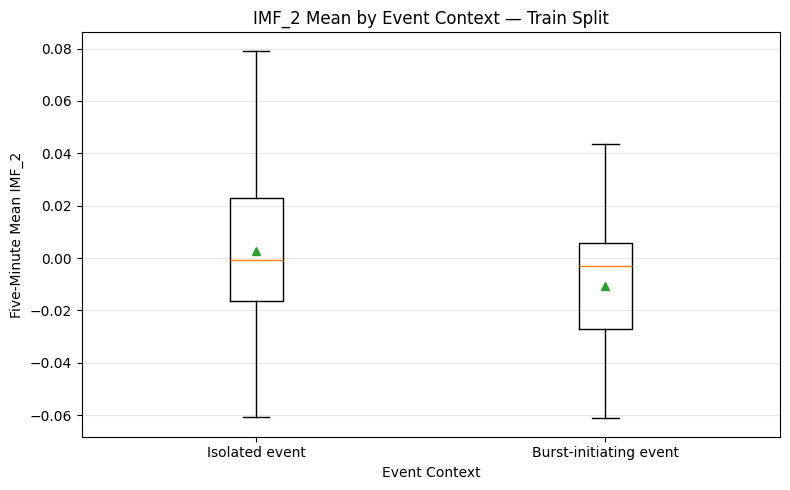

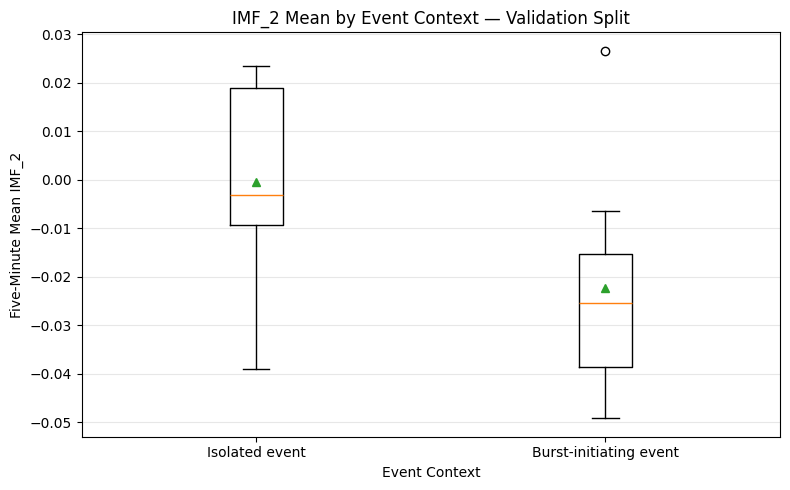

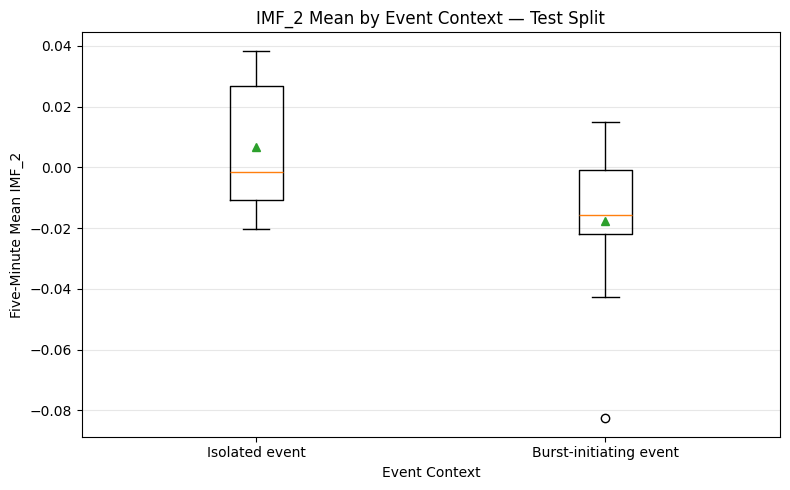

In [117]:
# Visualise IMF_2_mean separation by chronological split and event context

import matplotlib.pyplot as plt

split_order = ["train", "validation", "test"]

context_labels = {
    0: "Isolated event",
    1: "Burst-initiating event"
}

for data_split in split_order:

    split_data = (
        experiment2_modeling_dataset[
            experiment2_modeling_dataset["data_split"] == data_split
        ]
        .copy()
    )

    isolated_values = split_data.loc[
        split_data["target_burst_initiation"] == 0,
        "IMF_2_mean"
    ]

    burst_values = split_data.loc[
        split_data["target_burst_initiation"] == 1,
        "IMF_2_mean"
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [isolated_values, burst_values],
        tick_labels=[
            context_labels[0],
            context_labels[1]
        ],
        showmeans=True
    )

    plt.title(
        f"IMF_2 Mean by Event Context — {data_split.capitalize()} Split"
    )
    plt.ylabel("Five-Minute Mean IMF_2")
    plt.xlabel("Event Context")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### 7.7 Visual Interpretation of IMF_2_mean Separation

The `IMF_2_mean` distribution was visualised separately for the train, validation, and test partitions.

The purpose of this plot was to inspect the final model's only predictor directly, rather than relying only on aggregate performance metrics.

Across the chronological partitions, burst-initiating events generally tend to have lower five-minute mean `IMF_2` values than isolated events. This is consistent with the earlier diagnostics and with the final one-feature logistic regression model.

The separation is not perfect. The two classes still overlap, especially in the development data. This explains why the model is useful but not deterministic.

The test partition shows clearer practical separation than the combined development partition, which helps explain why the locked test performance was stronger than the development performance.

However, because the test partition contains only 23 events, this visual separation should be interpreted cautiously. It supports the final result, but it does not remove the small-sample uncertainty.

Overall, the visual evidence is consistent with the final Experiment 2 conclusion: `IMF_2_mean` contains a modest but useful recurrence-risk signal for distinguishing isolated imminent events from burst-initiating imminent events.

In [118]:
# Interpret the final locked one-feature logistic regression model

final_scaler = (
    experiment2_final_locked_model
    .named_steps["scaler"]
)

final_logistic_model = (
    experiment2_final_locked_model
    .named_steps["model"]
)

standardized_coefficient = (
    final_logistic_model.coef_[0][0]
)

model_intercept = (
    final_logistic_model.intercept_[0]
)

imf2_training_mean = (
    final_scaler.mean_[0]
)

imf2_training_scale = (
    final_scaler.scale_[0]
)

# Convert the standardized coefficient to the original IMF_2_mean scale
original_scale_coefficient = (
    standardized_coefficient
    / imf2_training_scale
)

print("Final locked model interpretation:")
print(
    f"Standardized IMF_2_mean coefficient: "
    f"{standardized_coefficient:.4f}"
)

print(
    f"Model intercept: "
    f"{model_intercept:.4f}"
)

print(
    f"Development-set IMF_2_mean used by scaler: "
    f"{imf2_training_mean:.6f}"
)

print(
    f"Development-set IMF_2_mean scale used by scaler: "
    f"{imf2_training_scale:.6f}"
)

print(
    f"Coefficient on original IMF_2_mean scale: "
    f"{original_scale_coefficient:.4f}"
)

if standardized_coefficient < 0:
    print(
        "\nInterpretation: Lower IMF_2_mean values increase "
        "the predicted probability of burst initiation."
    )
else:
    print(
        "\nInterpretation: Higher IMF_2_mean values increase "
        "the predicted probability of burst initiation."
    )

Final locked model interpretation:
Standardized IMF_2_mean coefficient: -0.5446
Model intercept: -0.0466
Development-set IMF_2_mean used by scaler: -0.003097
Development-set IMF_2_mean scale used by scaler: 0.029312
Coefficient on original IMF_2_mean scale: -18.5776

Interpretation: Lower IMF_2_mean values increase the predicted probability of burst initiation.


### 7.8 Interpretation of the Final Model Coefficient

The final locked model contains only one predictor: the five-minute pre-event mean of `IMF_2`.

The fitted standardized logistic-regression coefficient was:

- `IMF_2_mean` coefficient = -0.545.

The negative coefficient confirms that lower pre-event `IMF_2_mean` values are associated with a higher predicted probability of burst initiation.

Because the predictor was standardized before modelling, the coefficient can be interpreted relative to one standard deviation of `IMF_2_mean`.

A one-standard-deviation increase in `IMF_2_mean` multiplies the estimated odds of burst initiation by approximately:

\[
e^{-0.545} \approx 0.58
\]

Therefore, a one-standard-deviation increase in `IMF_2_mean` is associated with an estimated reduction of approximately 42% in the odds of burst initiation.

Equivalently, a one-standard-deviation decrease in `IMF_2_mean` is associated with approximately 1.72 times the estimated odds of burst initiation.

The coefficient on the original numerical scale was -18.578. This apparently large magnitude is primarily a consequence of the small numerical scale of `IMF_2_mean` and should not be interpreted without considering the feature's units and variability.

### Consistency with Earlier Diagnostics

The fitted model direction is consistent with the complete Experiment 2 evidence chain:

- burst-initiating events showed lower mean `IMF_2` values in the initial event-context comparison;
- the direction remained consistent across all measurable machine-period combinations;
- `IMF_2_mean` showed the strongest training-only univariate separation;
- the one-feature model outperformed the broader six-feature and two-feature alternatives on chronological validation;
- and the locked model demonstrated useful ranking performance on the future test partition.

The final model therefore learned the same directional relationship that was identified during the preceding structural and chronological diagnostics.


In [119]:
# Predicted burst-initiation probability at representative IMF_2_mean values

imf2_reference_values = (
    X_development_exp2["IMF_2_mean"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
)

imf2_probability_table = pd.DataFrame({
    "development_percentile": [
        "10th",
        "25th",
        "50th",
        "75th",
        "90th"
    ],
    "IMF_2_mean": imf2_reference_values.values
})

imf2_probability_table[
    "predicted_burst_probability"
] = (
    experiment2_final_locked_model
    .predict_proba(
        imf2_probability_table[["IMF_2_mean"]]
    )[:, 1]
)

imf2_probability_table[
    "predicted_burst_probability_pct"
] = (
    imf2_probability_table[
        "predicted_burst_probability"
    ] * 100
)

print(
    "Predicted burst-initiation probability "
    "at representative IMF_2_mean values:"
)

display(
    imf2_probability_table[
        [
            "development_percentile",
            "IMF_2_mean",
            "predicted_burst_probability_pct"
        ]
    ].round({
        "IMF_2_mean": 4,
        "predicted_burst_probability_pct": 2
    })
)

Predicted burst-initiation probability at representative IMF_2_mean values:


,development_percentile,IMF_2_mean,predicted_burst_probability_pct
0,10th,-0.0390,65.0300
1,25th,-0.0213,57.2400
2,50th,-0.0028,48.7000
3,75th,0.0187,38.9000
4,90th,0.0274,35.1300


### 7.9 Predicted Probability Relationship

To make the final one-feature model more interpretable, predicted burst-initiation probabilities were calculated at representative percentiles of the observed development-set `IMF_2_mean` distribution.

The estimated probabilities were:

- 10th percentile (`IMF_2_mean = -0.0390`): 65.0%;
- 25th percentile (`IMF_2_mean = -0.0213`): 57.2%;
- 50th percentile (`IMF_2_mean = -0.0028`): 48.7%;
- 75th percentile (`IMF_2_mean = 0.0187`): 38.9%;
- 90th percentile (`IMF_2_mean = 0.0274`): 35.1%.

The model therefore shows a clear monotonic relationship across the observed development-data range:

> Lower five-minute mean `IMF_2` values correspond to progressively higher predicted probabilities of burst initiation.

Across the 10th-to-90th percentile range of the observed predictor distribution, the estimated probability decreases from approximately 65% to 35%.

This makes the model's behaviour operationally interpretable. Events preceded by relatively low `IMF_2_mean` values are assigned greater near-term recurrence risk, whereas events preceded by relatively high values are assigned lower recurrence risk.

These values should be interpreted as model-estimated probabilities rather than precisely calibrated real-world risks. The dataset contains only 114 eligible events, so probability calibration cannot be established with high confidence.

The primary value of this analysis is therefore the clear and consistent risk ordering rather than the exact numerical probability assigned to an individual event.

In [120]:
# Stratified bootstrap uncertainty analysis for locked test metrics
# The locked model is not refitted and no model decision is changed

rng = np.random.default_rng(42)

test_probabilities_exp2 = (
    experiment2_final_locked_model
    .predict_proba(X_test_exp2)[:, 1]
)

test_predictions_exp2 = (
    test_probabilities_exp2 >= 0.5
).astype(int)

y_test_array_exp2 = y_test_exp2.to_numpy()

negative_indices = np.where(
    y_test_array_exp2 == 0
)[0]

positive_indices = np.where(
    y_test_array_exp2 == 1
)[0]

n_bootstrap = 5000

bootstrap_metrics_exp2 = []

for _ in range(n_bootstrap):

    sampled_negative_indices = rng.choice(
        negative_indices,
        size=len(negative_indices),
        replace=True
    )

    sampled_positive_indices = rng.choice(
        positive_indices,
        size=len(positive_indices),
        replace=True
    )

    bootstrap_indices = np.concatenate([
        sampled_negative_indices,
        sampled_positive_indices
    ])

    y_bootstrap = (
        y_test_array_exp2[bootstrap_indices]
    )

    probability_bootstrap = (
        test_probabilities_exp2[bootstrap_indices]
    )

    prediction_bootstrap = (
        test_predictions_exp2[bootstrap_indices]
    )

    bootstrap_metrics_exp2.append({
        "PR_AUC": average_precision_score(
            y_bootstrap,
            probability_bootstrap
        ),
        "ROC_AUC": roc_auc_score(
            y_bootstrap,
            probability_bootstrap
        ),
        "precision": precision_score(
            y_bootstrap,
            prediction_bootstrap,
            zero_division=0
        ),
        "recall": recall_score(
            y_bootstrap,
            prediction_bootstrap,
            zero_division=0
        ),
        "F1": f1_score(
            y_bootstrap,
            prediction_bootstrap,
            zero_division=0
        )
    })

bootstrap_metrics_exp2 = pd.DataFrame(
    bootstrap_metrics_exp2
)

bootstrap_summary_exp2 = []

for metric in [
    "PR_AUC",
    "ROC_AUC",
    "precision",
    "recall",
    "F1"
]:

    bootstrap_summary_exp2.append({
        "metric": metric,
        "locked_test_estimate": (
            test_metrics_exp2_final[metric]
        ),
        "bootstrap_mean": (
            bootstrap_metrics_exp2[metric].mean()
        ),
        "CI_2.5_pct": (
            bootstrap_metrics_exp2[metric]
            .quantile(0.025)
        ),
        "CI_97.5_pct": (
            bootstrap_metrics_exp2[metric]
            .quantile(0.975)
        )
    })

bootstrap_summary_exp2 = pd.DataFrame(
    bootstrap_summary_exp2
)

print(
    "Stratified bootstrap uncertainty summary "
    f"({n_bootstrap} resamples):"
)

display(
    bootstrap_summary_exp2.round(4)
)

Stratified bootstrap uncertainty summary (5000 resamples):


,metric,locked_test_estimate,bootstrap_mean,CI_2.5_pct,CI_97.5_pct
0,PR_AUC,0.8292,0.8384,0.6876,0.9563
1,ROC_AUC,0.7615,0.7633,0.5462,0.9308
2,precision,0.7500,0.7587,0.5714,1.0000
3,recall,0.6923,0.6932,0.4615,0.9231
4,F1,0.7200,0.7181,0.5000,0.8889


### 7.10 Small-Sample Uncertainty of the Locked Test Results

The locked chronological test partition contains only 23 events:

- 10 isolated events;
- 13 burst-initiating events.

Therefore, the final point estimates were supplemented with a stratified bootstrap uncertainty analysis using 5,000 resamples.

Within each bootstrap iteration, isolated and burst-initiating test events were resampled separately with replacement. This preserved the observed test class composition while quantifying the sensitivity of the reported metrics to the small number of test events.

The resulting approximate 95% bootstrap intervals were:

- PR-AUC: 0.688 to 0.956;
- ROC-AUC: 0.546 to 0.931;
- precision: 0.571 to 1.000;
- recall: 0.462 to 0.923;
- F1-score: 0.500 to 0.889.

The intervals are wide, confirming that the exact performance estimates are uncertain because of the small holdout sample.

Nevertheless, the ranking results remain encouraging. The locked PR-AUC estimate was 0.829, and the lower bootstrap bound was approximately 0.688. This remained above the observed test positive-class prevalence of 56.5%, which serves as the approximate no-skill PR-AUC reference for this fixed test composition.

The ROC-AUC estimate was 0.762, with a wider interval from approximately 0.546 to 0.931.

### Interpretation of the Bootstrap Analysis

The bootstrap analysis does not change the locked test result or the selected model.

Instead, it qualifies the strength of the conclusion:

> The final model demonstrated promising recurrence-risk discrimination on the available future holdout, but the exact magnitude of performance remains uncertain.

These intervals should not be interpreted as complete estimates of future production uncertainty. The stratified bootstrap resamples the same 23 observed test events and preserves their class composition. It does not capture uncertainty arising from:

- different future event prevalence;
- longer operating periods;
- different machine populations;
- process drift;
- sensor drift;
- or changes in the event-generation mechanism.

Therefore, the final model should be treated as a promising proof of concept requiring evaluation on substantially more future event data before any production claim is made.

### 7.11 Experiment 2 Final Summary

### Objective

Experiment 2 investigated whether the five minutes immediately preceding an eligible positive event could distinguish:

- an isolated transient event; from
- an event that initiates a short-term recurrent burst.

The task was formulated as **imminent-event recurrence-risk classification** rather than conventional long-horizon failure prediction.

### Why the Experiment Was Developed

Experiment 1 showed that predicting the occurrence of the next brief positive event did not generalize reliably to future chronological data.

Subsequent target-process diagnostics showed that:

- positive episodes were predominantly brief;
- events frequently recurred within short intervals;
- a substantial proportion of events occurred in multi-event bursts.

This motivated a more coherent prediction question focused on the recurrence context of an already imminent event.

### Data and Prediction Protocol

The experiment used 114 eligible events:

- 70 isolated events;
- 44 burst-initiating events.

Only the five observations immediately preceding each event were used as predictors.

The frozen chronological split was preserved:

- Train: 72 events;
- Validation: 19 events;
- Test: 23 events.

The test partition remained untouched until the complete model specification had been selected.

### Signal and Feature Findings

`IMF_3` was excluded because it was exactly duplicated across all three machines at matching timestamps and behaved as a shared time-varying signal rather than an independent machine-specific signal.

Among the remaining machine-specific signals, lower pre-event `IMF_2` values showed the most consistent association with burst initiation.

`IMF_2_mean`:

- showed the strongest training-only univariate separation;
- maintained the same directional relationship across all measurable machine-period combinations;
- and produced better chronological validation performance than broader multivariate alternatives.

### Model Selection

Three restrained logistic-regression formulations were compared during the validation stage:

1. six selected features;
2. `IMF_2_mean` only;
3. `IMF_2_mean` plus `vibration_change`.

The one-feature `IMF_2_mean` model achieved the strongest validation performance and was therefore selected.

The final model specification was locked as:

- predictor: `IMF_2_mean`;
- preprocessing: standardization;
- model: class-balanced logistic regression;
- classification threshold: 0.5.

No further feature search, model-family search, threshold tuning, or hyperparameter optimisation was performed before the test evaluation.

### Locked Future Test Performance

After model selection, the locked specification was refitted on the combined train and validation partitions and evaluated once on the untouched chronological test set.

Final test performance was:

- PR-AUC: 0.829;
- ROC-AUC: 0.762;
- precision: 0.750;
- recall: 0.692;
- F1-score: 0.720.

At the fixed threshold:

- 9 of 13 burst-initiating events were detected;
- 4 were missed;
- 7 of 10 isolated events were correctly classified;
- 3 isolated events were incorrectly flagged.

### Model Interpretation

The final standardized coefficient for `IMF_2_mean` was negative:

- coefficient = -0.545.

Therefore:

> Lower five-minute mean `IMF_2` values increase the model's estimated probability of burst initiation.

Across representative development-data percentiles, the estimated burst-initiation probability decreased from approximately:

- 65% at a low `IMF_2_mean` value;
- to 35% at a high `IMF_2_mean` value.

This probability relationship should be interpreted primarily as a risk-ordering pattern rather than as precisely calibrated production probabilities.

### Uncertainty and Limitations

The locked test set contained only 23 events.

A 5,000-resample stratified bootstrap produced wide uncertainty intervals, including:

- PR-AUC: approximately 0.688 to 0.956;
- ROC-AUC: approximately 0.546 to 0.931;
- F1-score: approximately 0.500 to 0.889.

Therefore, the final result is promising but statistically uncertain.

The model has not been validated across:

- longer future operating periods;
- additional machines;
- different event prevalences;
- sensor drift;
- or process drift.

### Final Experiment 2 Conclusion

Experiment 2 produced a more coherent and temporally generalizable formulation than the original event-occurrence prediction task.

The strongest result came from a simple one-feature logistic regression rather than from increased model complexity.

The experiment demonstrates an important predictive-maintenance lesson:

> When the original target is structurally difficult to predict, deeper analysis of the event-generation process can reveal a more meaningful and learnable prediction objective.

The final model should be treated as a promising proof of concept for **imminent-event recurrence-risk classification**, requiring validation on substantially more future data before any production claim is made.

## 8. Overall Project Synthesis and Conclusion

### 8.1 Comparative Synthesis of Experiment 1 and Experiment 2

This project evolved through two distinct predictive-maintenance experiments.

The most important outcome was not simply the improvement in model performance. The central finding was that the **definition of the prediction problem** had a greater effect on future generalization than increasing model complexity.

### Experiment 1: Static Pre-Event Classification

Experiment 1 attempted to distinguish:

- control windows; from
- pre-event windows.

The formulation asked whether static engineered features from sensor windows could identify a general pre-event state.

A rigorous chronological modelling protocol was used:

- training: 158 windows;
- validation: 33 windows;
- test: 36 windows.

The final model was a regularized XGBoost classifier using 30 training-derived predictors.

Its validation performance was:

- PR-AUC: 0.738;
- ROC-AUC: 0.613;
- recall: 0.632;
- F1-score: 0.667.

However, the frozen model failed on the untouched future test partition:

- PR-AUC: 0.642;
- ROC-AUC: 0.442;
- recall: 0.435;
- F1-score: 0.500.

The below-random test ROC-AUC showed that the problem was not merely an unsuitable classification threshold. The model's probability ranking itself failed to generalize.

Machine-level analysis showed that the deterioration was broad rather than being caused by only one machine.

Experiment 1 therefore demonstrated that the available static sensor-window features contained predictive information in some machine-period combinations, but the relationship was not sufficiently stable across chronological periods.

The final Experiment 1 model was therefore rejected as a deployment candidate.

### From Model Failure to Problem Reformulation

The failure of Experiment 1 was not treated as a request for more aggressive hyperparameter tuning.

Instead, the event-generation process itself was investigated.

The analysis showed that:

- positive episodes were predominantly one observation long;
- events frequently recurred after short intervals;
- many events formed multi-event bursts;
- and the original task attempted to predict brief, irregular event occurrence from static pre-event windows.

This suggested that the original target was structurally difficult and potentially misaligned with the strongest information available in the sensor data.

The project was therefore reformulated.

### Experiment 2: Imminent-Event Recurrence-Risk Classification

Experiment 2 asked a different question:

> Given that an eligible event is already imminent, can the preceding five minutes of sensor behaviour indicate whether the event will remain isolated or initiate a short-term recurrent burst?

The modelling population contained:

- 114 eligible events;
- 70 isolated events;
- 44 burst-initiating events.

The frozen chronological partitions were:

- training: 72 events;
- validation: 19 events;
- test: 23 events.

The strongest stable signal was the five-minute pre-event mean of `IMF_2`.

A simple one-feature class-balanced logistic regression outperformed broader multivariate alternatives during chronological validation.

The final locked model achieved on the untouched future test partition:

- PR-AUC: 0.829;
- ROC-AUC: 0.762;
- precision: 0.750;
- recall: 0.692;
- F1-score: 0.720.

The model identified 9 of 13 burst-initiating events while incorrectly flagging 3 of 10 isolated events.

### Comparative Result

| Aspect | Experiment 1 | Experiment 2 |
|---|---|---|
| Prediction objective | General pre-event classification | Imminent-event recurrence risk |
| Modelling unit | Engineered sensor window | Eligible event |
| Final model | XGBoost | Logistic regression |
| Final predictor count | 30 | 1 |
| Test PR-AUC | 0.642 | 0.829 |
| Test ROC-AUC | 0.442 | 0.762 |
| Test Recall | 0.435 | 0.692 |
| Test F1-score | 0.500 | 0.720 |
| Chronological generalization | Unsuccessful | Promising, with small-sample uncertainty |

The comparison should not be interpreted as a direct model competition because the two experiments predict different targets and use different modelling populations.

However, the project provides a clear methodological result:

> Reformulating the prediction objective around a more coherent event process produced a simpler and more temporally generalizable solution than increasing model complexity within the original formulation.

Experiment 1 required a 30-feature XGBoost model and still failed future generalization.

Experiment 2 used a single predictor with logistic regression and produced substantially stronger future-period discrimination.

The central project lesson is therefore:

> In predictive maintenance, understanding the structure of the failure or event process can be more important than selecting a more sophisticated algorithm.

### 8.2 Overall Project Conclusion

This project began with a conventional predictive-maintenance objective: determine whether engineered sensor behaviour could distinguish normal operating windows from windows immediately preceding positive events.

Experiment 1 showed that this formulation contained some predictive signal during development, but the relationship did not remain stable in the later chronological test period. The frozen XGBoost model therefore failed to demonstrate reliable future generalization and was rejected as a deployment candidate.

Rather than attempting to rescue the failed model through additional tuning, the project investigated the underlying event-generation process. This analysis showed that positive events were predominantly brief, frequently recurrent, and often organized into short-term bursts. It also identified structural limitations in some candidate signals and showed that the original event-occurrence formulation was not well aligned with the temporal structure of the observed process.

The prediction problem was therefore reformulated. Experiment 2 focused on a narrower and more coherent question:

> **When an eligible event is already imminent, is it more likely to remain isolated or initiate a short-term recurrent burst?**

Under this formulation, a simple one-feature logistic regression model using five-minute pre-event `IMF_2_mean` demonstrated promising discrimination on the untouched future test period. The result was substantially stronger than the original formulation, although uncertainty remains because the final test set contained only 23 events.

The complete project therefore did not establish a validated long-horizon failure-prediction system. Instead, it established three important findings:

1. the original static pre-event classification problem was chronologically unstable;
2. investigation of the event process revealed meaningful recurrence and burst structure;
3. reformulating the target around imminent-event recurrence risk produced a simpler, more interpretable, and more temporally generalizable proof of concept.

The central methodological progression of the project was:

> **model failure → event-process investigation → target reformulation → restrained modelling → chronological validation → uncertainty-aware interpretation**

This progression is the primary analytical contribution of the project.

### 8.3 Business Interpretation

The final model should be interpreted as a recurrence-risk decision-support model, not as a complete machine-failure prediction system.

Its operational question is:

> **When an eligible positive event is already imminent, how likely is that event to initiate a short-term recurrent burst rather than remain isolated?**

This distinction is important. The model does not independently detect that an event is approaching. It requires an upstream mechanism capable of identifying or triggering on an imminent eligible event. Once such a trigger exists, the model can use the preceding five-minute `IMF_2_mean` behaviour to estimate recurrence risk.

A potential operational workflow is:

> **sensor stream → upstream imminent-event trigger → five-minute pre-event feature calculation → recurrence-risk score → maintenance or monitoring response**

Under this workflow, a higher predicted recurrence risk could support actions such as:

- increasing short-term monitoring intensity;
- prioritizing inspection of the affected machine;
- preparing maintenance personnel or resources;
- reviewing recent operating conditions;
- checking whether related events are emerging across the same process;
- and differentiating potentially isolated events from events that may initiate repeated short-term instability.

The model is therefore most relevant to maintenance prioritization and escalation, rather than automatic shutdown or autonomous maintenance decisions.

The practical value of the model depends on the business cost of the two main error types:

- a **false positive** may cause unnecessary inspection, monitoring, or maintenance preparation;
- a **false negative** may fail to escalate an event that later develops into repeated short-term instability.

The appropriate operating threshold should therefore be selected using maintenance economics, operational capacity, safety requirements, and the relative cost of missed recurrent events versus unnecessary interventions. The current project did not optimize this business decision threshold.

The model should also not be interpreted as evidence that `IMF_2_mean` is a universal physical cause of recurrent machine instability. Within this dataset, it is an informative predictive signal. Establishing a causal or broadly transferable relationship would require additional machines, longer observation periods, repeated future validation, and engineering-domain investigation.

The current business conclusion is therefore:

> **The project provides a promising proof of concept for using short pre-event sensor behaviour to prioritize imminent events by their risk of initiating recurrent short-term instability. It does not yet provide a complete or deployment-ready predictive-maintenance system.**

### 8.4 Methodological Lessons

This project produced several broader lessons about applied machine learning for temporal industrial data.

#### 1. Future generalization matters more than development performance

A model can appear useful on training and validation data while failing on a later chronological period. Experiment 1 demonstrated that acceptable validation performance does not establish that the underlying predictive relationship is stable over time.

For temporal problems, the critical question is not only:

> **Can the model classify observations it has not seen?**

but also:

> **Does the learned relationship remain valid in a genuinely later period?**

Chronological evaluation was therefore essential to understanding the real limitation of the original formulation.

#### 2. A failed model can reveal a problem with the target, not only the algorithm

When Experiment 1 failed on the untouched future test period, the project did not assume that the solution was a more complex model, additional hyperparameter tuning, or post-test feature engineering.

Instead, the event-generation process was investigated.

This revealed that the observed positive events were predominantly brief, frequently recurrent, and often organized into short-term bursts. The failure of the original model therefore became evidence that the original prediction target required closer examination.

> **When repeated model improvement does not produce stable future generalization, the problem formulation itself should be investigated.**

#### 3. Understanding the data-generating process can be more valuable than adding model complexity

The most important progress in the project came from examining:

- positive-episode duration;
- inter-episode recurrence;
- short-term burst structure;
- event eligibility;
- chronological stability;
- and structural properties of candidate signals.

These investigations changed the prediction problem itself. The strongest final model was not the most complex model attempted in the project; it was a one-feature logistic regression model built after the event process was better understood.

#### 4. Simpler models can be preferable when the dataset is small

Experiment 2 had a limited number of eligible events. Under such conditions, a restrained model reduces the risk of fitting unstable relationships that appear strong during development but fail in future periods.

The final one-feature model offered:

- lower model complexity;
- direct interpretation;
- reduced dependence on unstable feature interactions;
- and a clearer connection between the predictor and the predicted probability.

The result does not prove that simple models are always superior. It demonstrates that model complexity should be proportional to the amount and stability of available evidence.

#### 5. Leakage prevention requires attention to the full analytical pipeline

Temporal leakage can enter through more than the final train-test split. It can also arise through:

- feature-window construction;
- event-onset contamination;
- preprocessing fitted on future data;
- feature selection using validation or test information;
- repeated inspection of test performance;
- and post-test tuning.

The project therefore treated leakage prevention as an end-to-end methodological requirement rather than a single data-splitting decision.

#### 6. A test set should remain a final evaluation mechanism

Experiment 1 produced a poor test result. That result was preserved rather than used as feedback for additional tuning.

Experiment 2 was subsequently created from investigation of the event process and a new prediction target, not from attempts to optimize the original model against its failed test set.

This distinction is important:

> **A disappointing test result should not become another hyperparameter-tuning signal.**

#### 7. Predictive performance should be interpreted together with uncertainty

Experiment 2 produced promising locked test performance, but the test population contained only 23 events. The bootstrap analysis therefore showed wide uncertainty around the point estimates.

Reporting only the headline PR-AUC, ROC-AUC, or F1-score would overstate the strength of the evidence.

The appropriate conclusion is that the final model demonstrated promising future discrimination within the observed test period, while requiring substantially more data and repeated future validation before stronger claims can be made.

#### 8. Honest negative results can strengthen an applied data-science project

Experiment 1 was not removed because it failed. Its failure established that the original formulation did not generalize reliably and motivated a deeper investigation of the target process.

Preserving that analytical history makes the final result more credible because it shows:

> **what was attempted → how it was evaluated → why it was rejected → what was learned → how the problem was reformulated**

The principal methodological lesson of the complete project is:

> **Strong applied data science is not only the search for a better model. It is the disciplined process of testing whether the prediction problem, data, validation design, and resulting evidence support the claim being made.**

### 8.5 Limitations and Production Requirements

The final Experiment 2 model demonstrated promising future discrimination, but the current evidence is not sufficient to support production deployment. The following limitations define the boundary of the project’s conclusions.

#### 1. Limited event sample size

Experiment 2 was developed and evaluated on a small event-level dataset. The untouched test partition contained only 23 eligible events.

With such a small test population:

* individual predictions have a substantial effect on reported metrics;
* performance estimates are statistically uncertain;
* machine-specific evaluation is limited;
* and rare operating conditions may not be represented.

The bootstrap analysis makes this uncertainty explicit. The reported point estimates should therefore be treated as evidence of promising discrimination, not as precise estimates of future production performance.

#### 2. Limited machine population

The dataset contains only three machines:

* M01;
* M02;
* M03.

This is sufficient for an initial multi-machine investigation, but not for establishing broad transferability across different equipment types, sites, operating regimes, or maintenance environments.

Future validation should include:

* more machines;
* different operating conditions;
* longer machine histories;
* and, where possible, data from independent sites or processes.

#### 3. Limited chronological coverage

A single future holdout period provides an important test of temporal generalization, but it does not establish long-term stability.

Sensor relationships may change because of:

* equipment ageing;
* maintenance interventions;
* sensor replacement or recalibration;
* process changes;
* environmental conditions;
* operating-policy changes;
* and changes in event frequency.

The model should therefore be evaluated across multiple future holdout periods before deployment.

#### 4. The upstream imminent-event detection mechanism is not validated

The final model answers a conditional question:

> **Given that an eligible positive event is already imminent, will it remain isolated or initiate a short-term recurrent burst?**

The current project does not provide a validated mechanism for independently detecting that an eligible event is approaching.

A complete operational system would therefore require:

> **continuous sensor monitoring → validated imminent-event detection → pre-event feature calculation → recurrence-risk prediction → operational response**

The upstream detection mechanism must be developed and validated separately. Without it, the current model cannot operate as a standalone predictive-maintenance system.

#### 5. The final predictor is not established as a causal mechanism

The final model uses five-minute pre-event `IMF_2_mean` as its only predictor.

Within this dataset, the feature showed useful predictive association with burst initiation. This does not establish that `IMF_2_mean` physically causes recurrent instability or that the relationship will remain unchanged across other machines and environments.

Engineering-domain investigation is required to determine:

* the physical interpretation of the signal;
* whether it reflects a known failure or instability mechanism;
* whether it is affected by operating conditions;
* and whether the relationship is reproducible outside the current dataset.

#### 6. Probability calibration has not been established

The final model produces predicted probabilities, but discrimination and calibration are different properties.

A model can rank higher-risk events effectively while still producing probabilities that do not correspond accurately to observed frequencies.

Before operational use, future work should assess:

* calibration curves;
* Brier score;
* calibration stability across machines and time periods;
* and whether recalibration is required.

#### 7. The operating threshold has not been optimized for business cost

The current project evaluates predictive performance, but it does not determine the economically optimal decision threshold.

A production threshold should consider:

* the cost of unnecessary inspections;
* the cost of missed recurrent events;
* maintenance-team capacity;
* downtime consequences;
* safety implications;
* and the value of earlier escalation.

Threshold selection should therefore be based on operational utility and maintenance economics rather than model metrics alone.

#### 8. Sensor and process drift must be monitored

Production performance may degrade if the sensor distribution or event-generation process changes.

A deployed system would require monitoring of:

* predictor distribution drift;
* missing-data patterns;
* sensor quality and calibration;
* event prevalence;
* predicted-risk distribution;
* model discrimination;
* and probability calibration.

Material drift should trigger investigation and, where justified, controlled model redevelopment.

#### 9. Repeated future validation is required before deployment

Before production consideration, the complete system should be tested on substantially more future data.

The minimum evidence base should include:

* more positive events;
* more burst-initiating events;
* additional machines;
* repeated chronological holdout periods;
* independent validation where possible;
* upstream event-detection validation;
* probability-calibration assessment;
* drift-monitoring design;
* and economic evaluation of false positives and false negatives.

The final status of the project is therefore:

> **Experiment 2 provides a promising and interpretable proof of concept for imminent-event recurrence-risk prediction. The result is analytically valuable, but additional data, repeated future validation, upstream event detection, calibration assessment, drift monitoring, and business-cost evaluation are required before production deployment.**
